## Problem Statement

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

## Importing necessary libraries

In [2]:
# Installing the libraries with the specified version
!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 imbalanced-learn==0.10.1 xgboost==2.0.3 threadpoolctl==3.3.0 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.1 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve, auc
)
from sklearn import metrics

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
# Load dataset from colab drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read the csv
train = pd.read_csv('/content/drive/MyDrive/Train.csv')
test = pd.read_csv('/content/drive/MyDrive/Test.csv')

In [ ]:
# Make copy of the dataframes
df_train = train.copy()
df_test = test.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# General Information about the datasets
train_info = df_train.info()
test_info = df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [ ]:
# Checking dataframe shape
df_train.shape, df_test.shape


((20000, 41), (5000, 41))

In [ ]:
# Checking for missing values TRAIN
train_missing = df_train.isnull().sum()

# Display results
train_missing[train_missing > 0]

,0
V1,18
V2,18


In [ ]:
# Checking for missing values TEST
test_missing = df_test.isnull().sum()

# Display results
test_missing[test_missing > 0]

,0
V1,5
V2,6


In [ ]:
# Checking for duplicate values TRAIN
train_duplicates = df_train.duplicated().sum()

# Display results
train_duplicates

0

In [ ]:
# Checking for duplicate values TEST
test_duplicates = df_test.duplicated().sum()

# Display results
test_duplicates

0

Data Overview Observations/Insights:

* Train: dataset contains 20,000 rows and 41 columns. Test: dataset contains 5,000 rows and 41 columns.

* All features appear to be of float64 type, which is good for numerical modeling

* There appears to be some missing values in train & test dataset

* There are no duplicate values in both train & test dataset

In [ ]:
# Train statistical summary
train_summary = df_train.describe()

# Display results
train_summary

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,-1.895393,1.604825,1.580486,-0.950632,-2.414993,-2.925225,-0.134261,1.189347,1.181808,0.023608,-3.611252,0.951835,-0.366116,1.134389,-0.002186,1.873785,-0.612413,-0.883218,-0.985625,-0.015534,0.486842,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,3.124322,2.930454,2.874658,1.789651,3.354974,4.221717,3.345462,2.592276,3.396925,3.669477,3.567690,1.651547,4.031860,3.912069,2.016740,3.435137,4.368847,1.917713,2.684365,3.005258,3.461384,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,-14.832058,-12.948007,-13.228247,-7.738593,-16.416606,-20.374158,-14.091184,-11.643994,-13.491784,-13.922659,-17.956231,-10.122095,-14.866128,-16.387147,-8.228266,-11.834271,-14.904939,-9.269489,-12.579469,-14.796047,-13.722760,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,-3.922404,-0.396514,-0.223545,-2.170741,-4.415322,-5.634240,-2.215611,-0.403917,-1.050168,-2.432953,-5.930360,-0.118127,-3.098756,-1.468062,-1.365178,-0.337863,-3.652323,-2.171218,-2.787443,-1.867114,-1.817772,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,-1.921237,1.507841,1.637185,-0.957163,-2.382617,-2.682705,-0.014580,0.883398,1.279061,0.033415,-3.532888,0.974687,-0.262093,0.969048,0.025050,1.950531,-0.884894,-0.891073,-1.176181,0.184346,0.490304,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,0.118906,3.571454,3.459886,0.270677,-0.359052,-0.095046,2.068751,2.571770,3.493299,2.512372,-1.265884,2.025594,2.451750,3.545975,1.397112,4.130037,2.189177,0.375884,0.629773,2.036229,2.730688,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,11.826433,15.080698,15.419616,5.670664,12.246455,13.583212,16.756432,13.179863,13.237742,16.052339,13.840473,7.409856,14.458734,17.163291,8.223389,16.836410,17.560404,6.527643,10.722055,12.505812,17.255090,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


In [ ]:
# Test statistical summary
test_summary = df_test.describe()

# Display results
test_summary

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.000000,4994.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.277622,0.397928,2.551787,-0.048943,-0.080120,-1.042138,-0.907922,-0.574592,0.030121,0.018524,-2.008615,1.576413,1.622456,-0.921097,-2.452174,-3.018503,-0.103721,1.195606,1.210490,0.138429,-3.664398,0.961960,-0.422182,1.088841,0.061235,1.847261,-0.552397,-0.867678,-1.095805,-0.118699,0.468810,0.232567,-0.080115,-0.392663,2.211205,1.594845,0.022931,-0.405659,0.938800,-0.932406,0.056400
std,3.466280,3.139562,3.326607,3.413937,2.110870,2.005444,1.769017,3.331911,2.174139,2.145437,3.112220,2.907401,2.882892,1.803470,3.387041,4.264407,3.336513,2.586403,3.384662,3.657171,3.577841,1.640414,4.056714,3.968207,2.010227,3.400330,4.402947,1.926181,2.655454,3.023292,3.446324,5.585628,3.538624,3.166101,2.948426,3.774970,1.785320,3.968936,1.716502,2.978193,0.230716
min,-12.381696,-10.716179,-9.237940,-14.682446,-7.711569,-8.924196,-8.124230,-12.252731,-6.785495,-8.170956,-13.151753,-8.164048,-11.548209,-7.813929,-15.285768,-20.985779,-13.418281,-12.214016,-14.169635,-13.719620,-16.340707,-6.740239,-14.422274,-12.315545,-6.770139,-11.414019,-13.177038,-7.933388,-9.987800,-12.438434,-11.263271,-17.244168,-14.903781,-14.699725,-12.260591,-12.735567,-5.079070,-15.334533,-5.451050,-10.076234,0.000000
25%,-2.743691,-1.649211,0.314931,-2.292694,-1.615238,-2.368853,-2.054259,-2.642088,-1.455712,-1.353320,-4.050432,-0.449674,-0.126012,-2.110952,-4.479072,-5.648343,-2.227683,-0.408850,-1.026394,-2.325454,-5.944369,-0.047728,-3.162690,-1.623203,-1.298377,-0.242470,-3.662591,-2.159811,-2.861373,-1.996743,-1.822421,-3.556267,-2.348121,-2.009604,0.321818,-0.866066,-1.240526,-2.984480,-0.208024,-2.986587,0.000000
50%,-0.764767,0.427369,2.260428,-0.145753,-0.131890,-1.048571,-0.939695,-0.357943,-0.079891,0.166292,-2.043122,1.488253,1.718649,-0.896011,-2.417131,-2.773763,0.047462,0.881395,1.295864,0.193386,-3.662870,0.986020,-0.279222,0.912815,0.076703,1.917032,-0.871982,-0.930695,-1.340547,0.112463,0.485742,-0.076694,-0.159713,-0.171745,2.111750,1.702964,-0.110415,-0.381162,0.959152,-1.002764,0.000000
75%,1.831313,2.444486,4.587000,2.166468,1.341197,0.307555,0.212228,1.712896,1.449548,1.511248,0.044069,3.562626,3.464604,0.272324,-0.432943,-0.178105,2.111907,2.604014,3.526278,2.539550,-1.329645,2.029321,2.425911,3.537195,1.428491,4.156106,2.247257,0.420587,0.521843,1.946450,2.779008,3.751857,2.099160,1.465402,4.031639,4.104409,1.237522,2.287998,2.130769,1.079738,0.000000
max,13.504352,14.079073,15.314503,12.140157,7.672835,5.067685,7.616182,10.414722,8.850720,6.598728,9.956400,12.983644,12.620041,5.734112,11.673420,13.975843,19.776592,13.642235,12.427997,13.870565,11.046925,7.505291,13.180887,17.806035,6.556937,17.528193,17.290161,7.415659,14.039466,10.314976,12.558928,26.539391,13.323517,12.146302,13.489237,17.116122,6.809938,13.064950,7.182237,8.698460,1.000000


In [ ]:
# Checking the distribution of the target variable
train_target_distribution = df_train["Target"].value_counts(normalize=True) * 100
test_target_distribution = df_test["Target"].value_counts(normalize=True) * 100

# Display results
print("Train Target Distribution:")
print(train_target_distribution)
print("\nTest Target Distribution:")
print(test_target_distribution)

Train Target Distribution:
0    94.45
1     5.55
Name: Target, dtype: float64

Test Target Distribution:
0    94.36
1     5.64
Name: Target, dtype: float64


Statistical Summary Train & Test Observations/Insights:

Data Distribution & Scaling:

* Both datasets have similar mean and standard deviation ranges across numerical features.
* Some features have a mean close to zero ( V7, V9, V10), suggesting standardized or normalized scaling.
* High standard deviation in features like V32, V36, V38 indicates high variance, which could impact model stability.

Presence of Outliers:

* Many features have minimum and maximum values far apart, indicating potential outliers.
* Outliers can affect model performance and may require clipping or transformations.

Missing Values:

* The dataset has some missing values in V1 and V2:
  * Train Data: V1 (4995 entries), V2 (4994 entries): Missing 5-6 values.
  * Test Data: Missing values in the same columns.
* *Action Needed: Imputation (Median/Mean).*

Target Variable Distribution:

* The mean of Target is 0.0564, meaning only 5.64% of the data belongs to the failure class. This confirms high class imbalance, requiring oversampling (SMOTE) or class weighting.

Negative values:

* *Observed, project scope suggests negative values are values obtained from sensors placed on the generators and are not anomalous data. So, will not be treat (impute or drop), will be used as it is.*

## Exploratory Data Analysis (EDA)



### **Note**: Only the key observations from EDA focus on the model building aspects. The detailed EDA can be found in the <a href = #link1>appendix section</a>.

### Plotting histograms and boxplots for all the variables

In [ ]:
# Function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Plotting all the features at one go

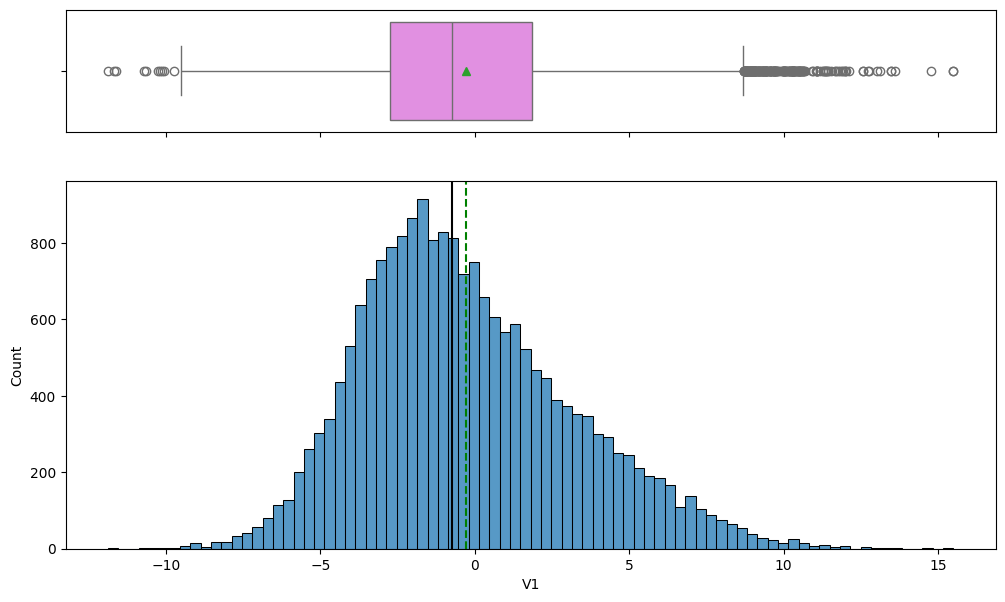

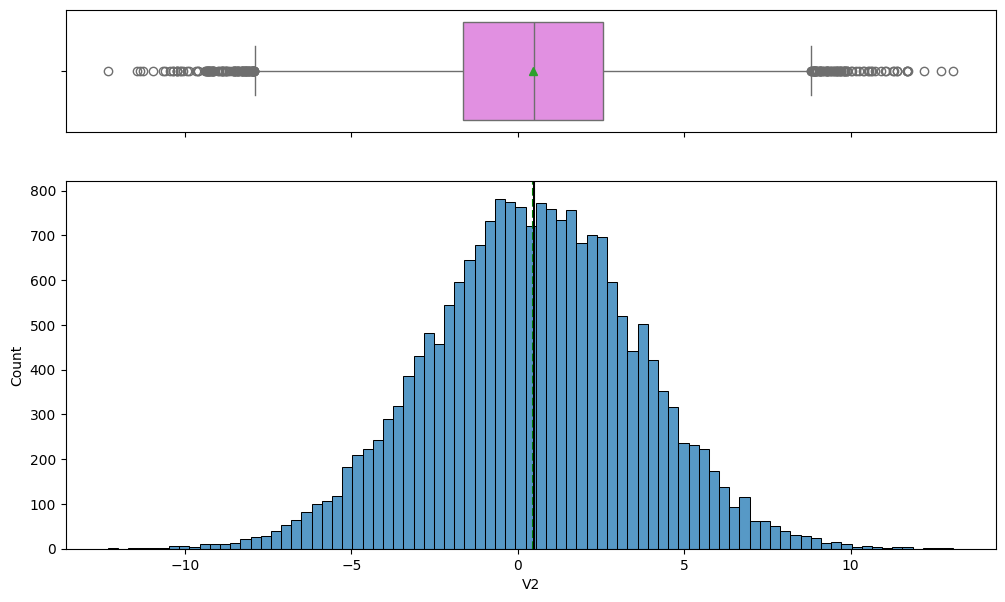

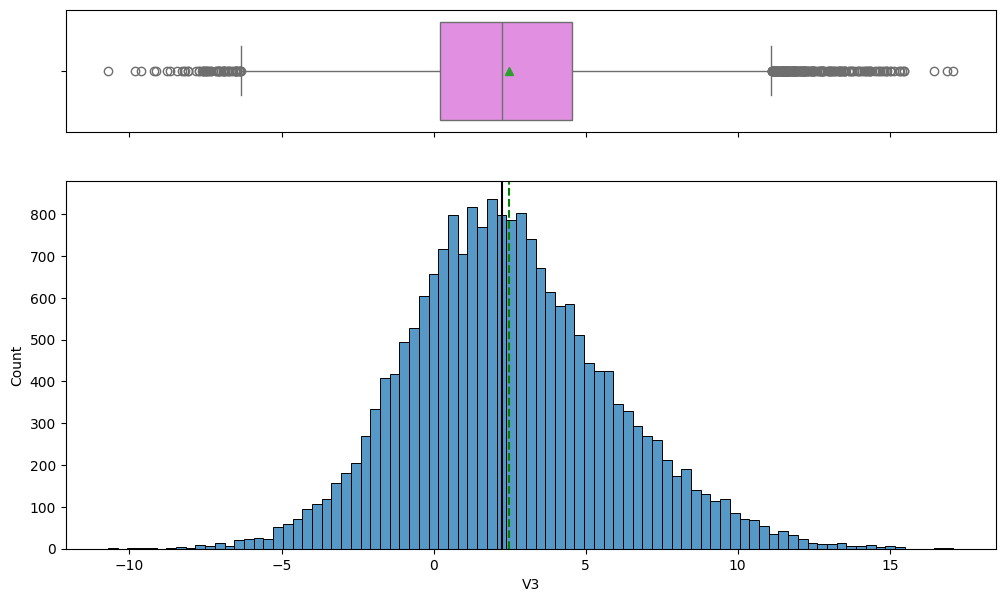

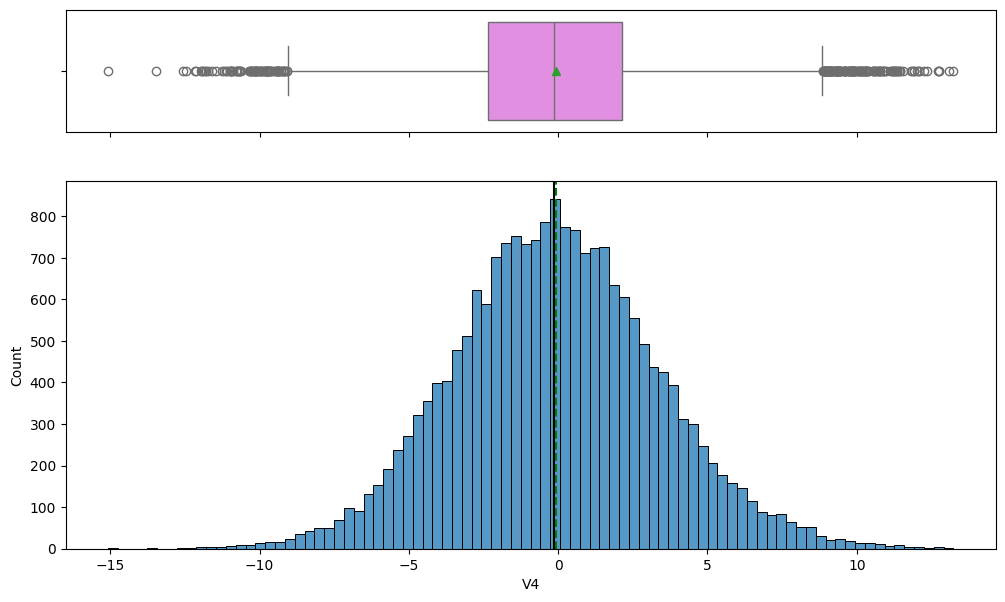

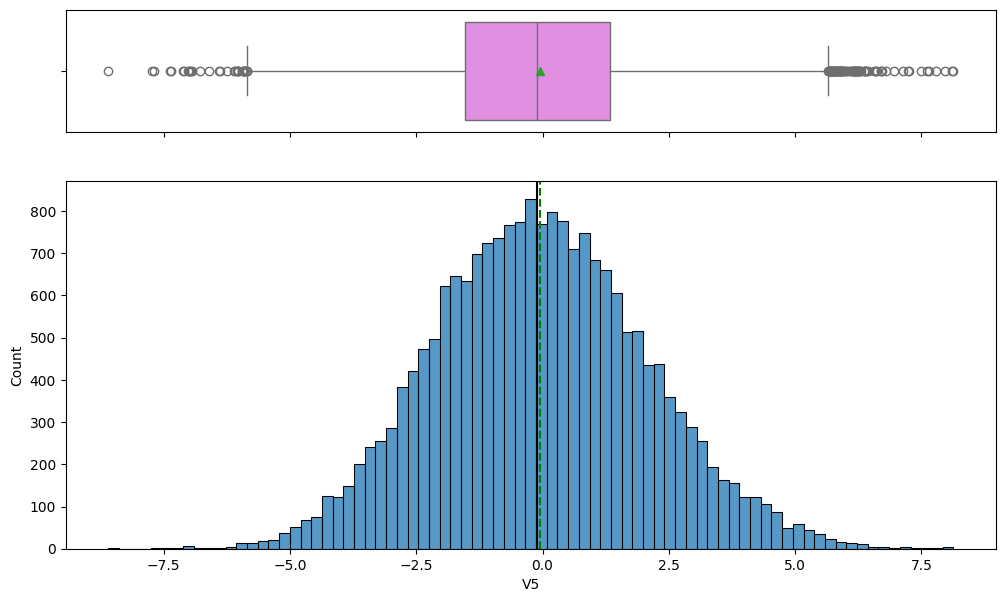

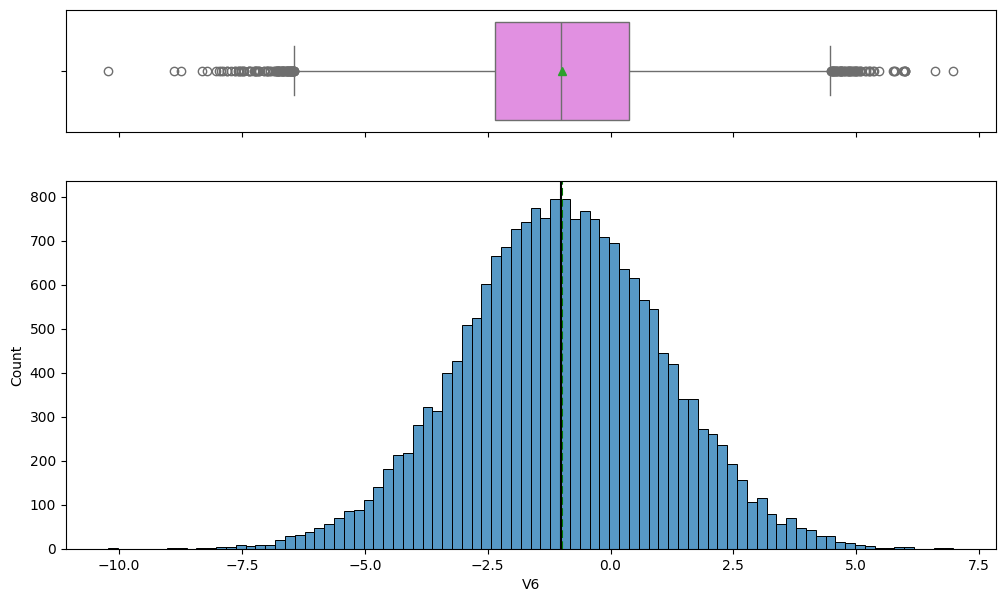

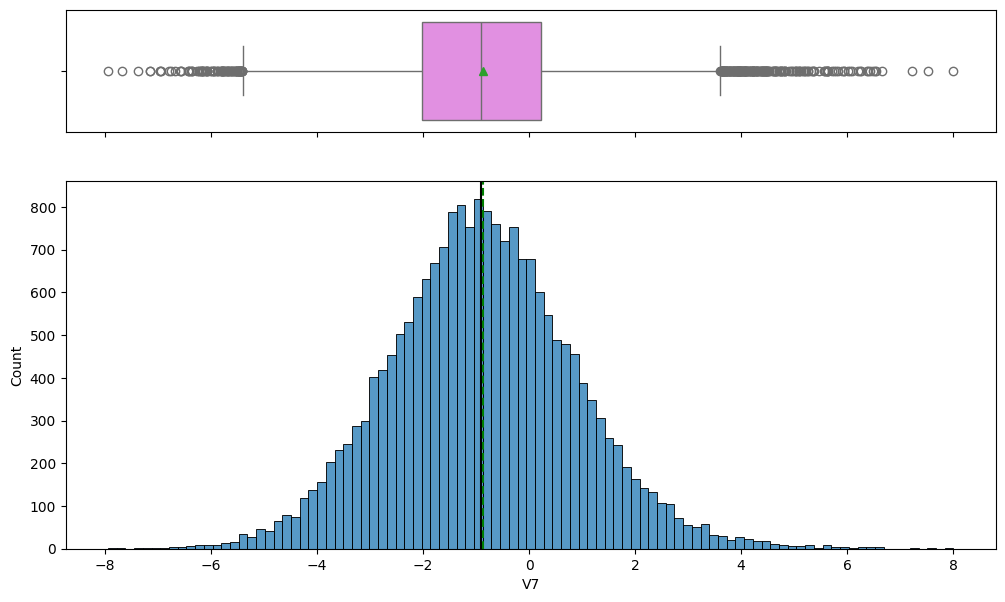

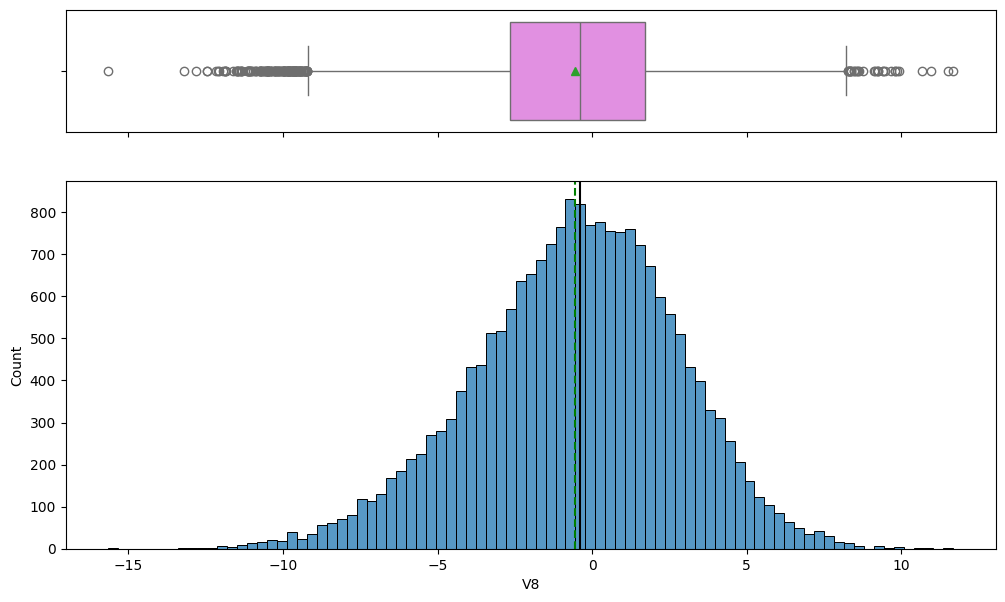

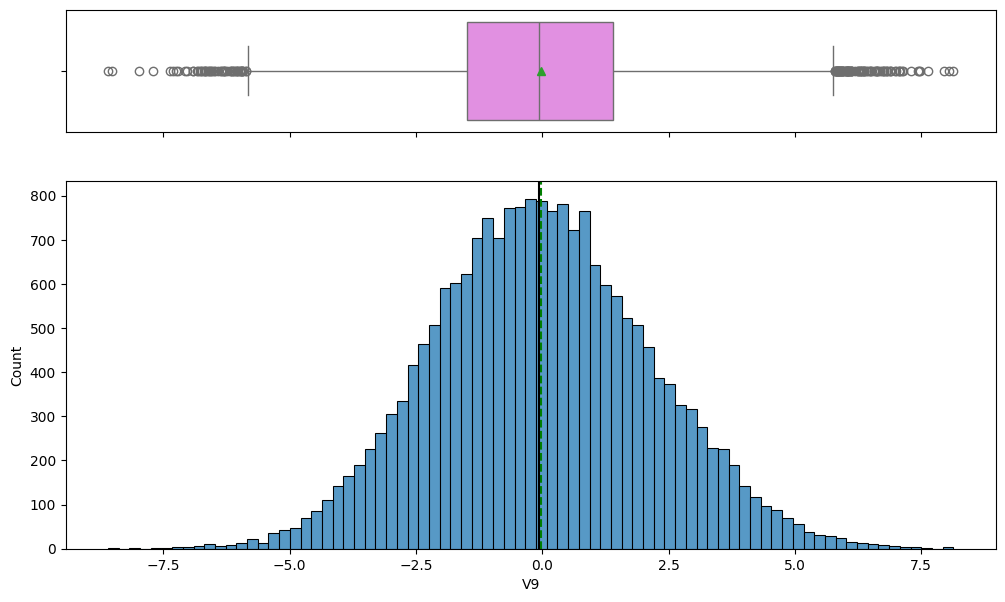

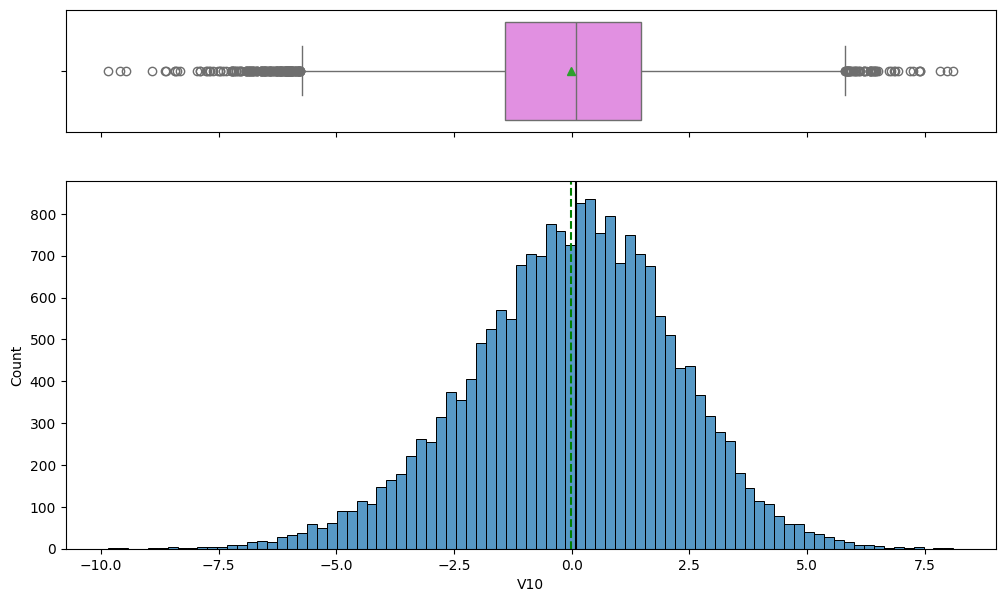

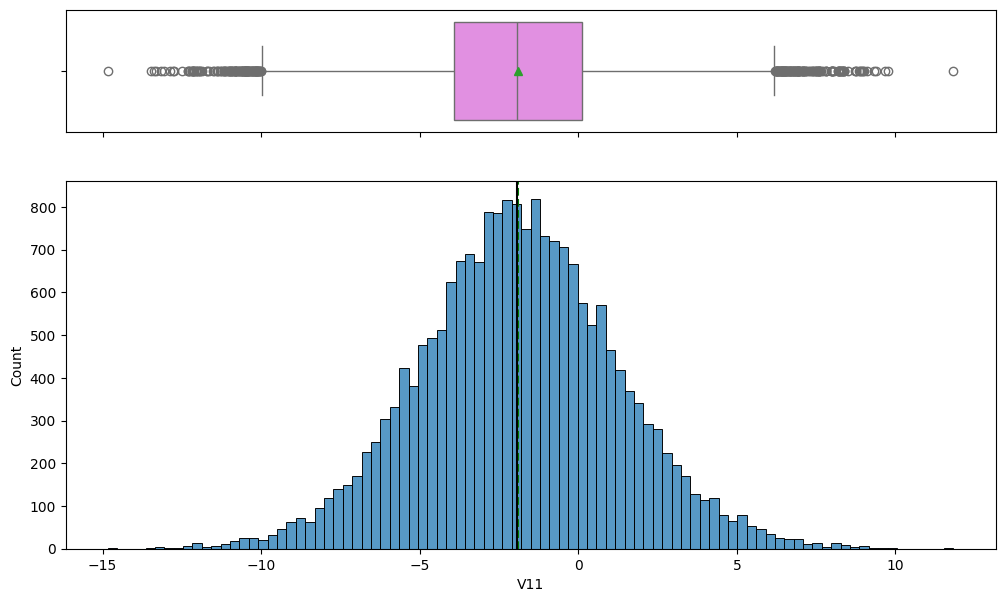

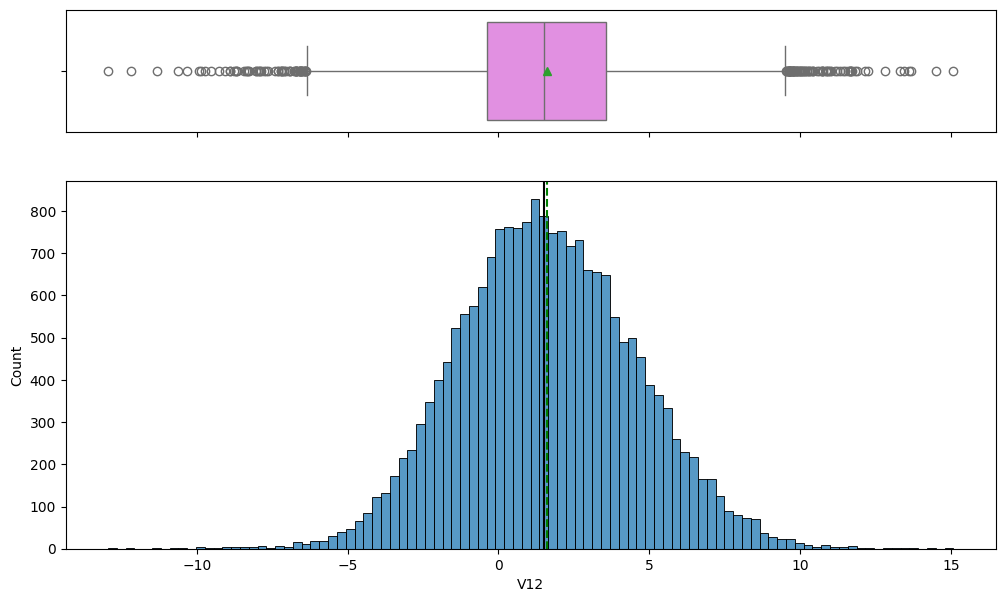

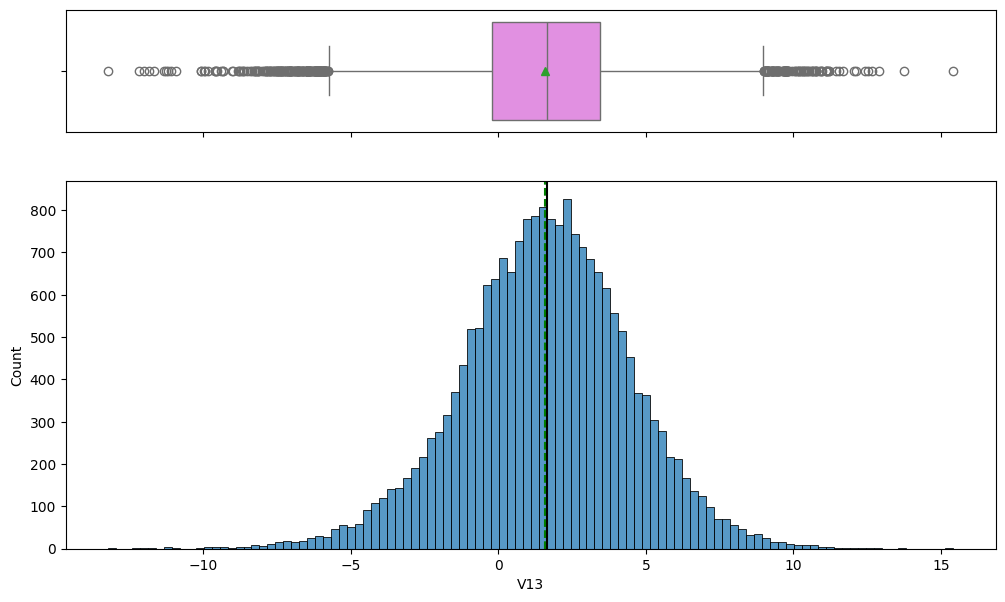

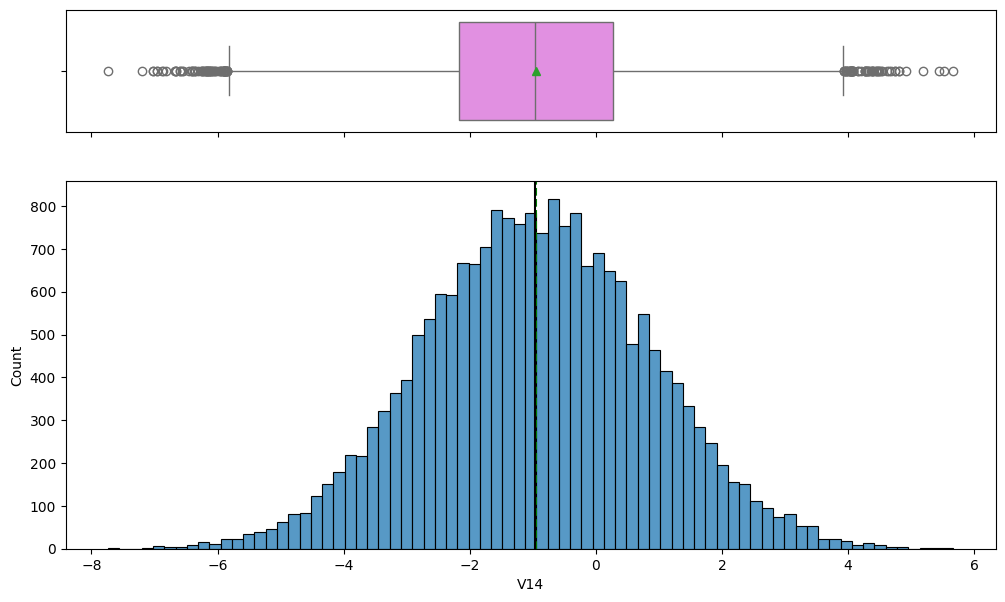

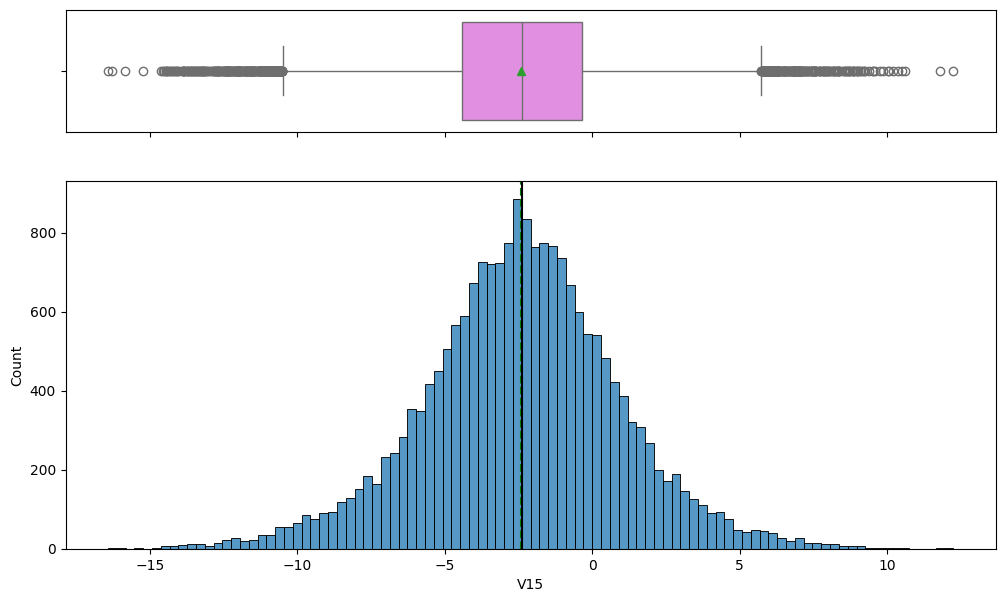

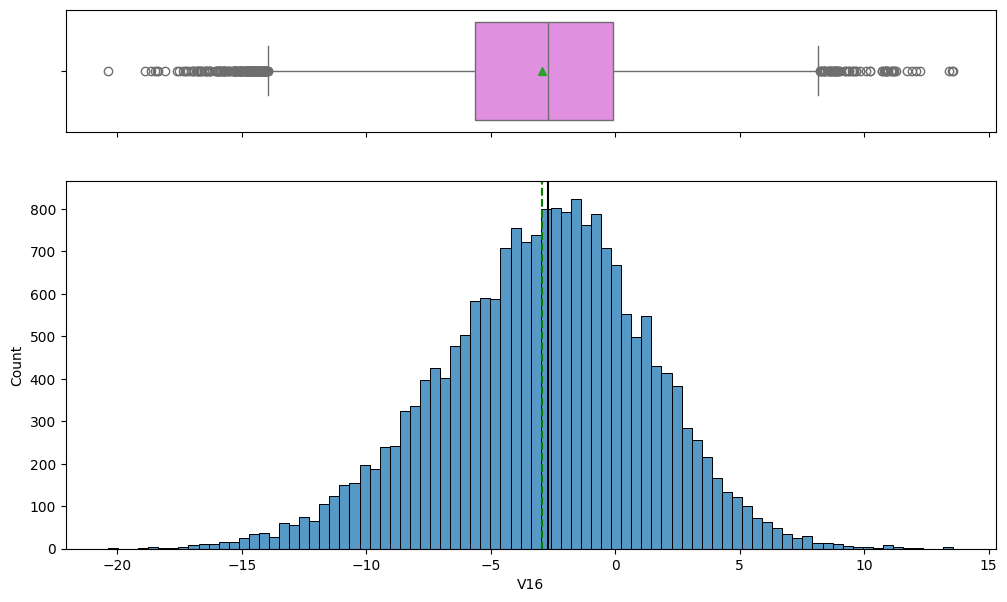

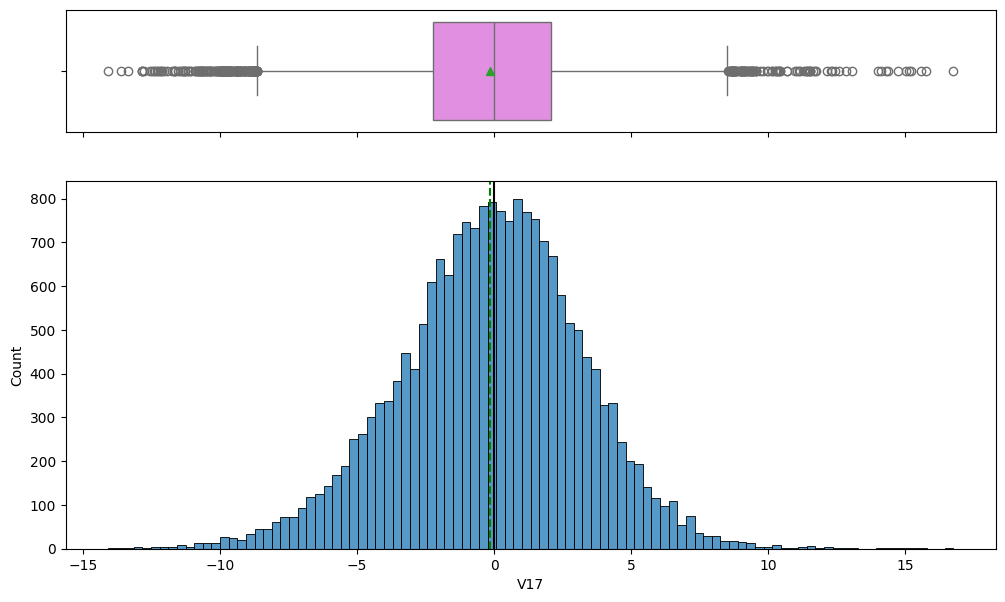

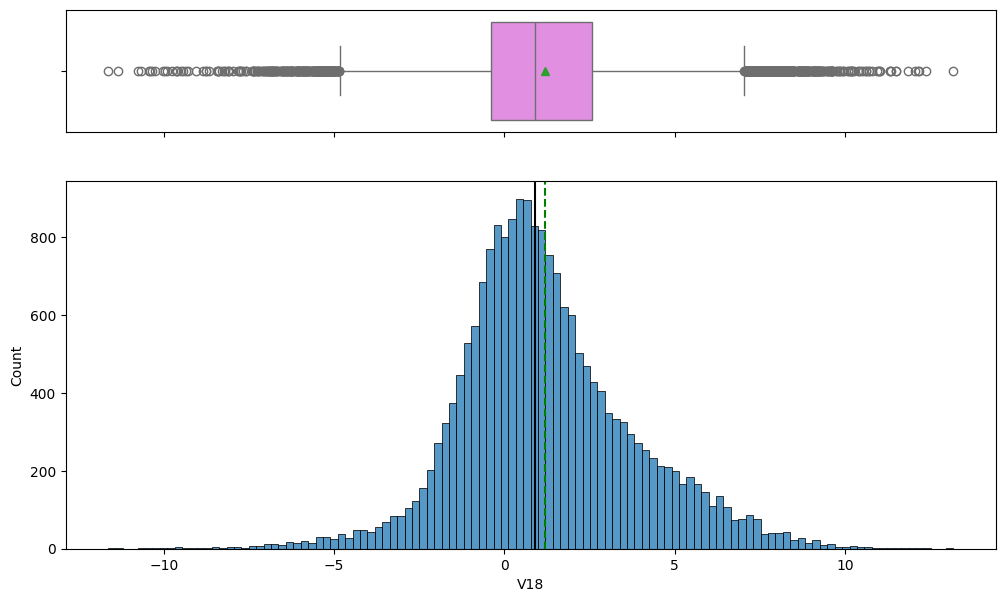

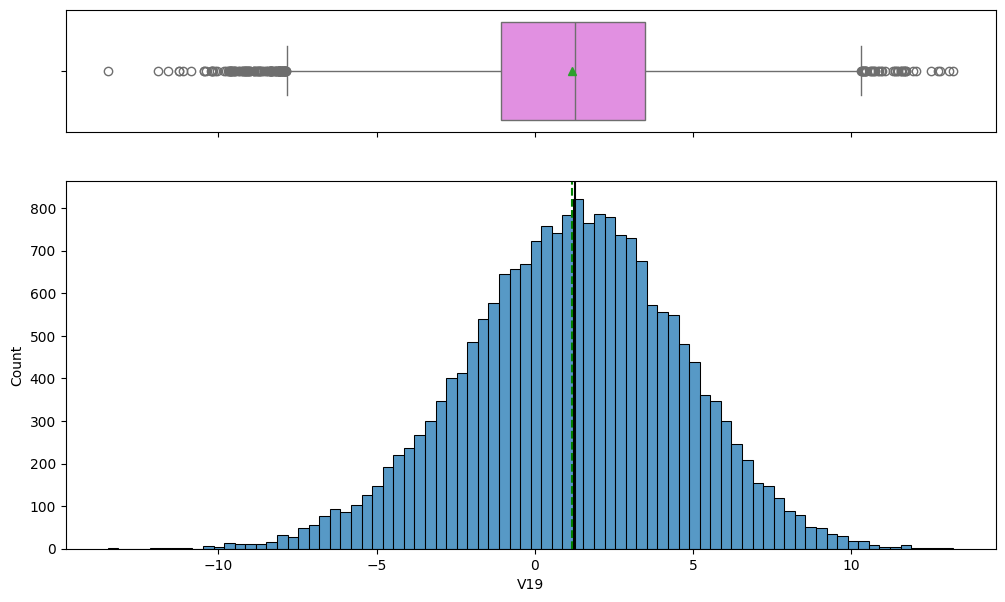

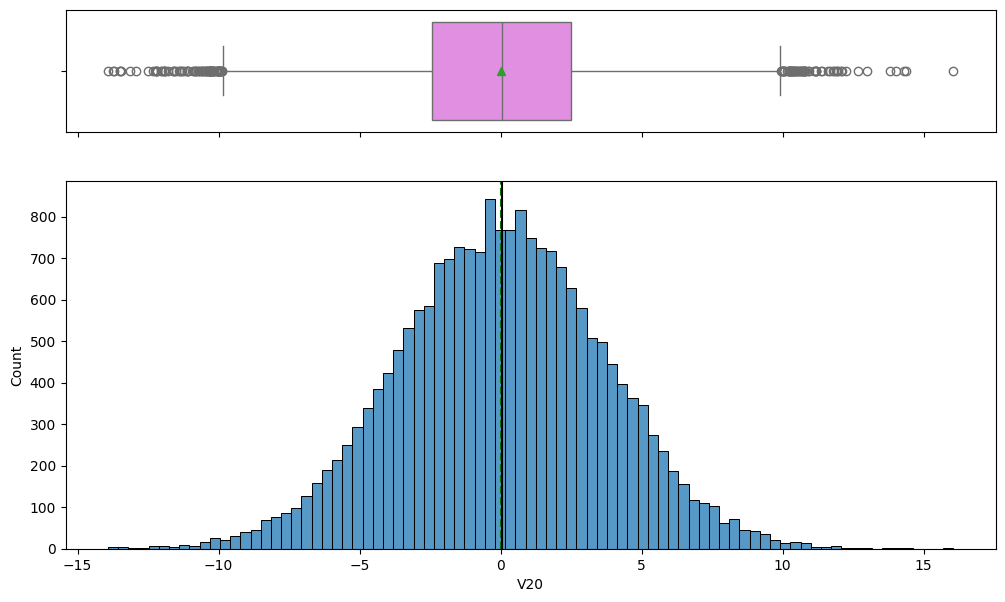

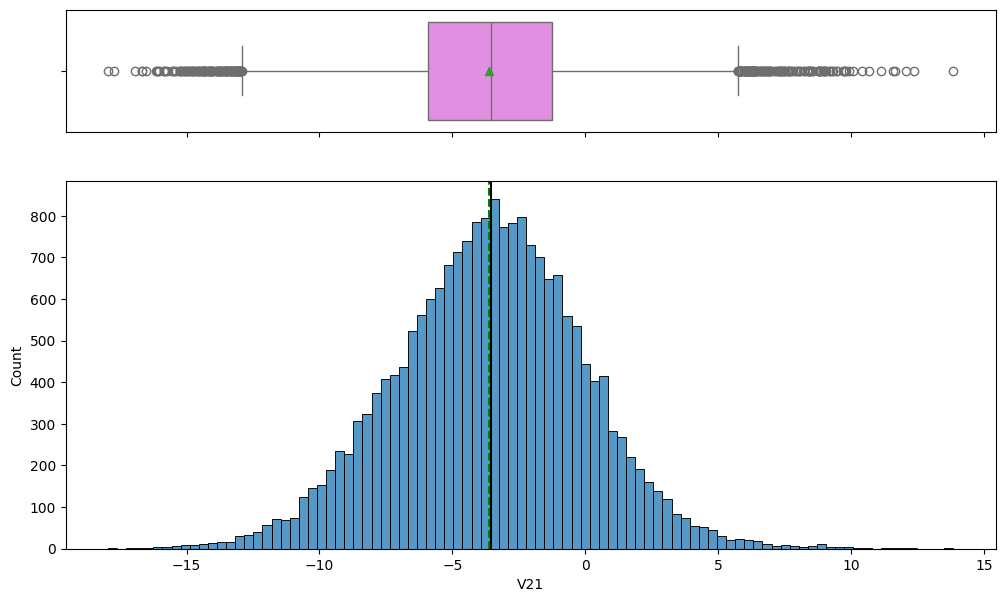

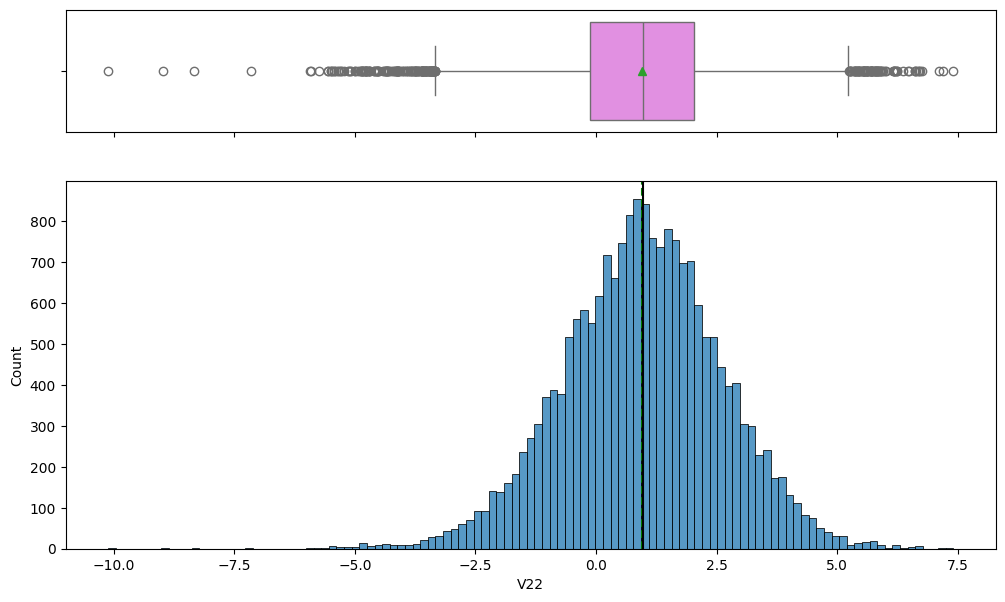

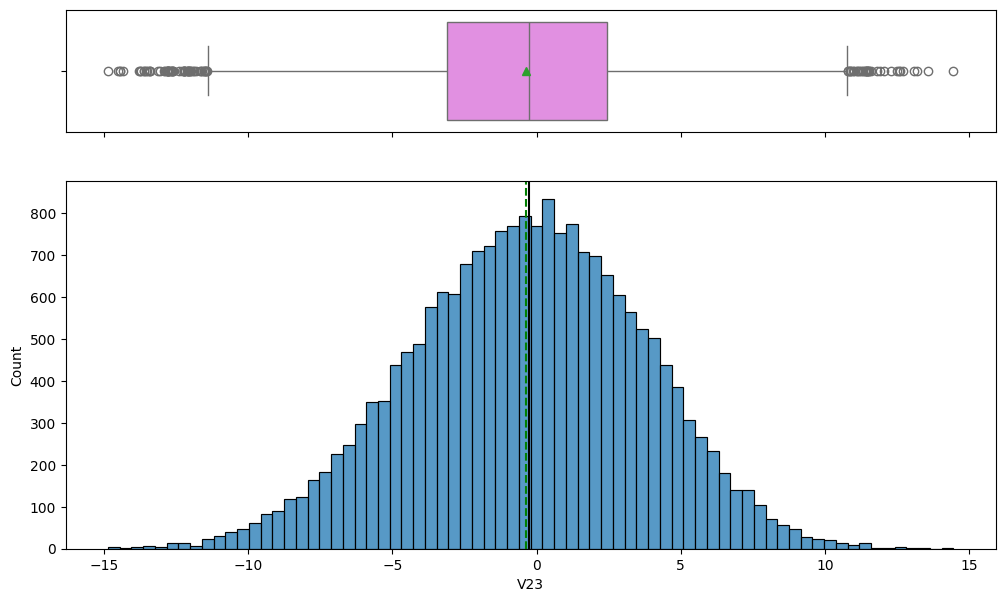

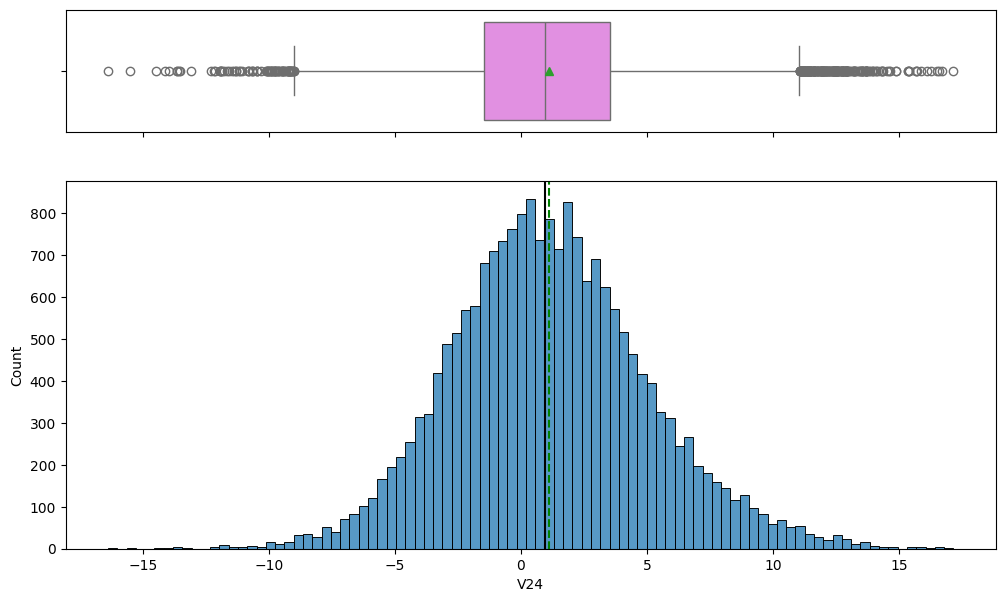

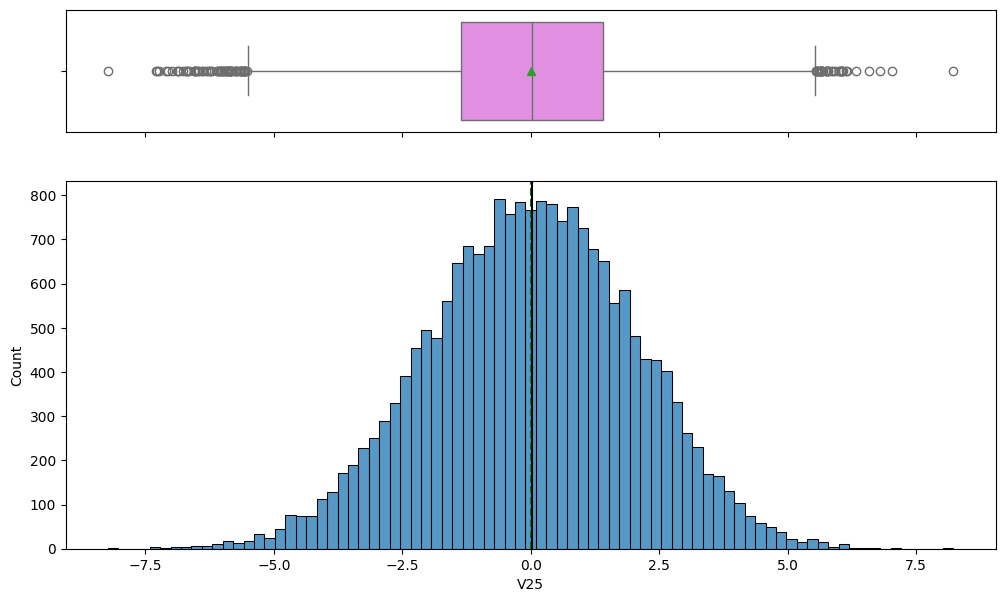

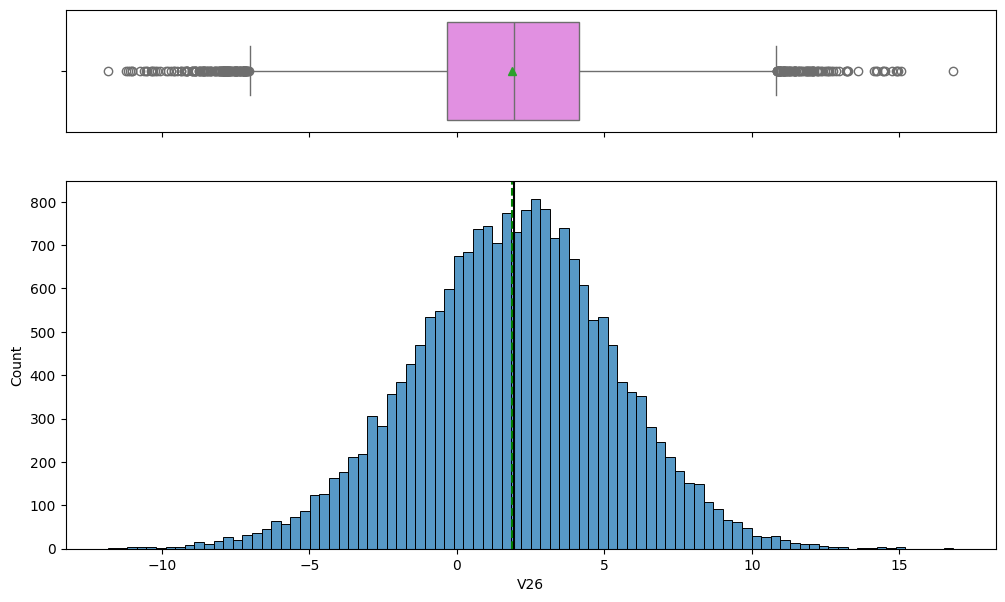

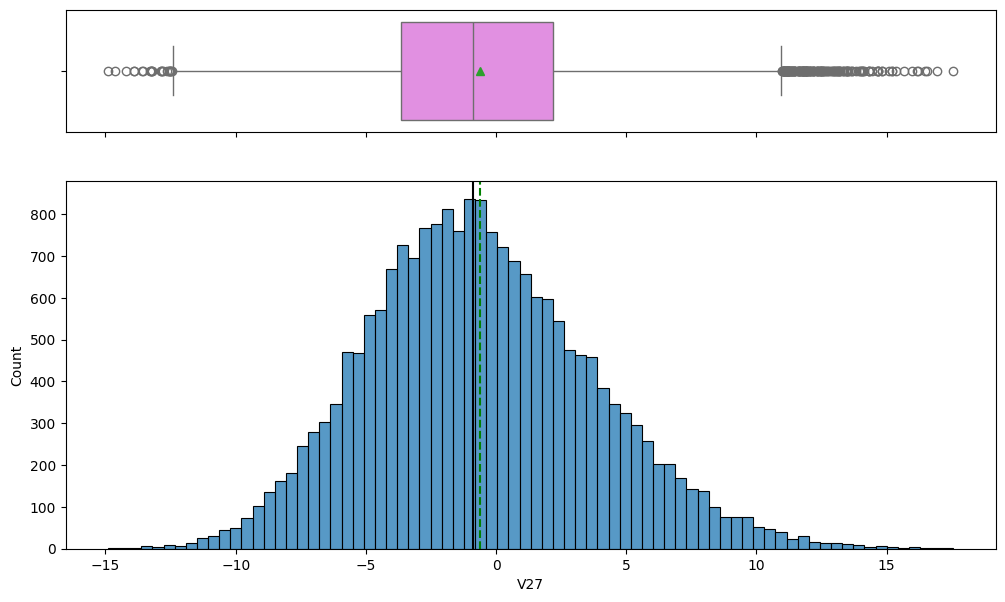

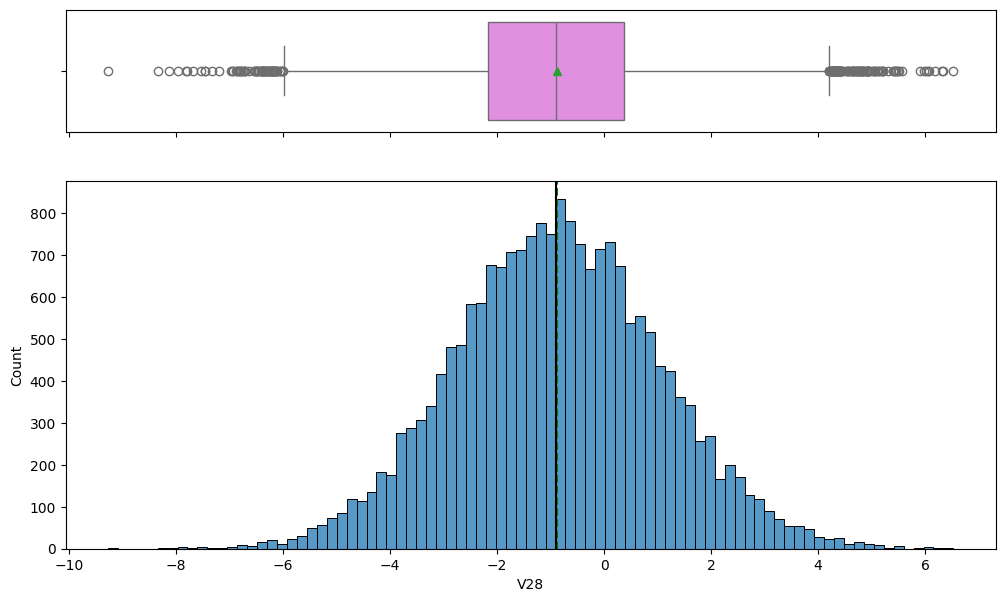

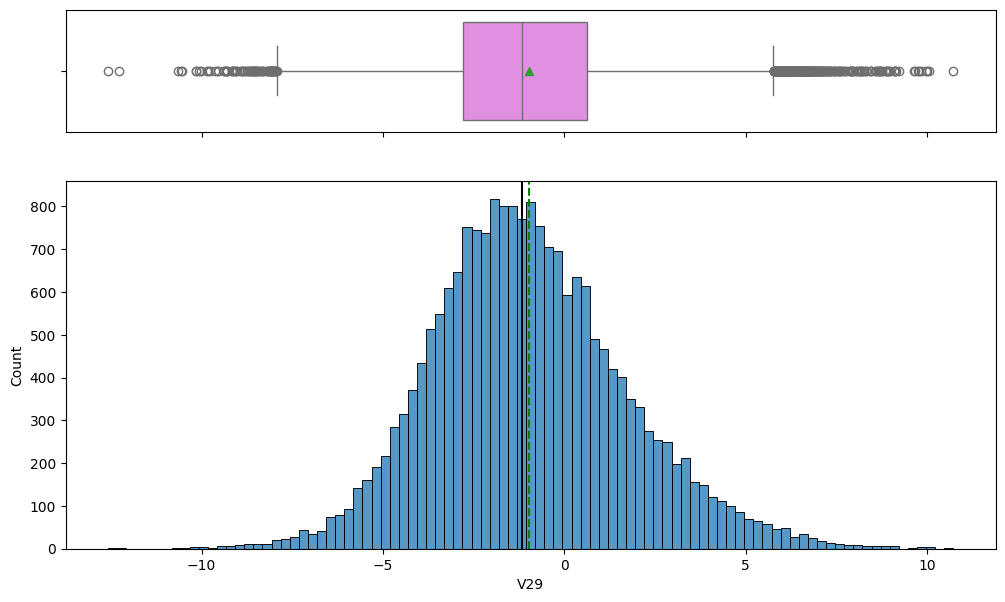

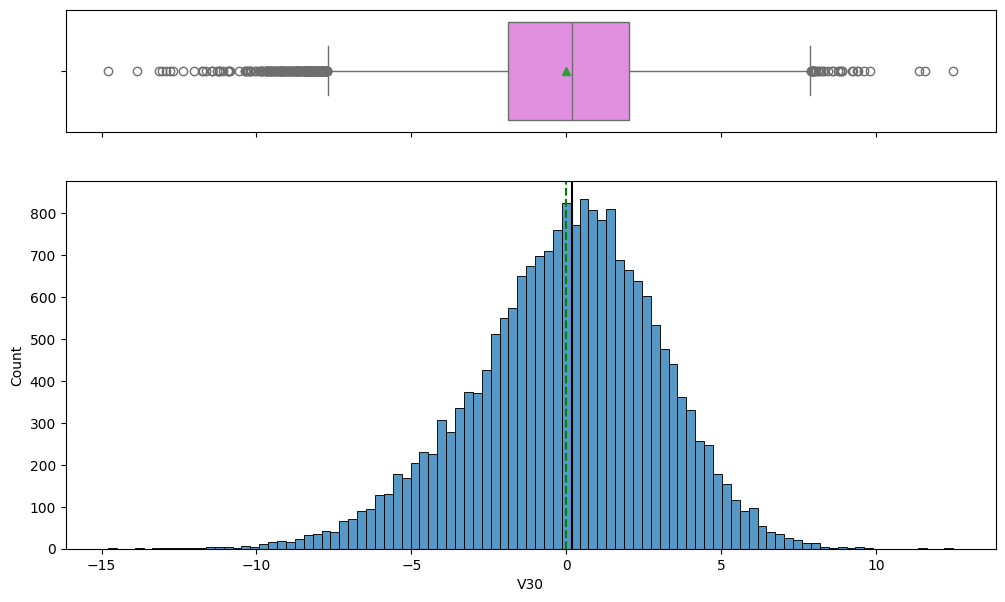

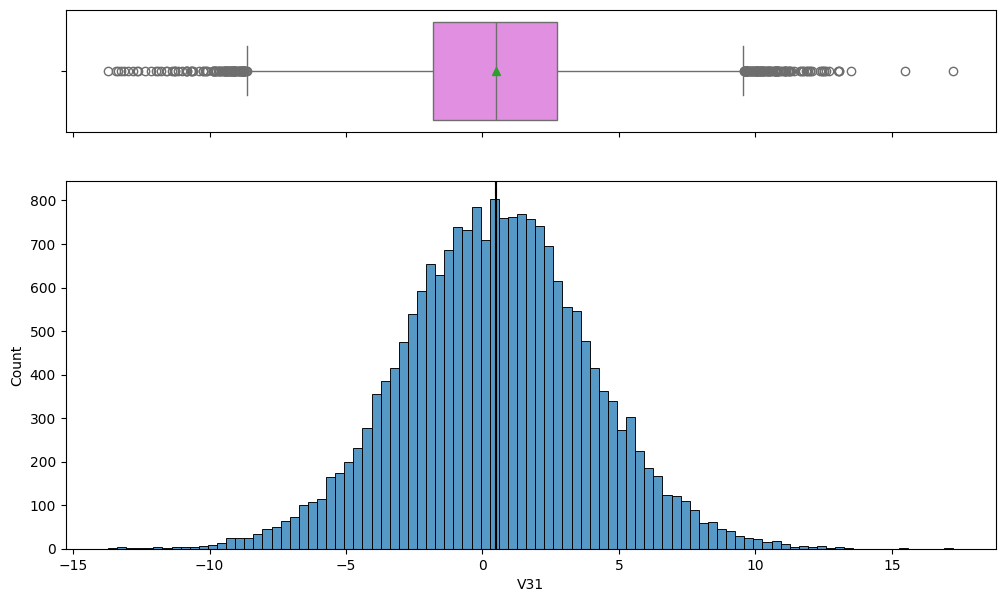

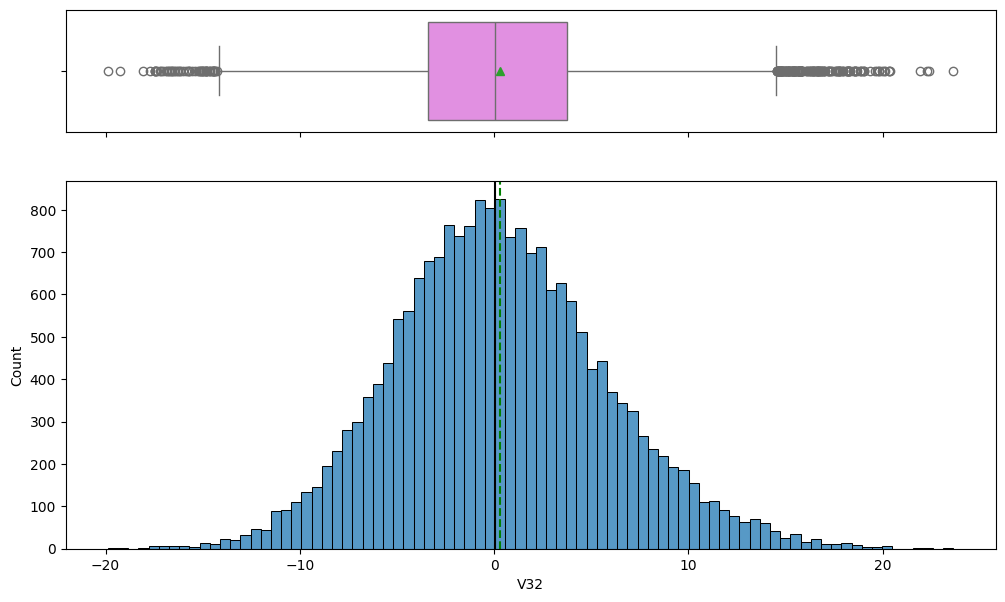

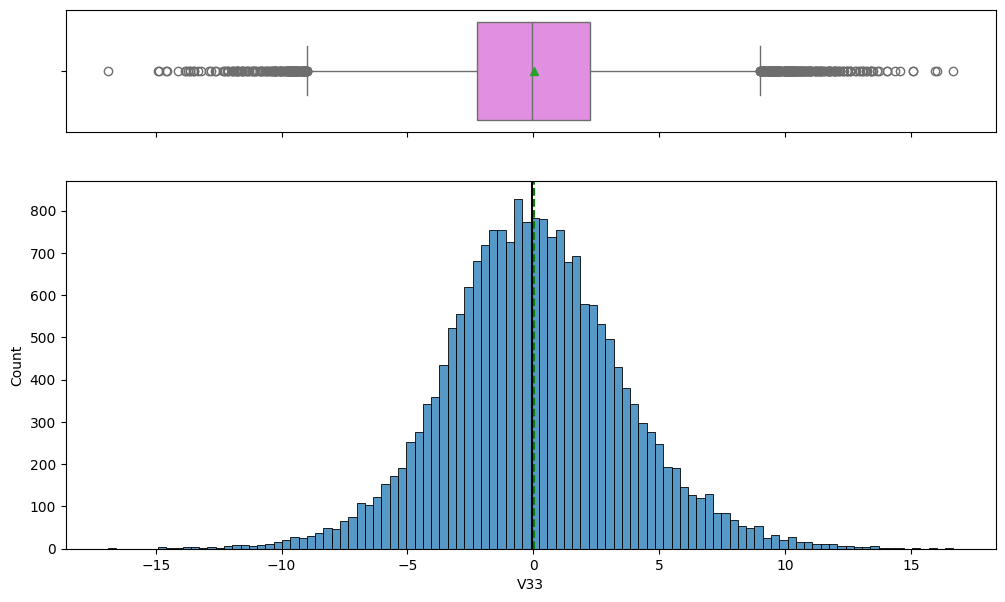

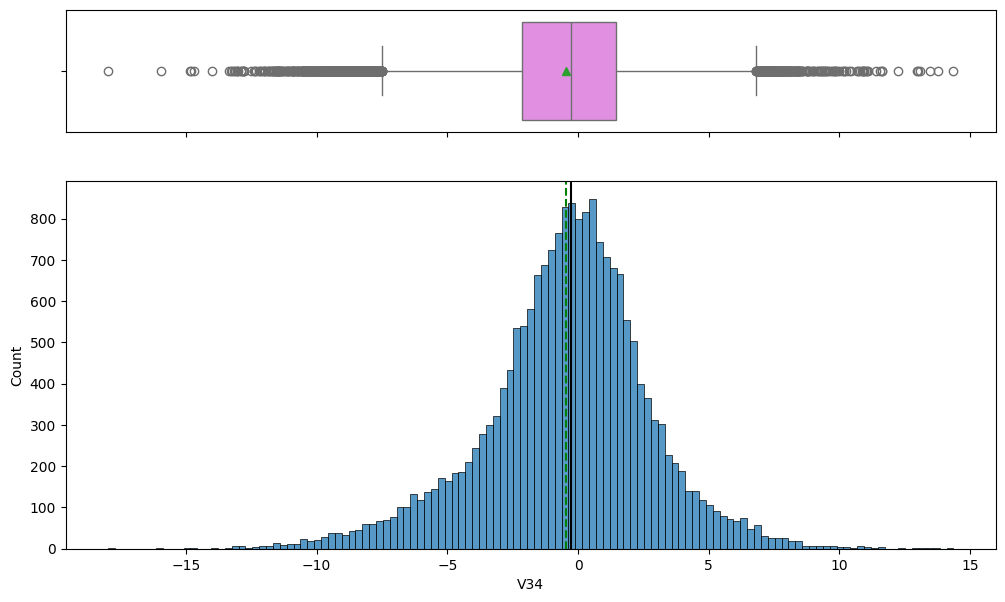

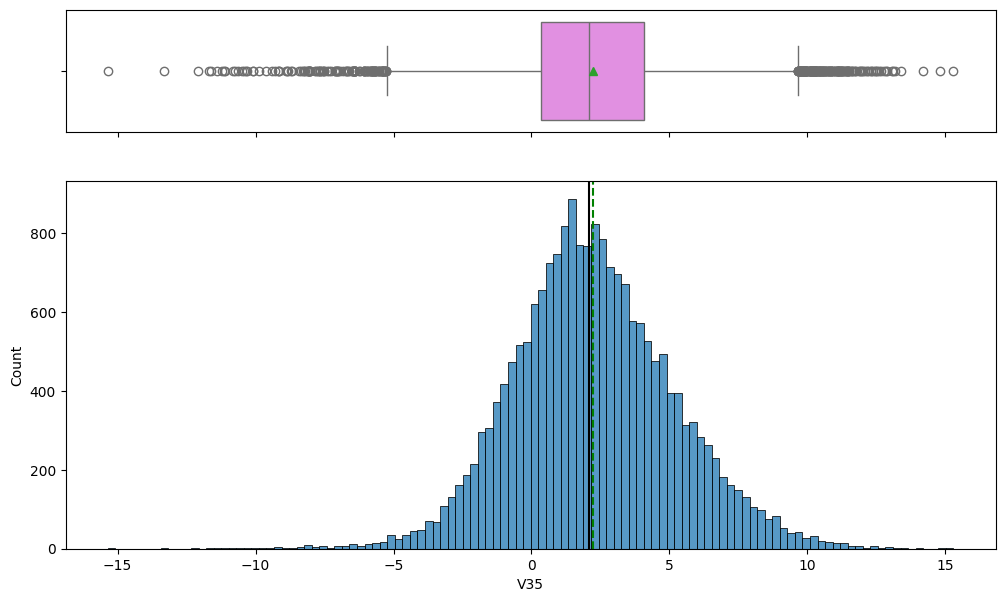

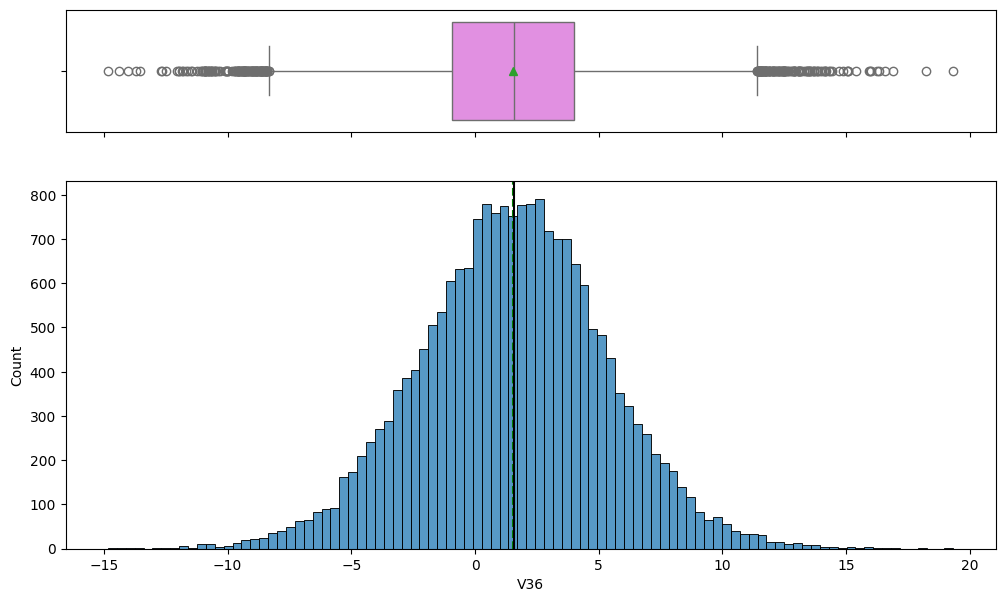

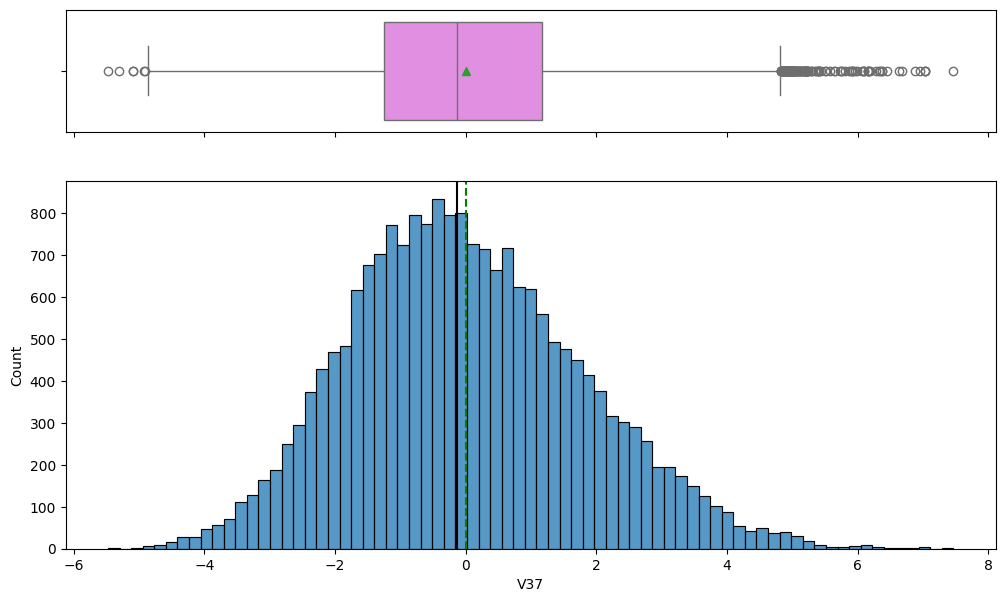

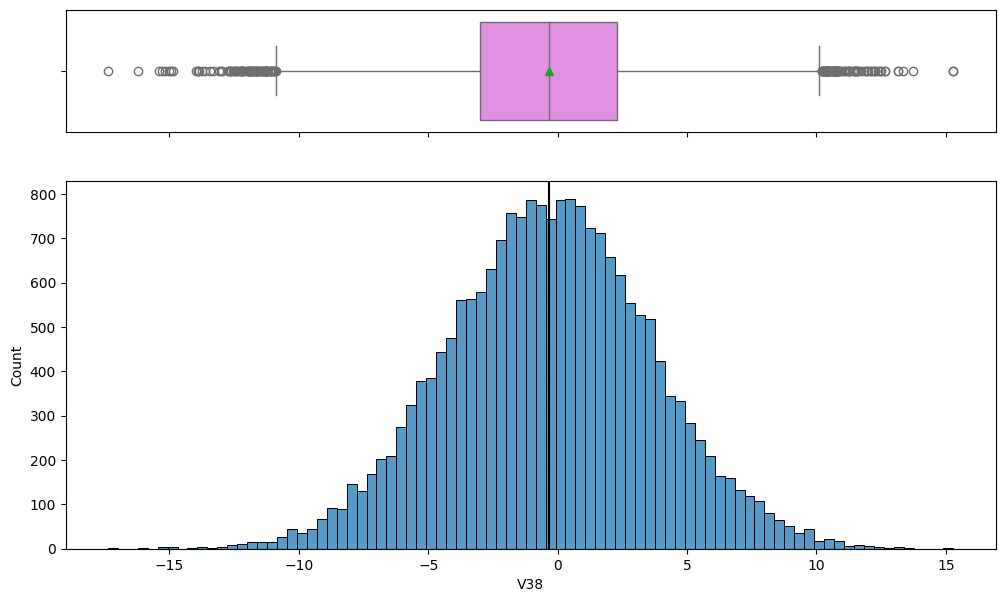

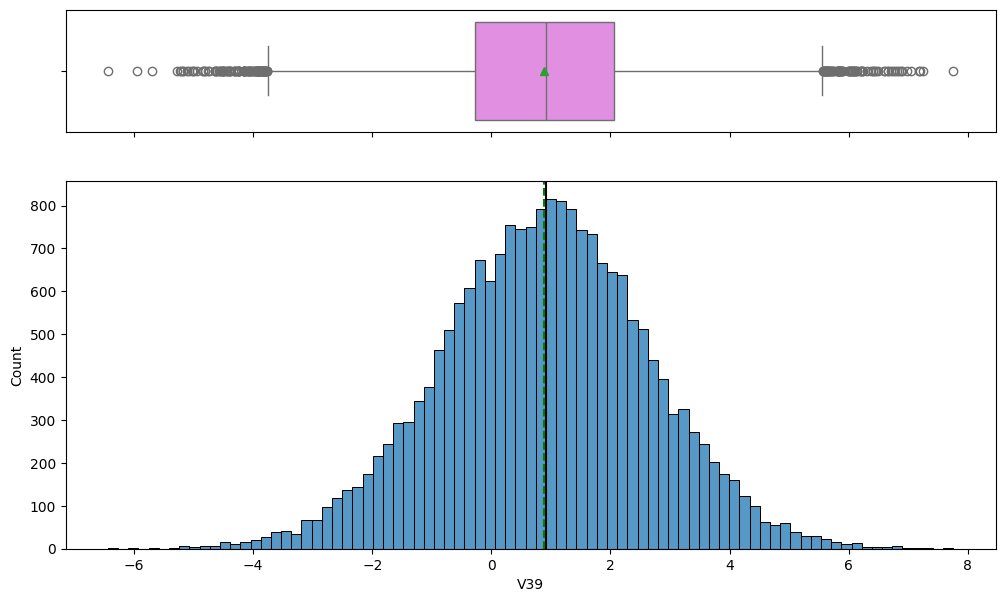

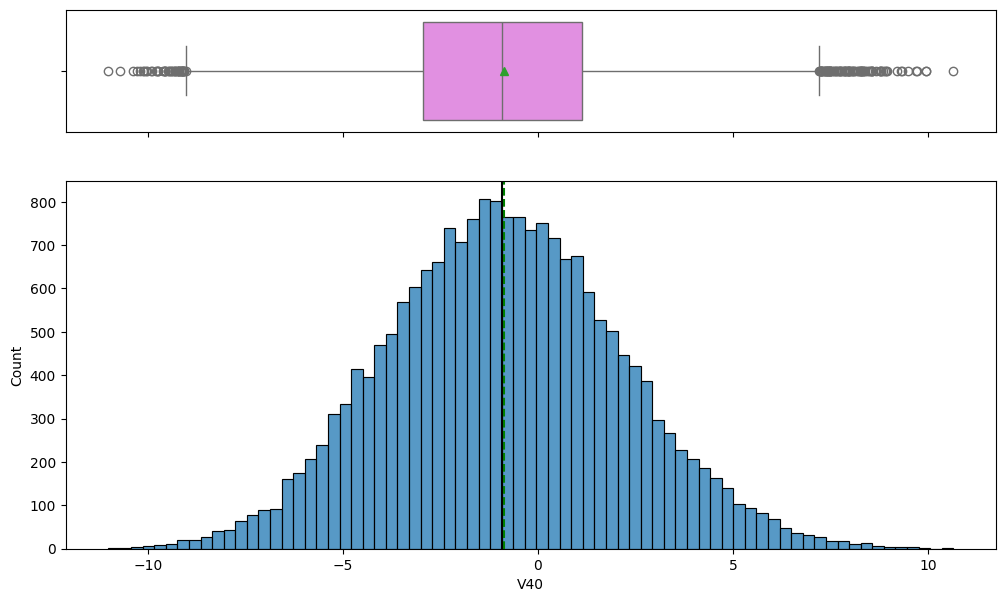

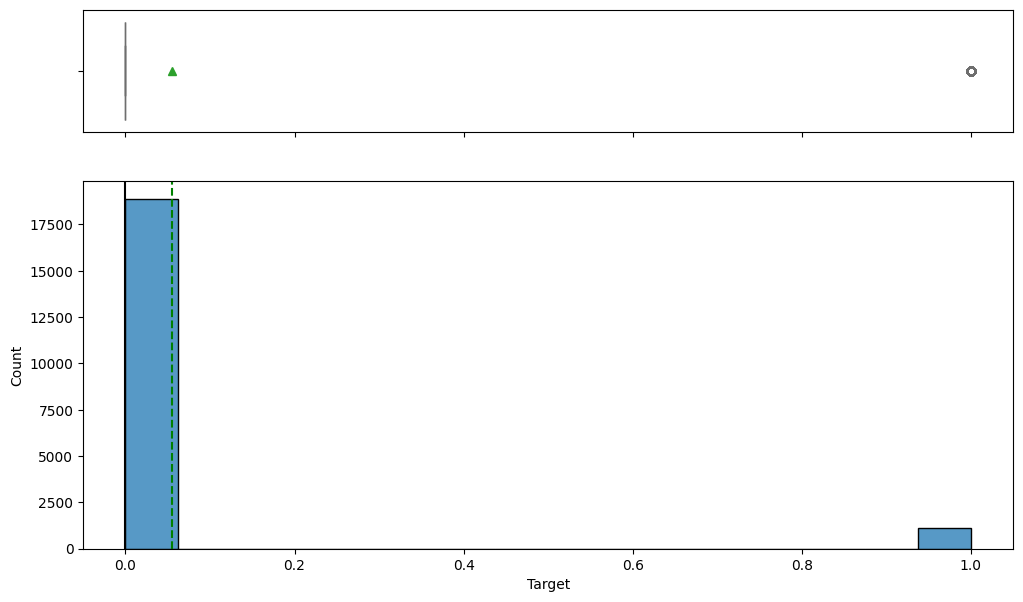

In [ ]:
for feature in df_train.columns:
    histogram_boxplot(df_train, feature, figsize=(12, 7), kde=False, bins=None)

Observations/Insights from Histogram-Boxplot Visualizations:

1. Skewness & Distribution Shapes:

* Many features have right-skewed distributions, meaning they have long tails towards higher values.
  *Examples: V3, V7, V12, V18, V26
  * Impact: May require log transformation or scaling for models like logistic regression or SVM.
* Some features follow approximately normal distributions, making them naturally well-suited for machine learning models.
  * Examples: V4, V11, V17
  * Action: No transformation needed.

2. Mean vs. Median Differences:

* The mean (green line) and median (black line) are far apart in several features, indicating skewness.
  * If the median is lower than the mean: It suggests right-skewed data.
  * If the median is higher than the mean: It suggests left-skewed data.
* Action: Standardization or log transformations may help balance distributions.

3. Presence of Outliers:

* Several features have extreme outliers, indicated by individual points outside the whiskers in the boxplots.
* Examples: V1, V5, V10, V20, V28, and V32 have long tails and extreme values.

4. Feature Variance & Importance Consideration:

* Low-variance features (flat histograms) contribute little information to the model.
  * Examples: V8, V13, V15, V21

5. Data Imbalance in Some Features:

* Some features show imbalanced distributions, meaning most values are concentrated within a small range.



## Data Pre-processing

In [ ]:
# Split Features (X) and Target (y) # Features
X = df_train.drop(columns=['Target']) # Target variable
y = df_train['Target']

# Split into Training (75%) and Validation (25%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=1, stratify=y)

# Display dataframe of shapes of the resulting datasets
shapes = {
    "Dataset": ["X_train", "X_val", "y_train", "y_val"],
    "Shape": [X_train.shape, X_val.shape, y_train.shape, y_val.shape]
}

# Display dataframe
pd.DataFrame(shapes)

,Dataset,Shape
0,X_train,"(15000, 40)"
1,X_val,"(5000, 40)"
2,y_train,"(15000,)"
3,y_val,"(5000,)"


Observations/Insights:
* The dataset has been successfully split
* This step is critical before imputation to avoid data leakage.


## Missing value imputation




In [ ]:
# Handle Missing Values (Imputation), fit the imputer on X_train, transform X_train, X_val, and X_test using the same imputer.

# Initialize imputer (Median Imputation)
imputer = SimpleImputer(strategy="median") # median used, variables are numeric in nature

# Fit only on X_train and transform
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(df_test.drop(columns=["Target"], errors="ignore"))

# Convert back to DataFrame to keep column names
columns = df_test.drop(columns=["Target"], errors="ignore").columns
X_train = pd.DataFrame(X_train, columns=columns)
X_val = pd.DataFrame(X_val, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

# Check the shapes and ensure no missing values
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test.isnull().sum().sum()}")


X_train: (15000, 40), X_val: (5000, 40), X_test: (5000, 40)
Missing values in X_train: 0
Missing values in X_test: 0


Observations/Insights:

* No missing values remain in X_train or X_test, confirming successful imputation.

* The dataset shapes confirm:

  * X_train (15,000 rows, 40 features)
  * X_val (5,000 rows, 40 features)
  * X_test (5,000 rows, 40 features)

## Outlier Detection & Treatment (if needed)

* Tree-based models (XGBoost, Random Forest) can handle outliers better than linear models, but extreme outliers can still affect performance.
* Skewed distributions in some features may cause unstable model predictions.
* Precision & Recall balance may be impacted if extreme values dominate learning.
* If needed, Outlier treatment should be applied only to the training set and not the test set because:
  * Model Generalization: The test set should reflect real-world, unseen data.
  * Avoiding Data Leakage: Treating test data could cause information leakage, leading to overly optimistic performance.
  * Train Model on Realistic Data: The model should learn from a cleaned training set but be tested on original, untouched data.

In [ ]:
# Detect outliers in X_train & X_val, outputing the count

def detect_outliers_iqr(data):
  """
  Detects outliers using the Interquartile Range (IQR) method.

  Args:
    data: A pandas DataFrame or Series containing the data.

  Returns:
    A list of indices of the detected outliers.
  """
  q1 = data.quantile(0.25)
  q3 = data.quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outliers = data[(data < lower_bound) | (data > upper_bound)]
  return outliers

# Detect outliers in X_train and X_val
outlier_counts_train = {}
for column in X_train.columns:
    outliers = detect_outliers_iqr(X_train[column])
    outlier_counts_train[column] = len(outliers)

outlier_counts_val = {}
for column in X_val.columns:
    outliers = detect_outliers_iqr(X_val[column])
    outlier_counts_val[column] = len(outliers)

# Print the count of outliers in each column of X_train and X_val
print("Outlier counts in X_train:")
for column, count in outlier_counts_train.items():
    print(f"{column}: {count}")

print("\nOutlier counts in X_val:")
for column, count in outlier_counts_val.items():
    print(f"{column}: {count}")

Outlier counts in X_train:
V1: 172
V2: 130
V3: 206
V4: 172
V5: 95
V6: 117
V7: 220
V8: 144
V9: 122
V10: 153
V11: 198
V12: 121
V13: 215
V14: 92
V15: 399
V16: 173
V17: 216
V18: 561
V19: 110
V20: 118
V21: 195
V22: 180
V23: 78
V24: 214
V25: 83
V26: 187
V27: 120
V28: 129
V29: 261
V30: 181
V31: 178
V32: 161
V33: 290
V34: 597
V35: 239
V36: 177
V37: 103
V38: 120
V39: 138
V40: 98

Outlier counts in X_val:
V1: 44
V2: 51
V3: 72
V4: 64
V5: 20
V6: 39
V7: 70
V8: 47
V9: 29
V10: 65
V11: 60
V12: 28
V13: 89
V14: 33
V15: 126
V16: 59
V17: 81
V18: 176
V19: 37
V20: 37
V21: 54
V22: 62
V23: 17
V24: 89
V25: 29
V26: 53
V27: 58
V28: 50
V29: 77
V30: 63
V31: 52
V32: 71
V33: 94
V34: 197
V35: 71
V36: 83
V37: 37
V38: 43
V39: 57
V40: 40


Observations:

* Extreme outliers observed across board.

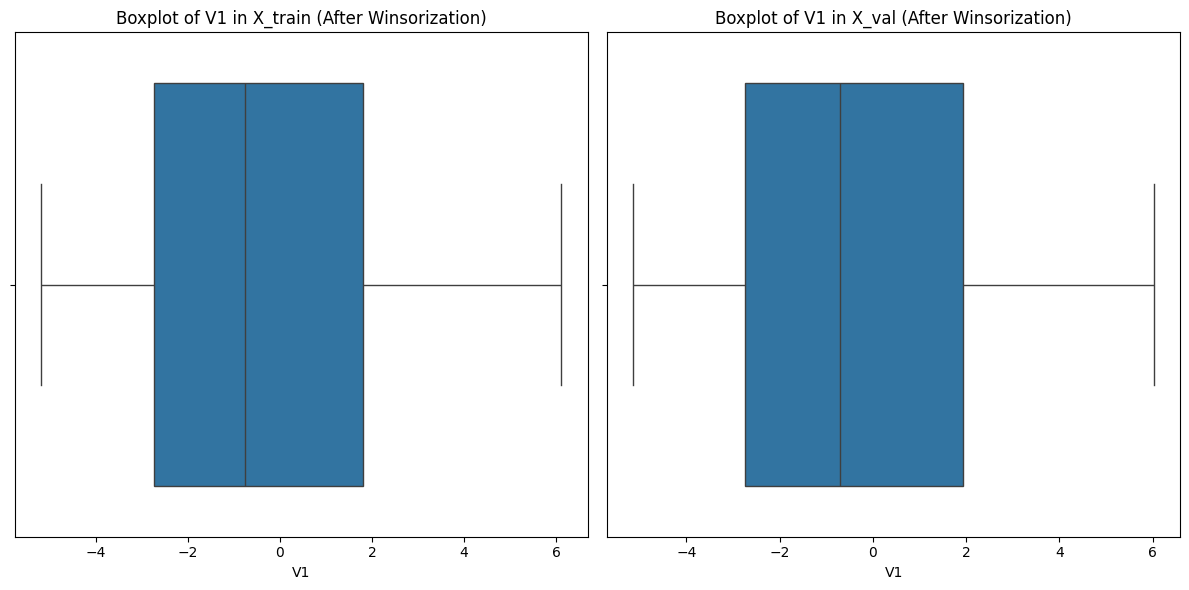

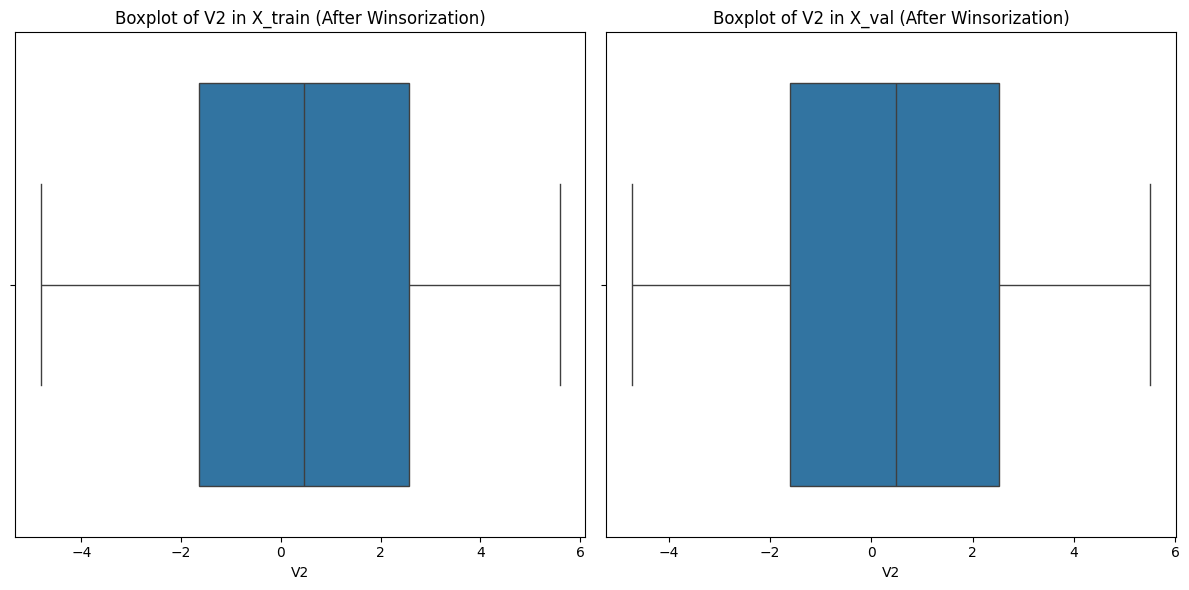

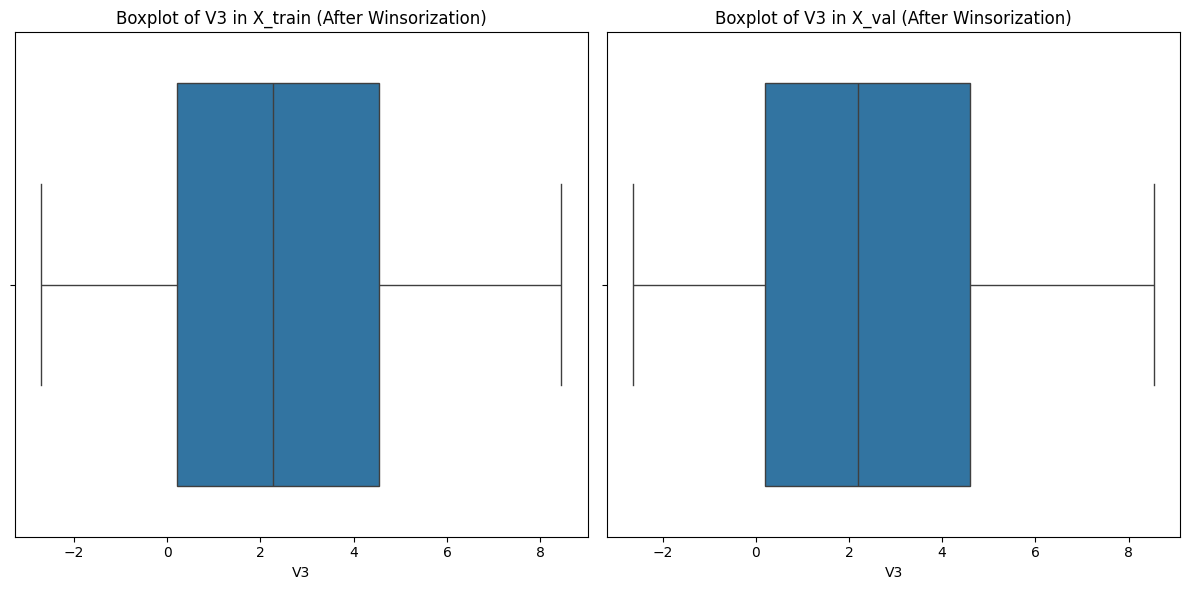

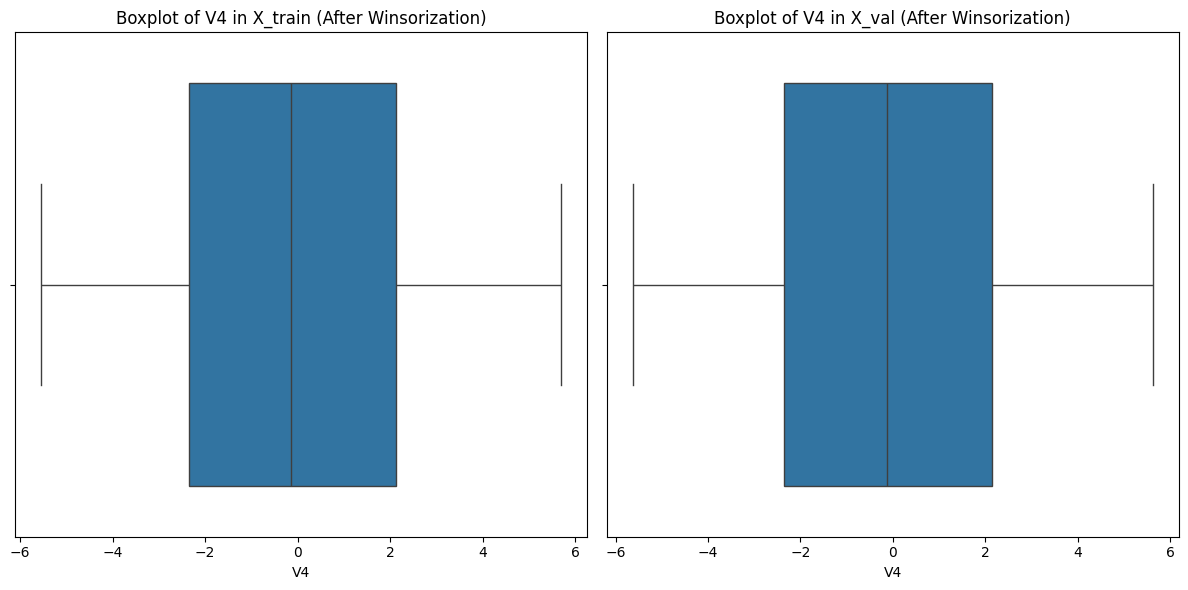

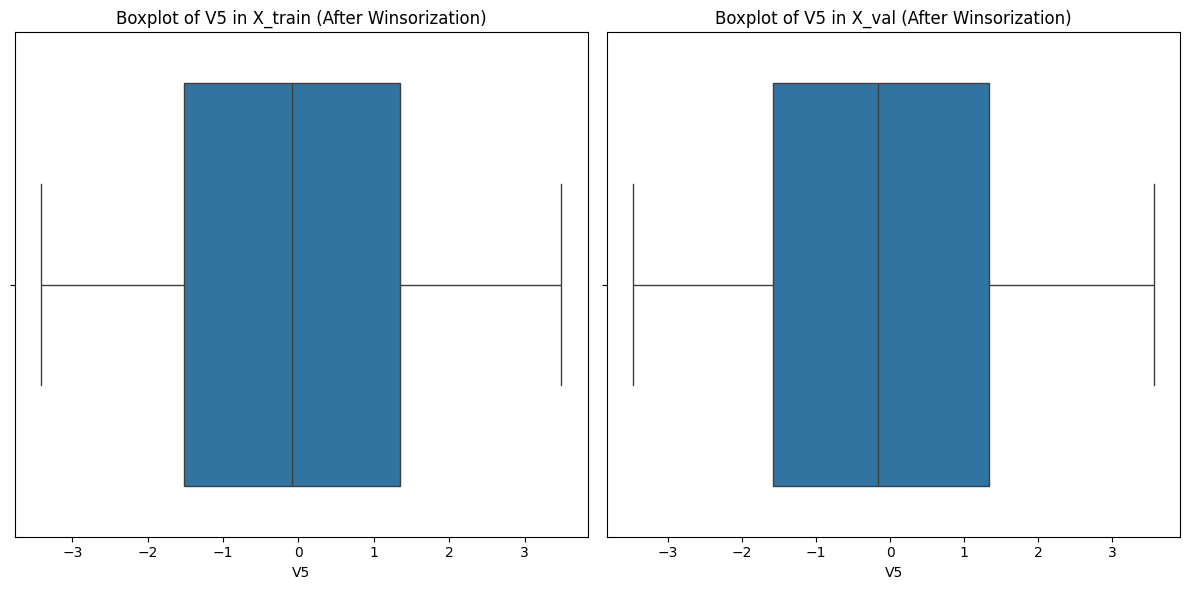

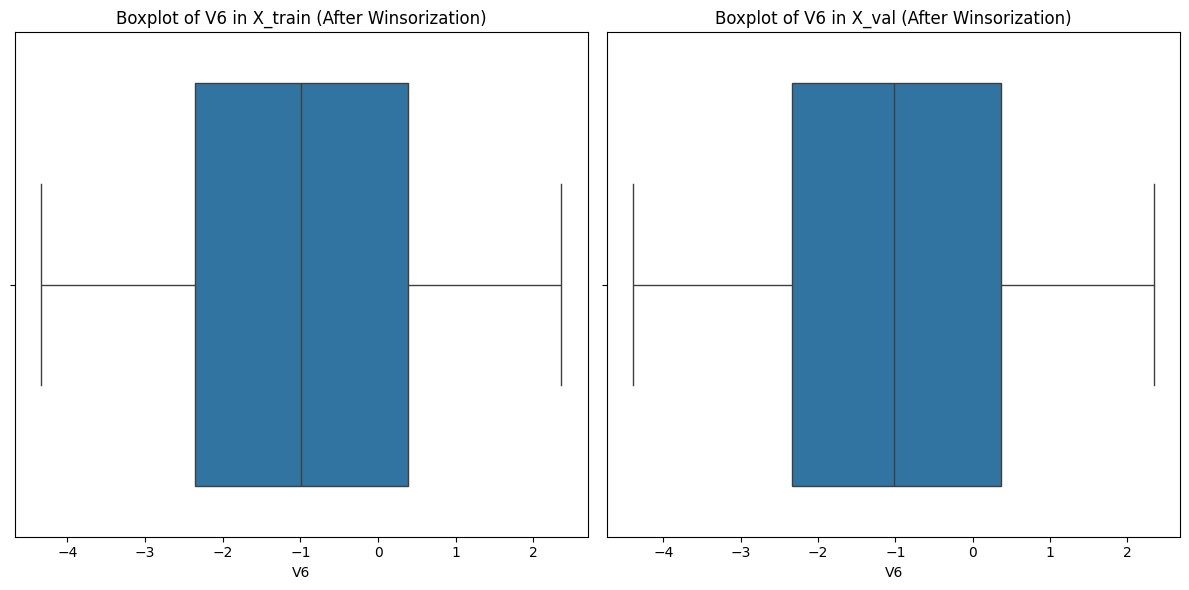

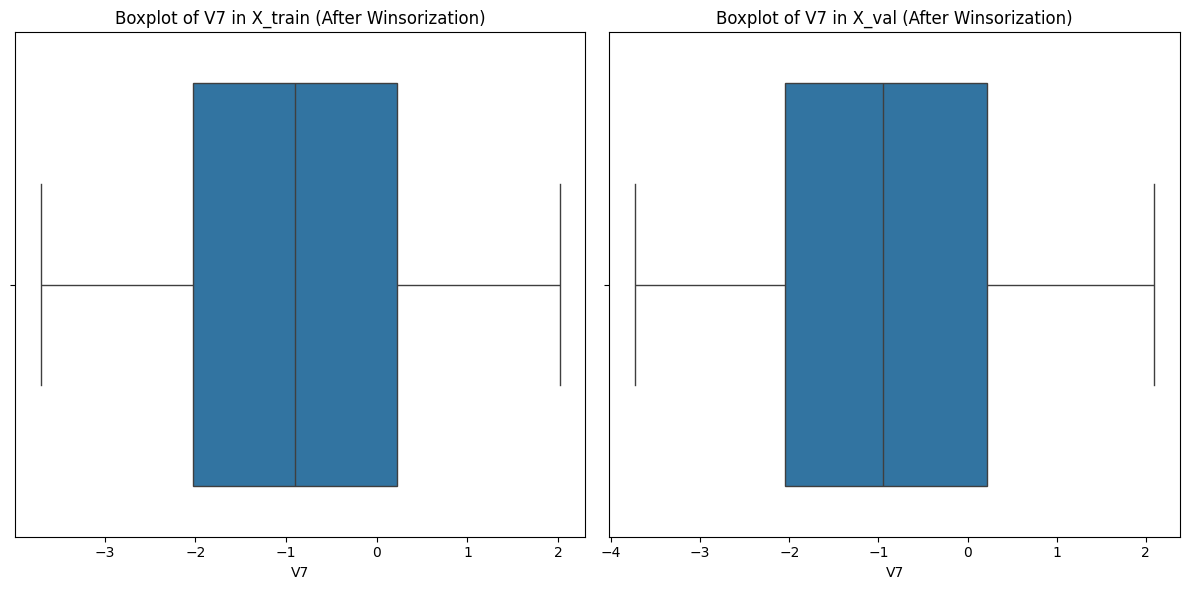

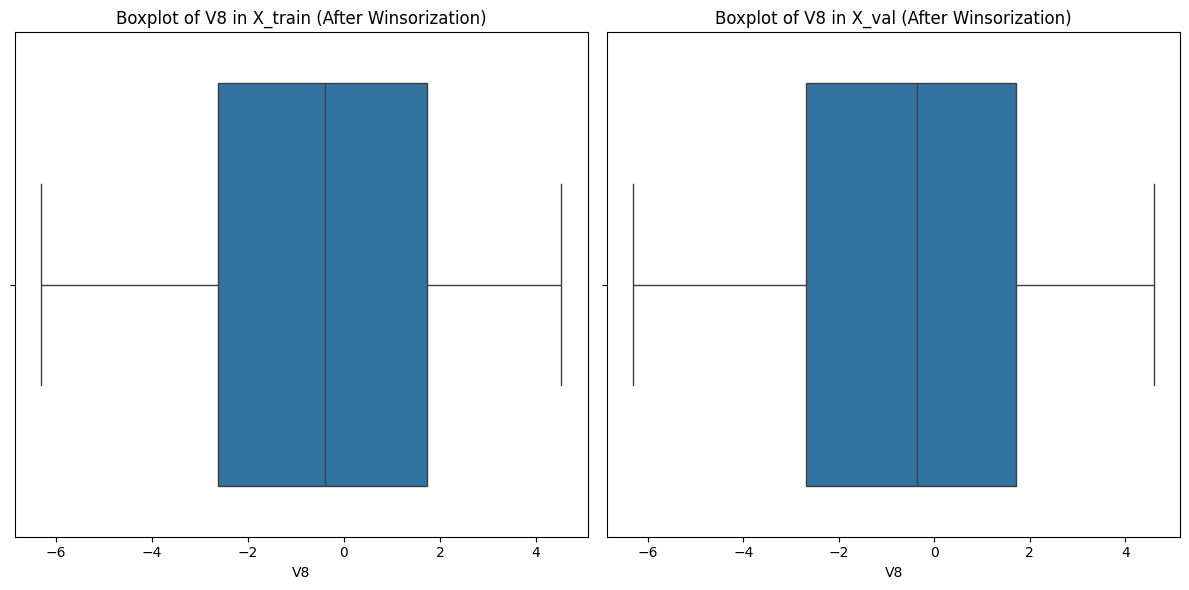

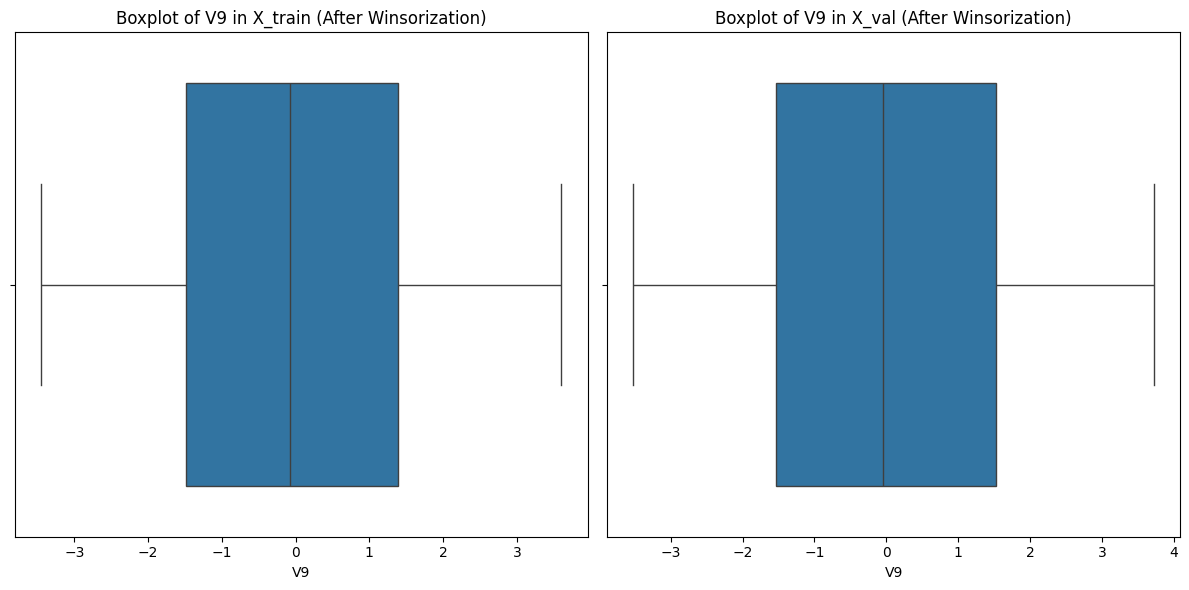

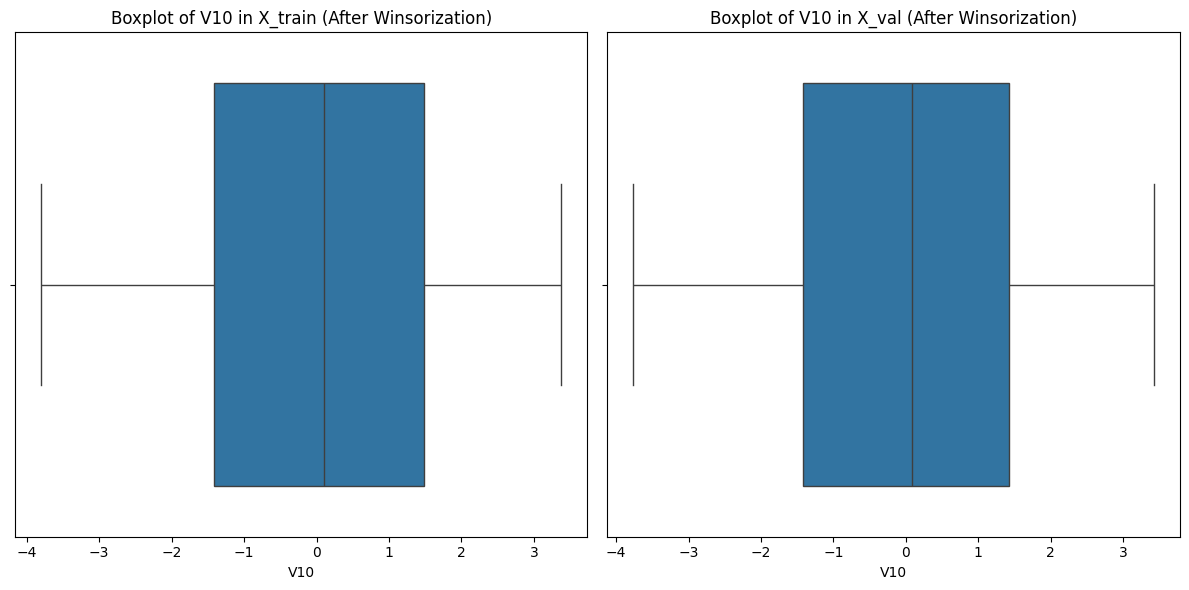

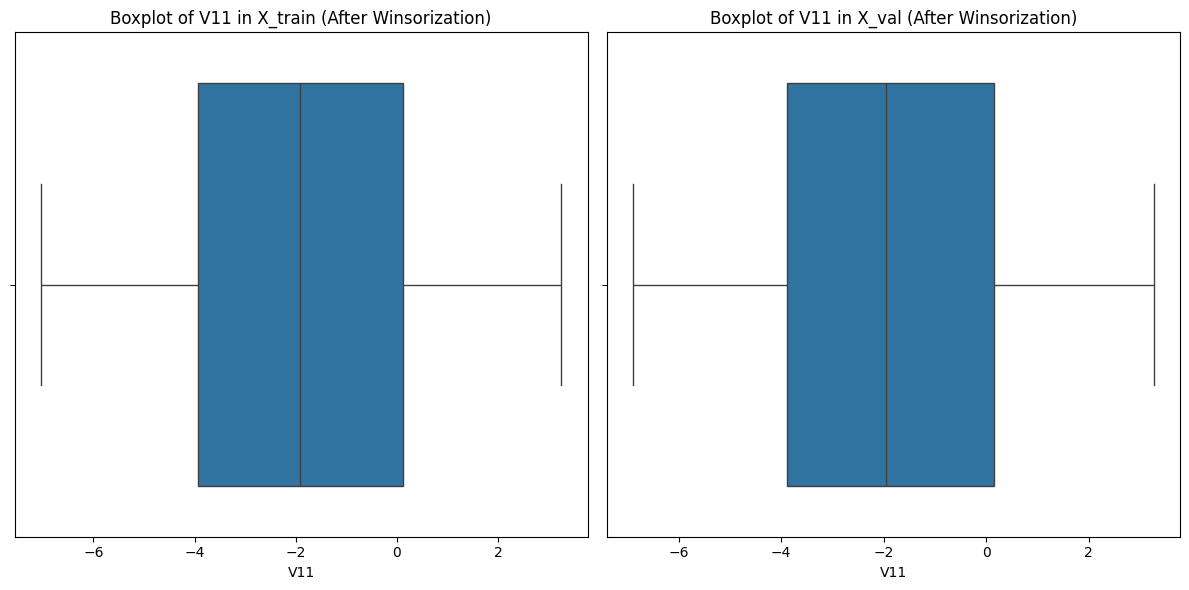

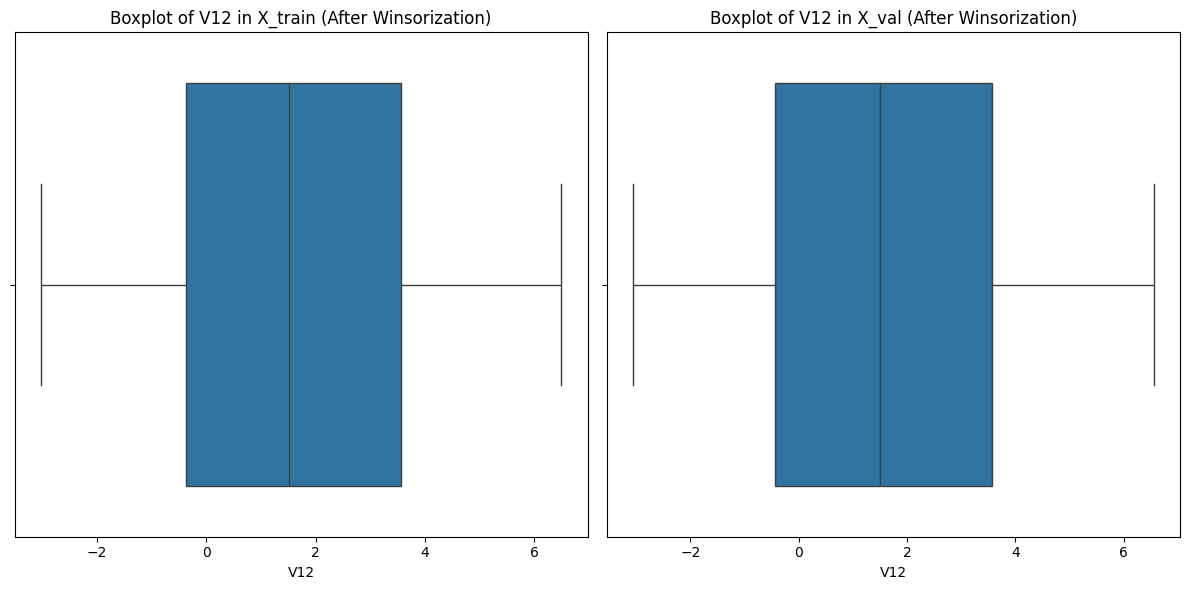

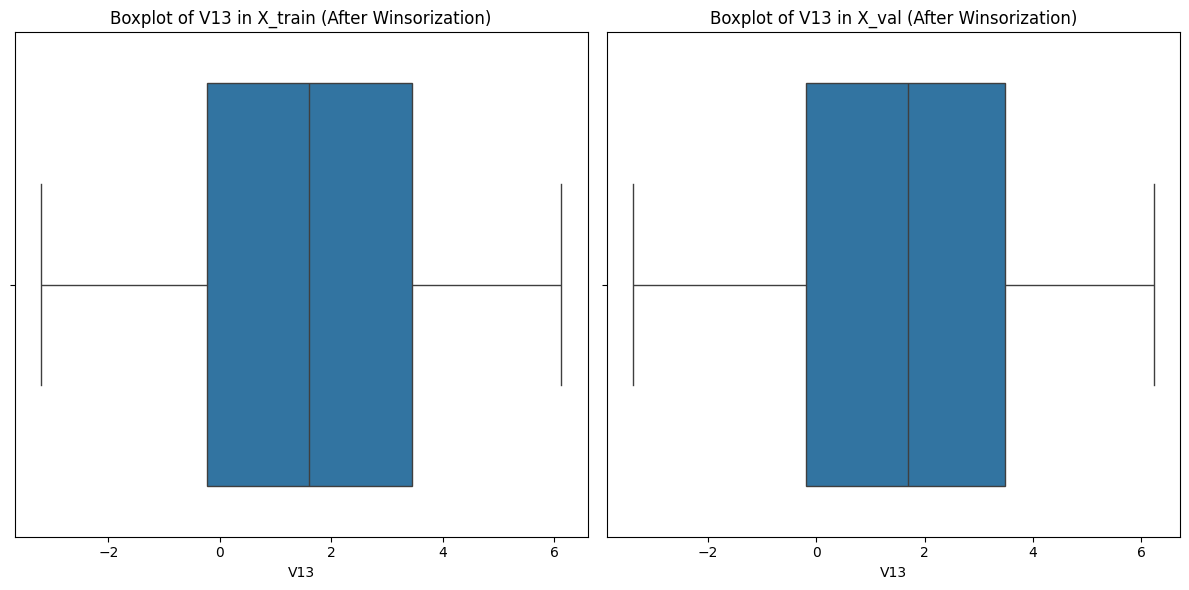

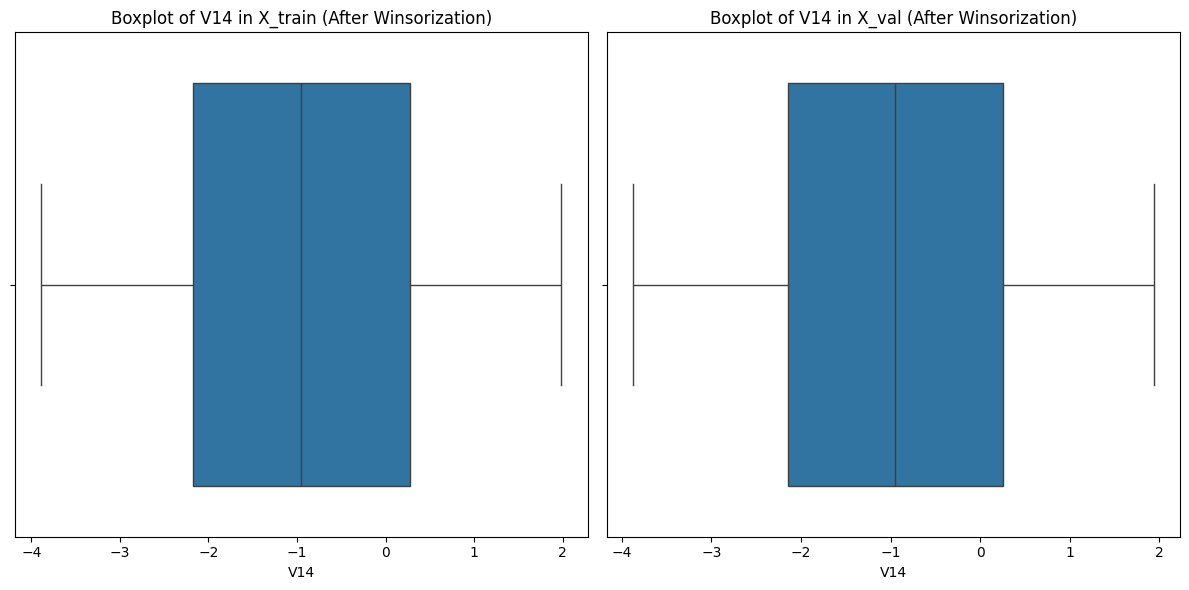

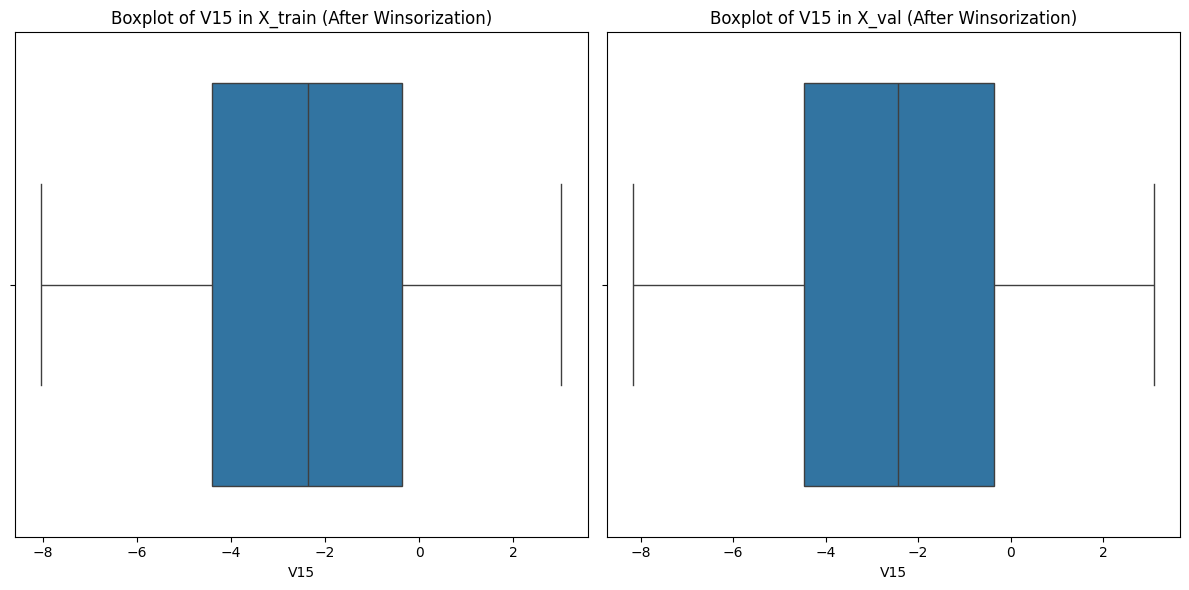

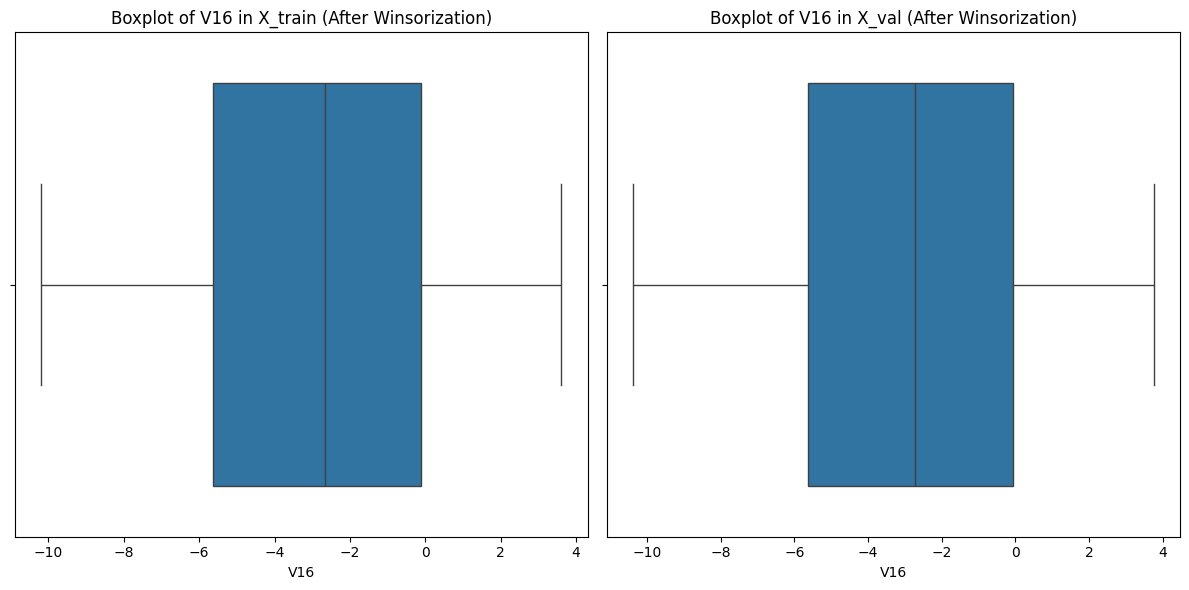

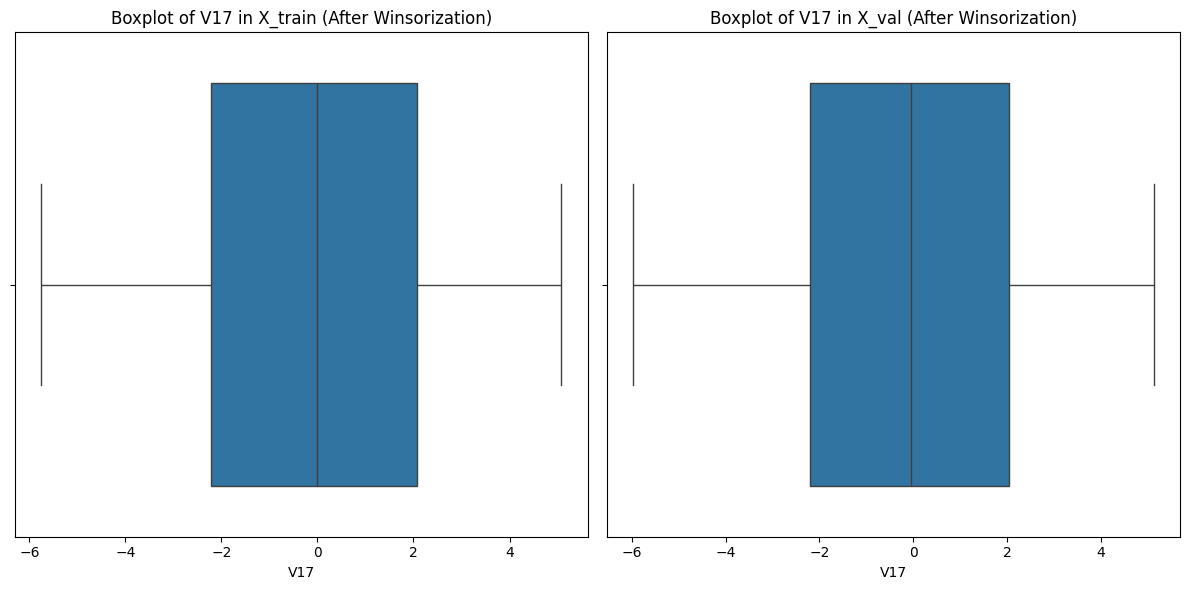

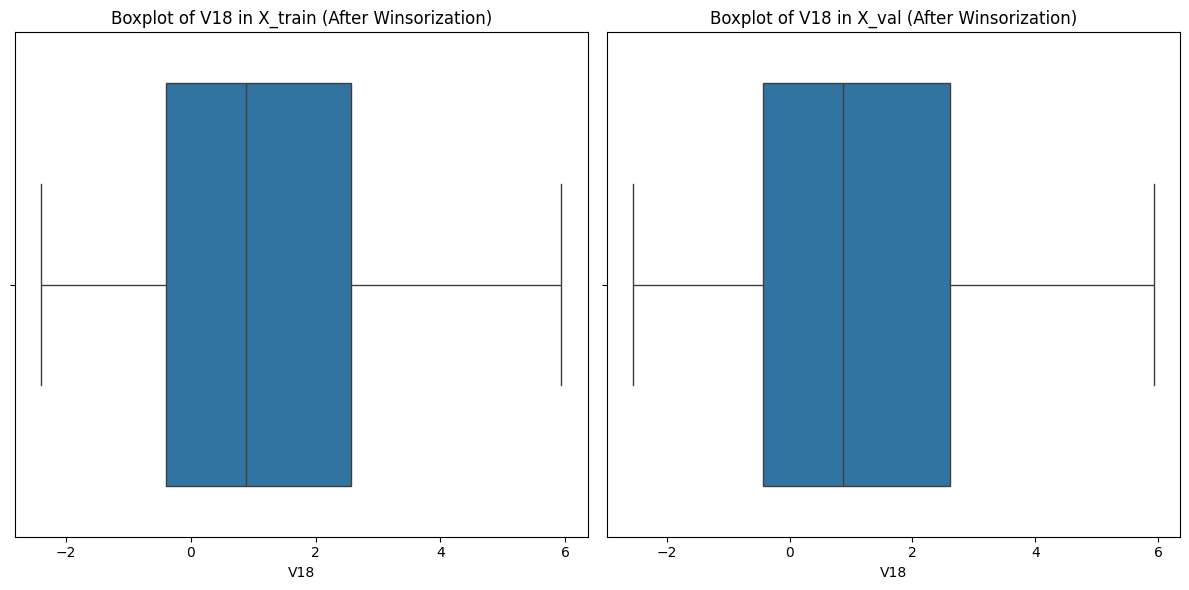

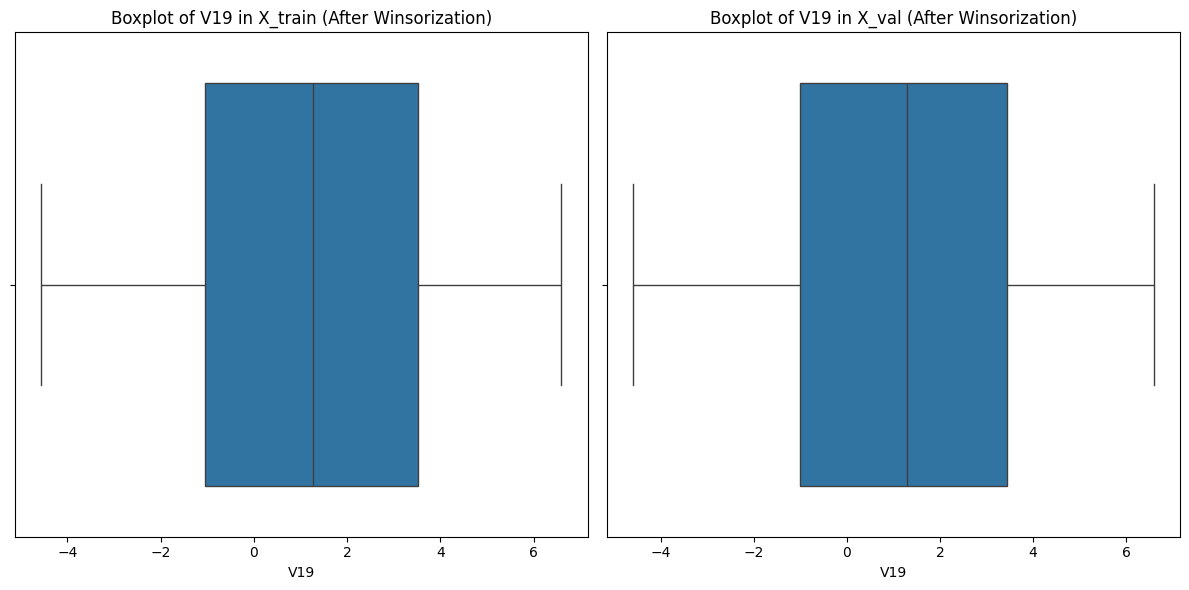

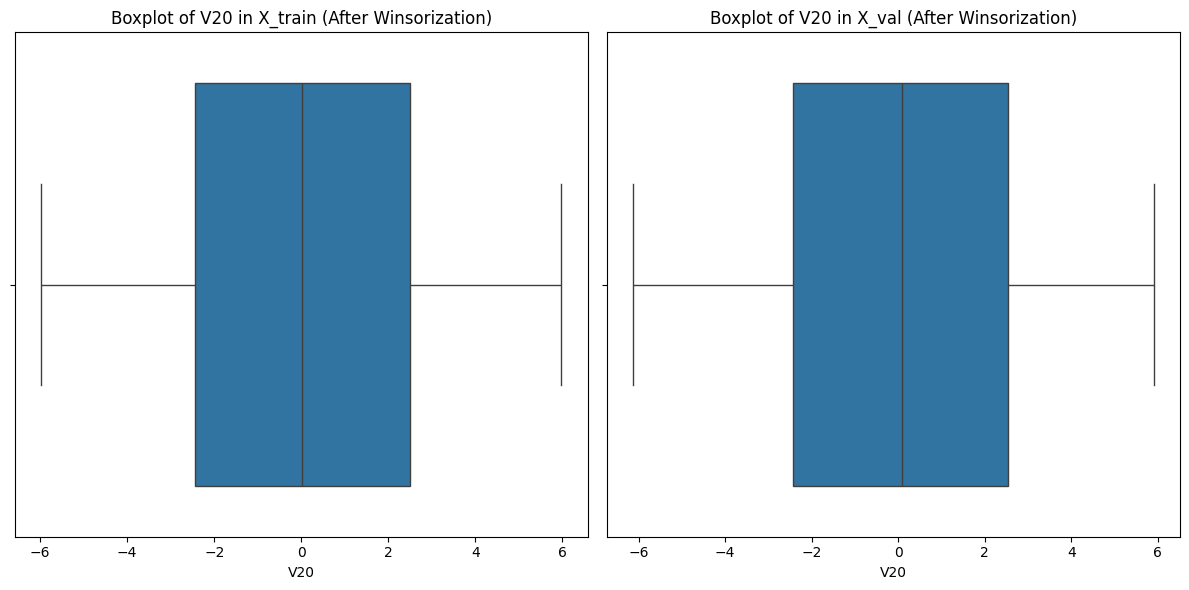

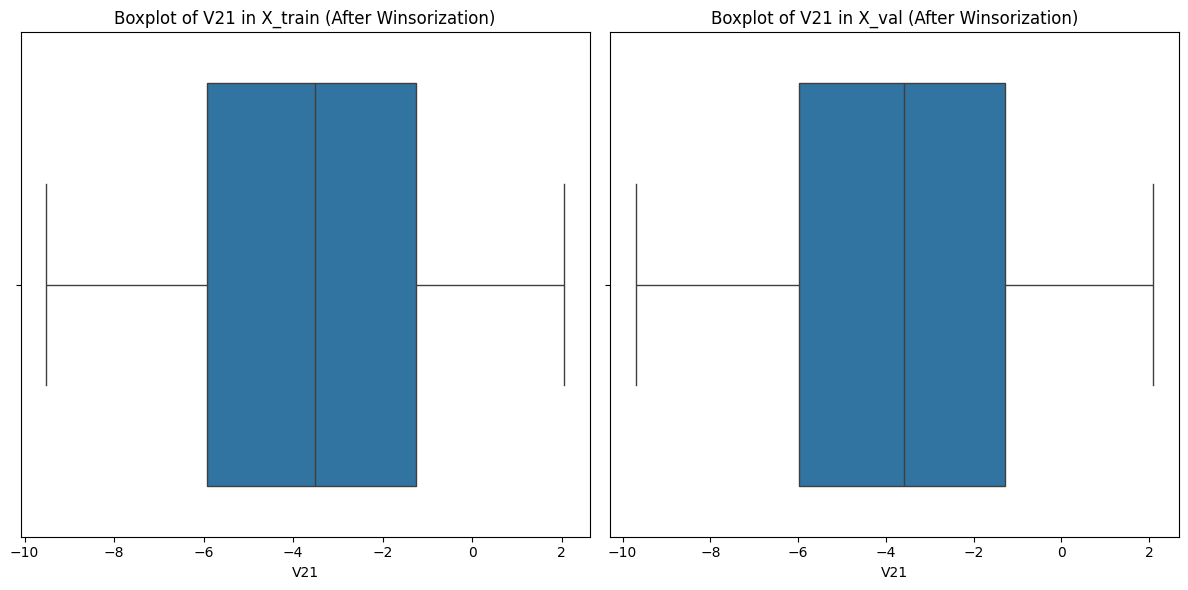

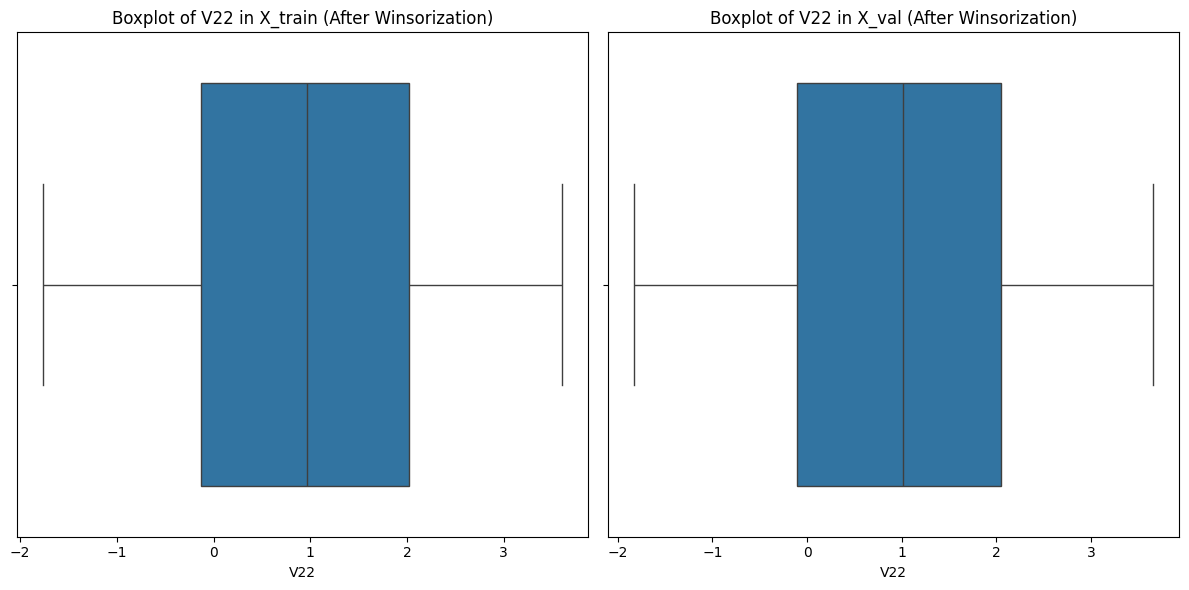

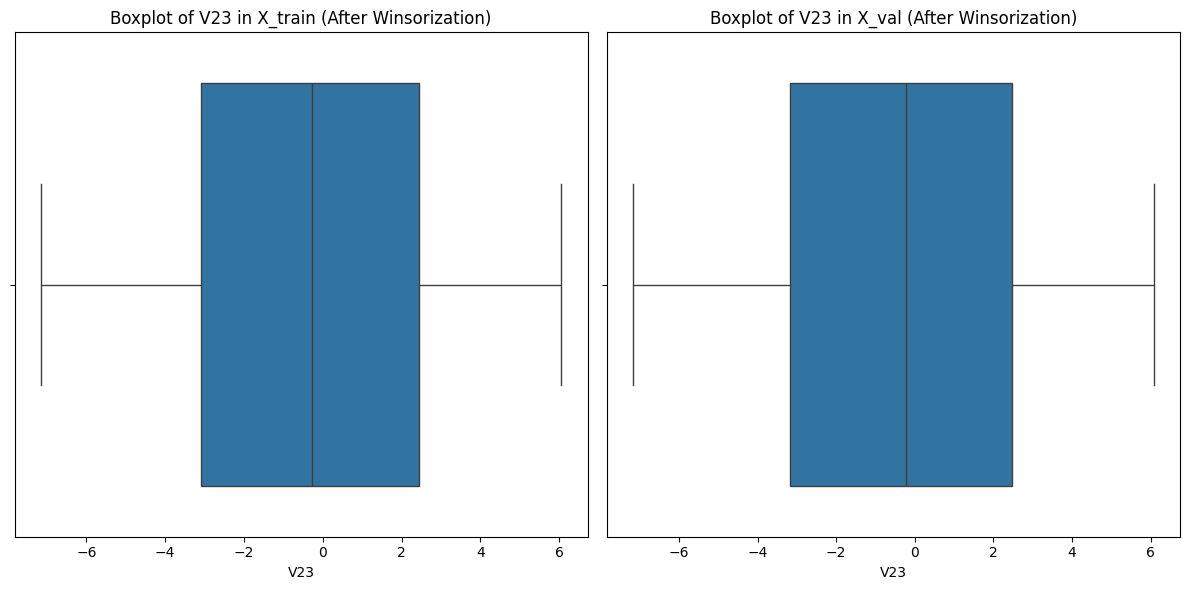

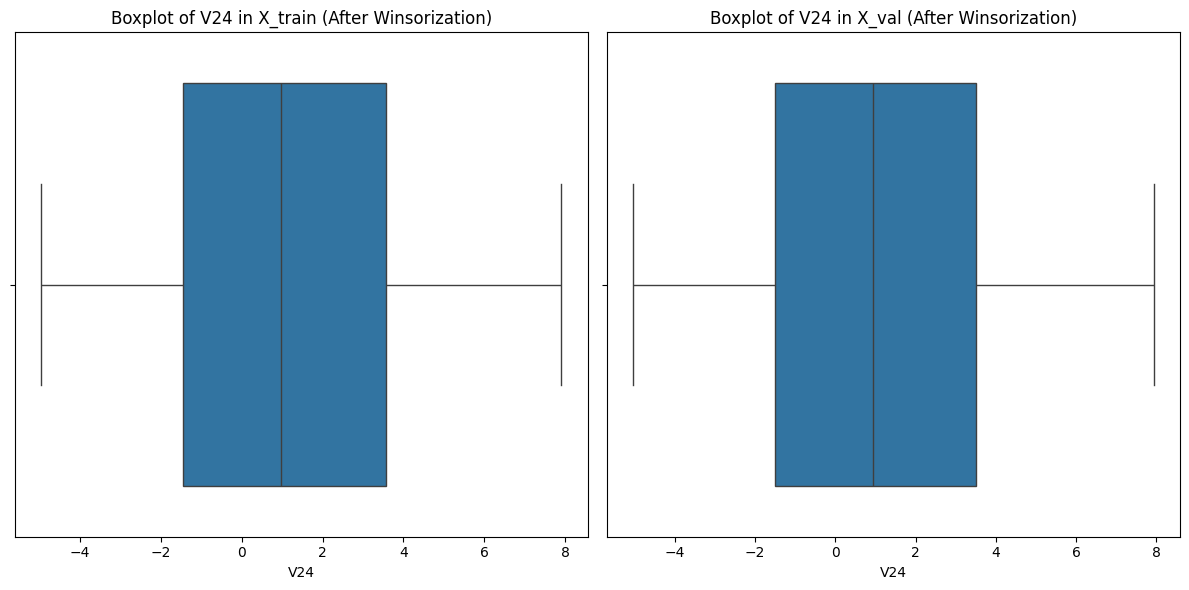

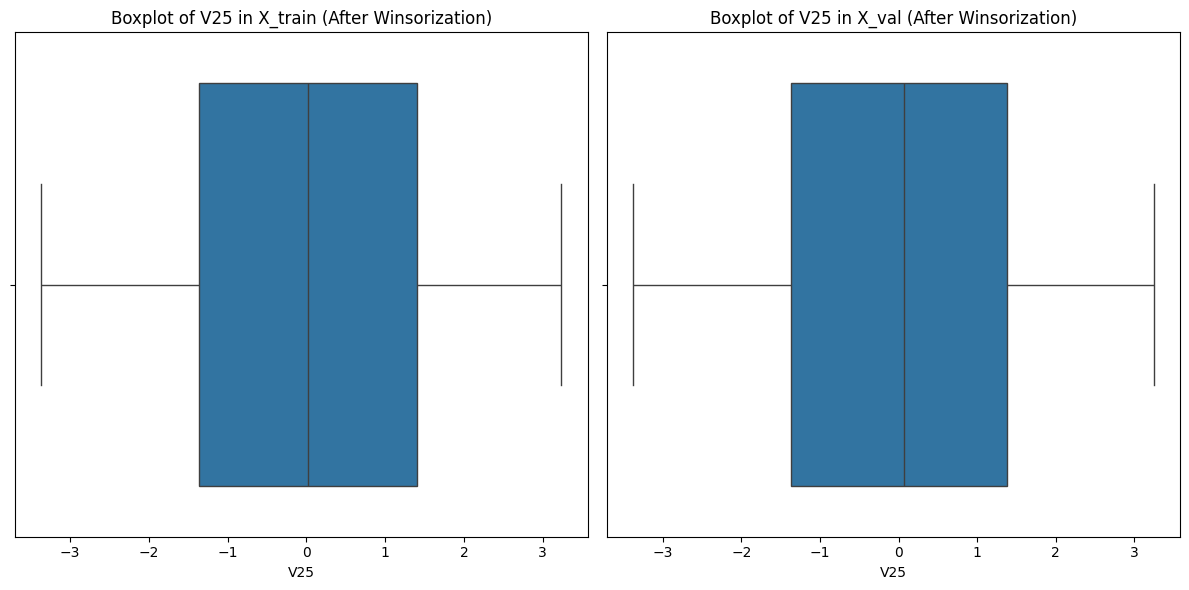

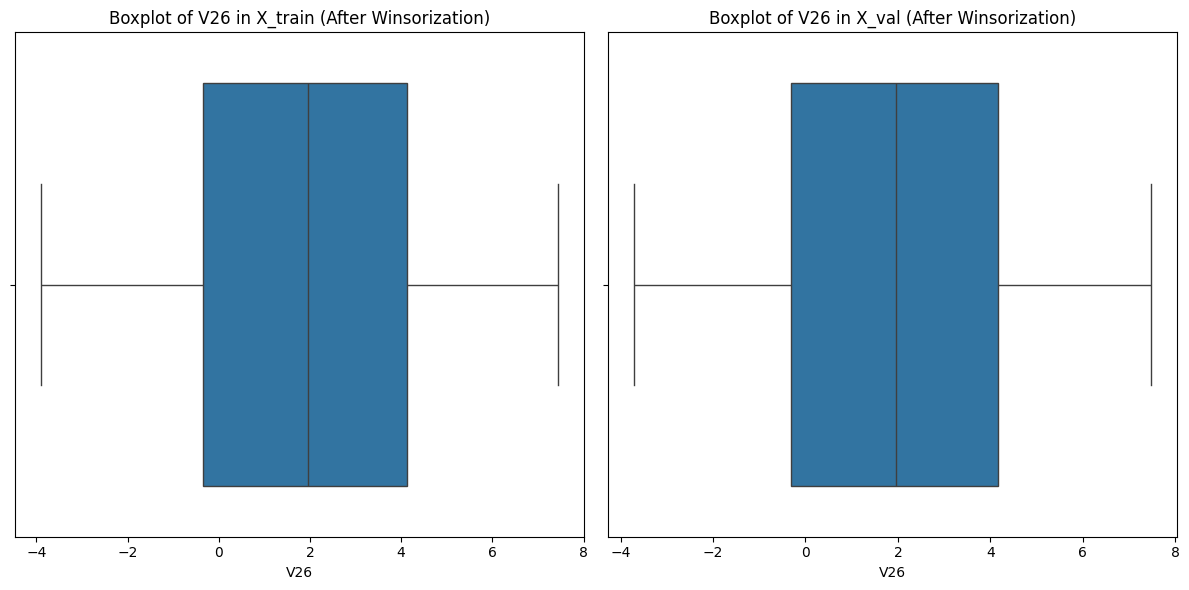

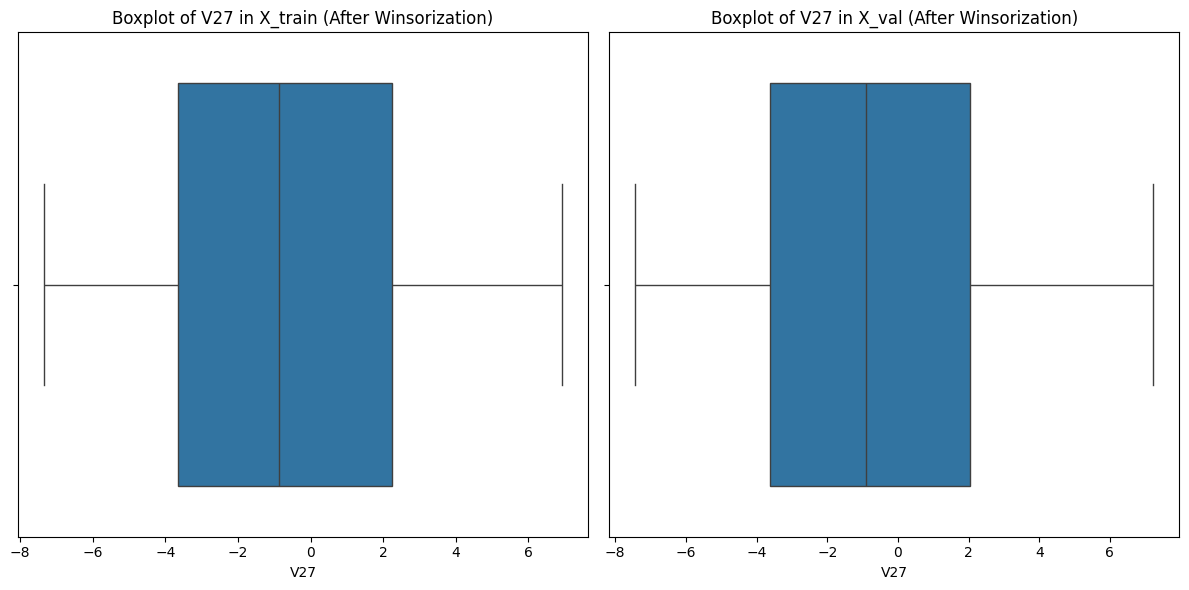

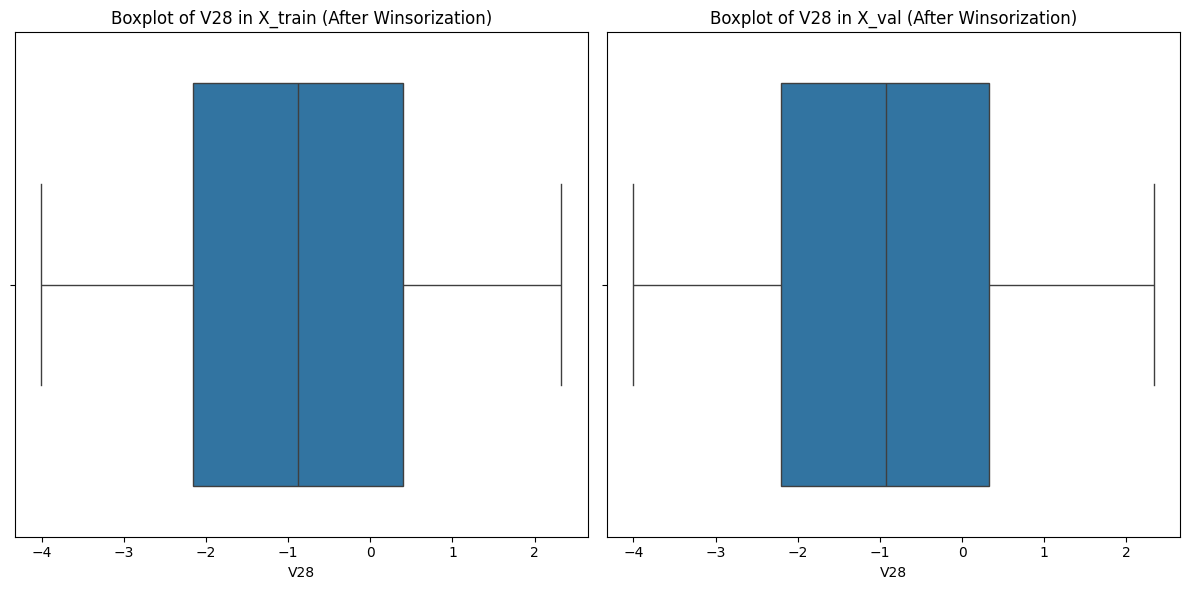

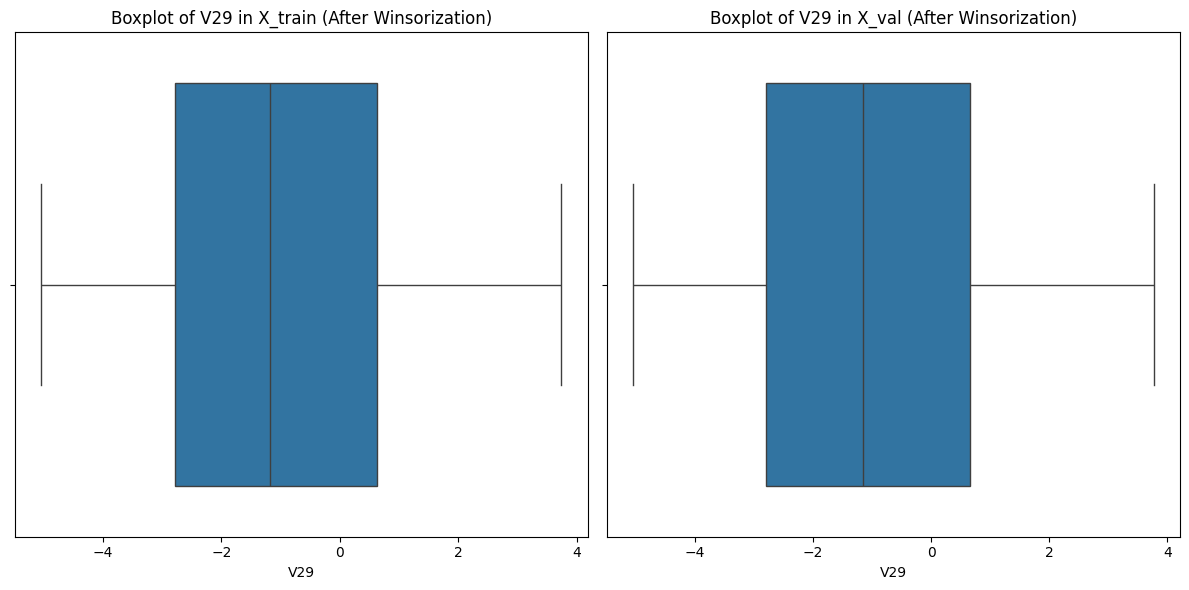

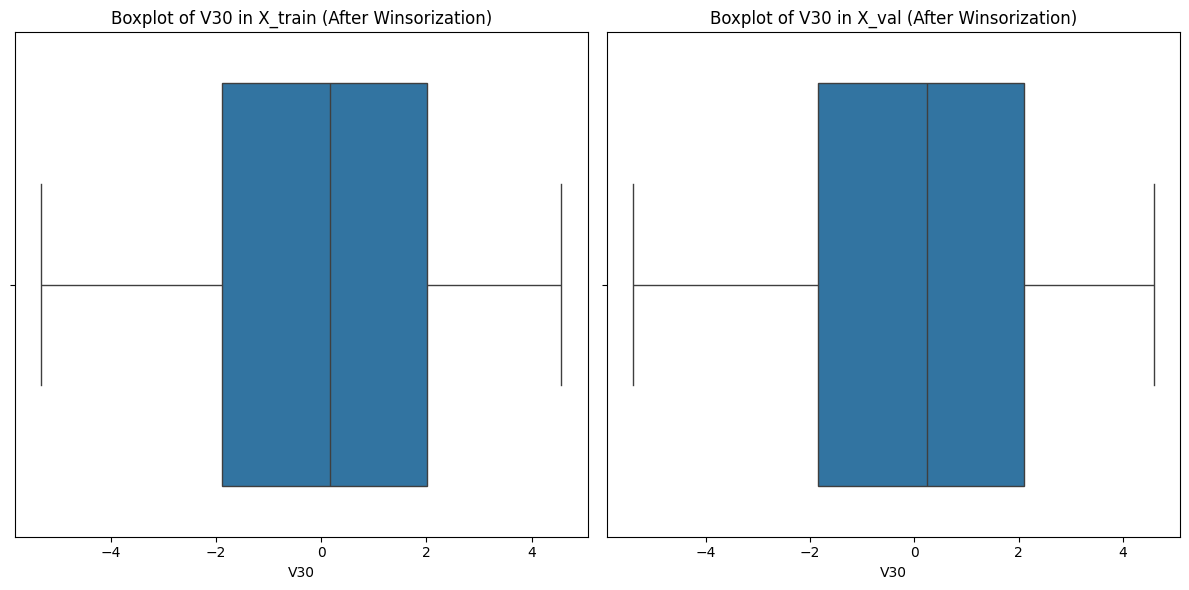

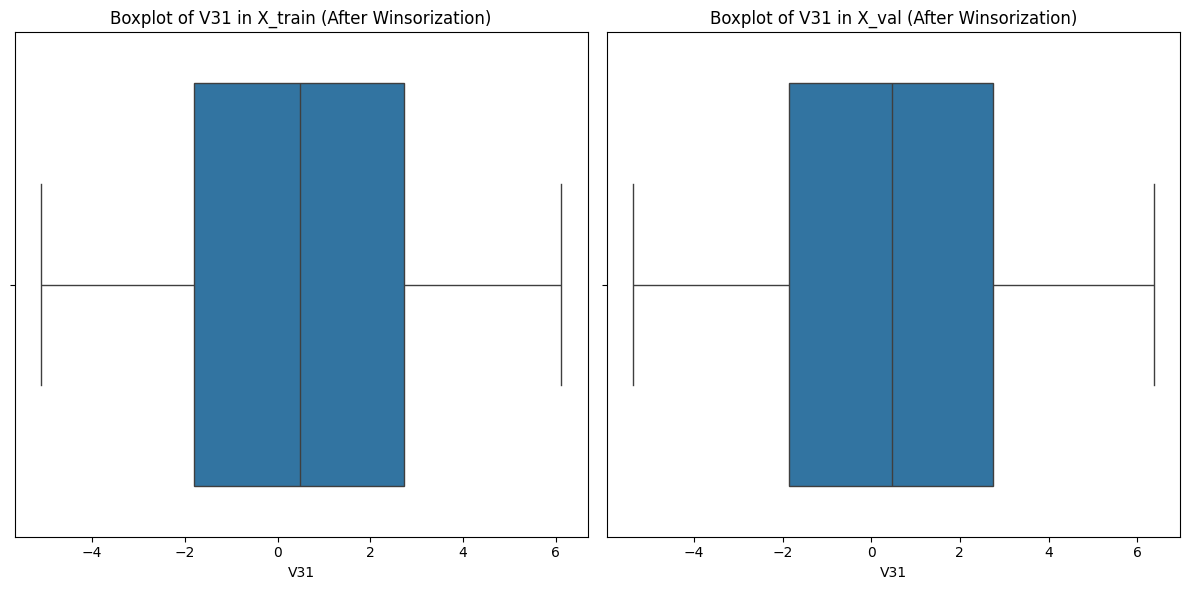

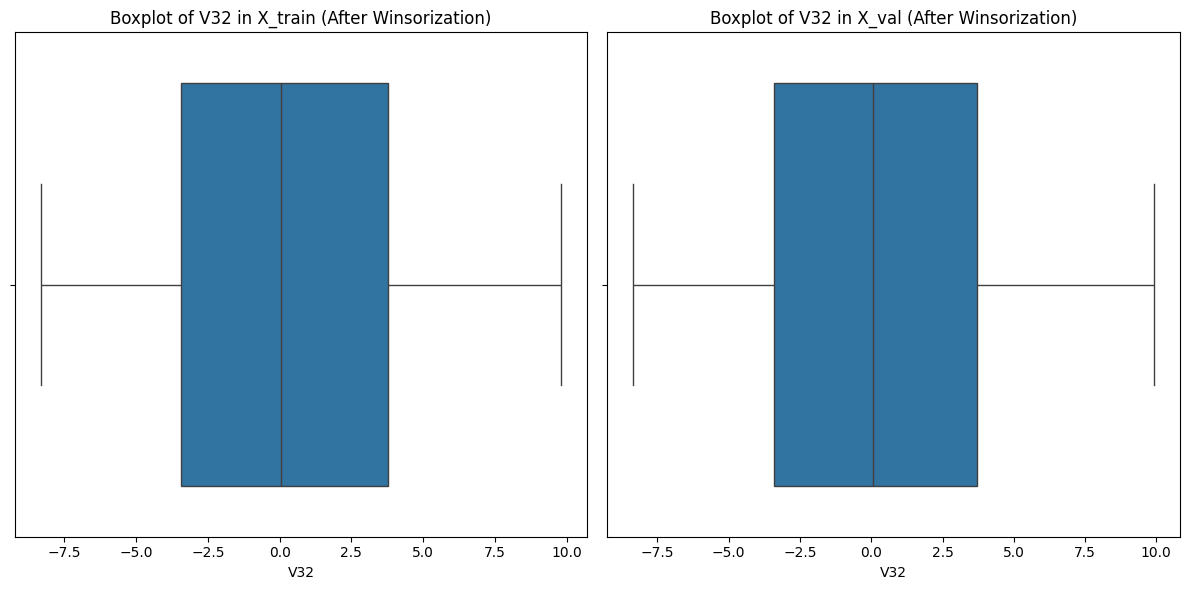

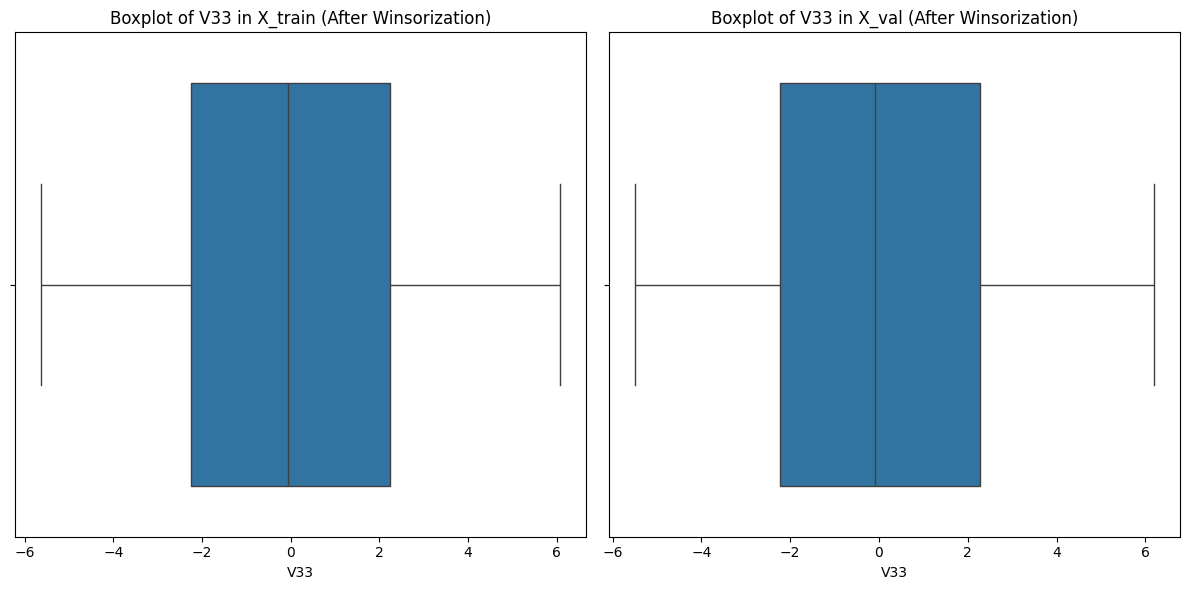

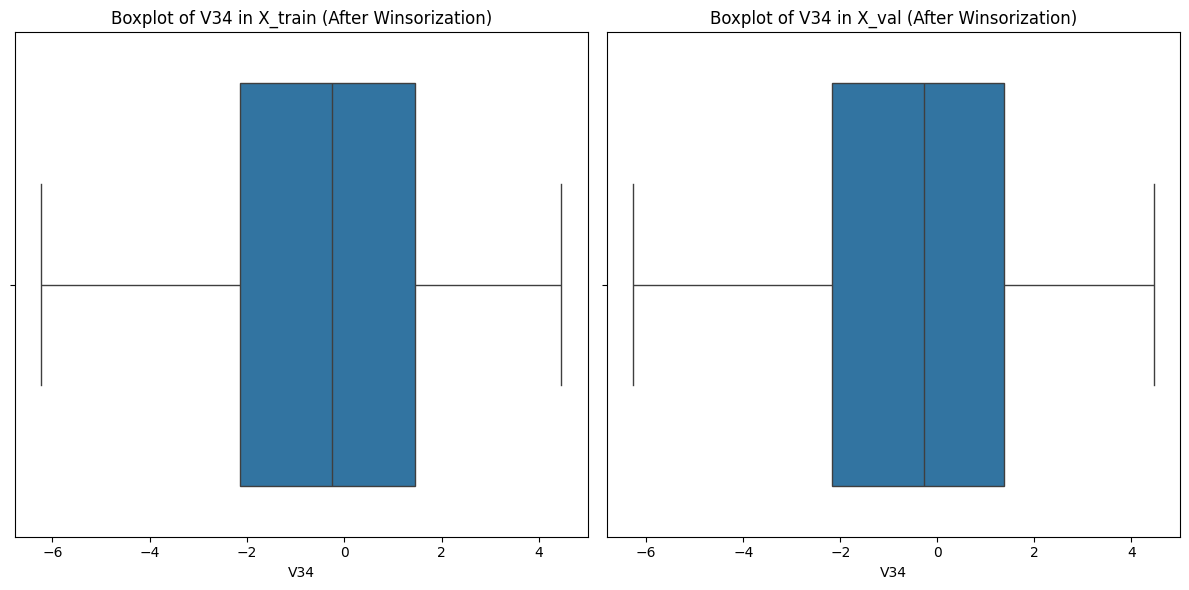

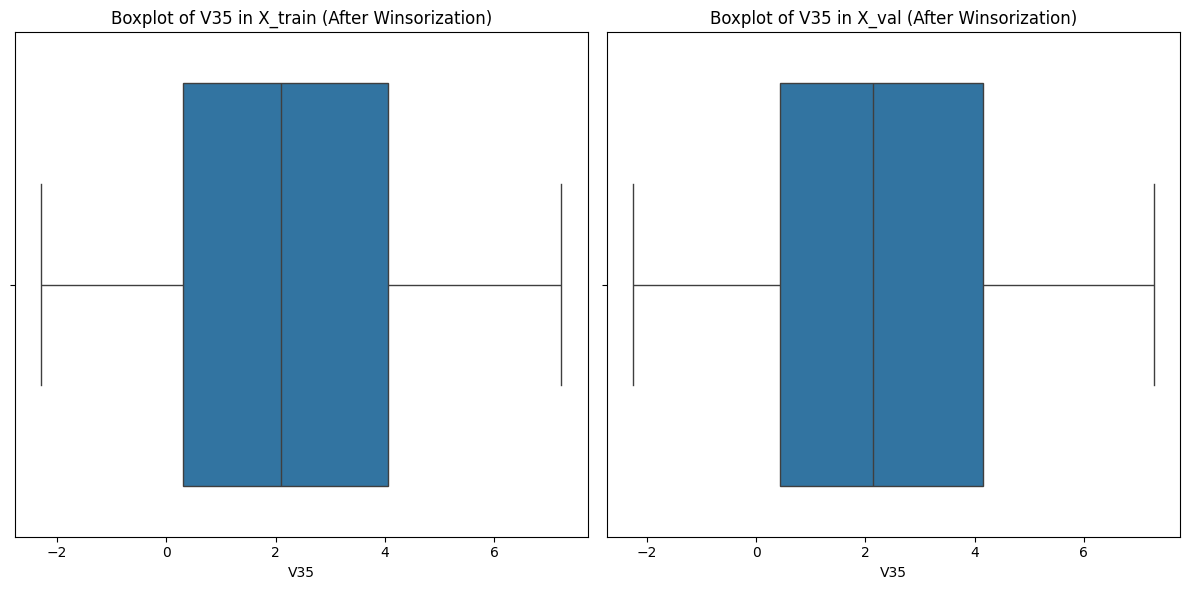

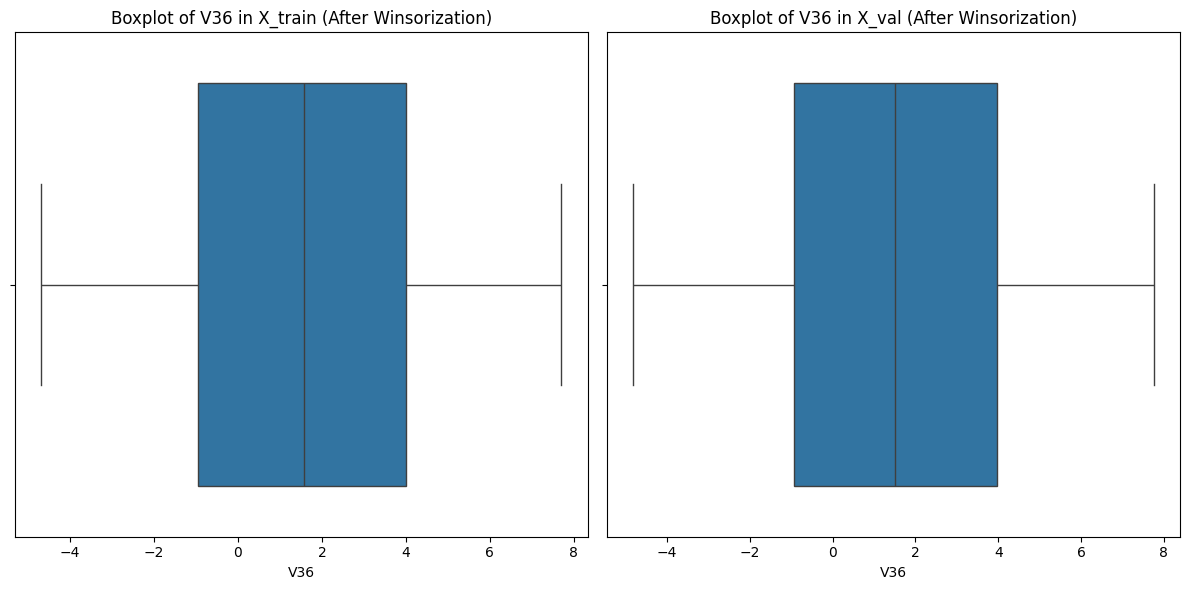

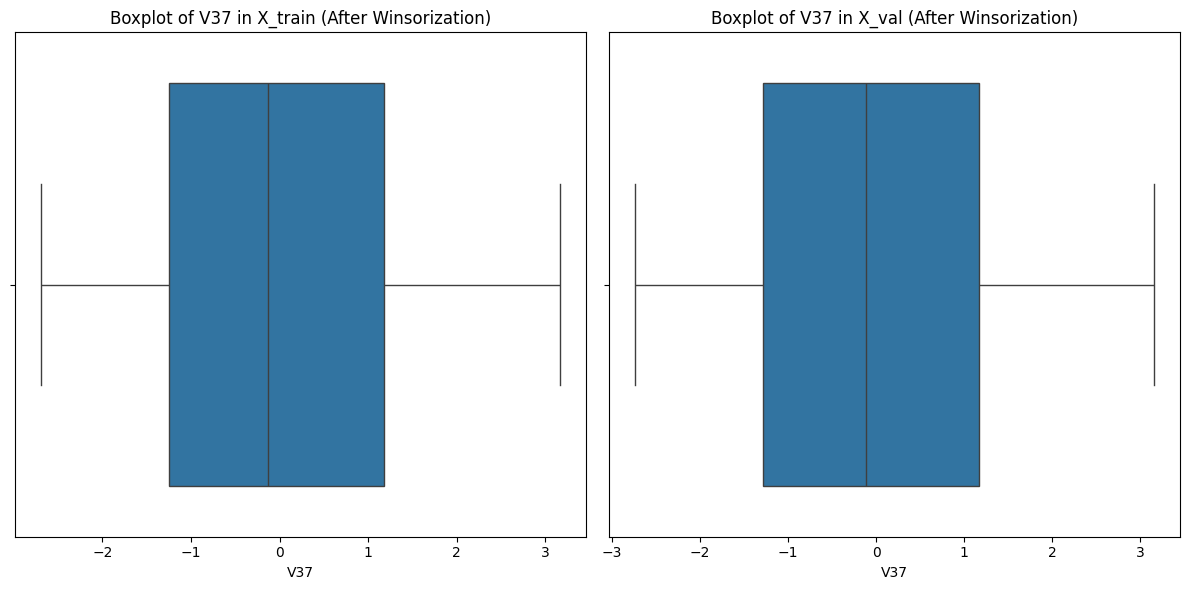

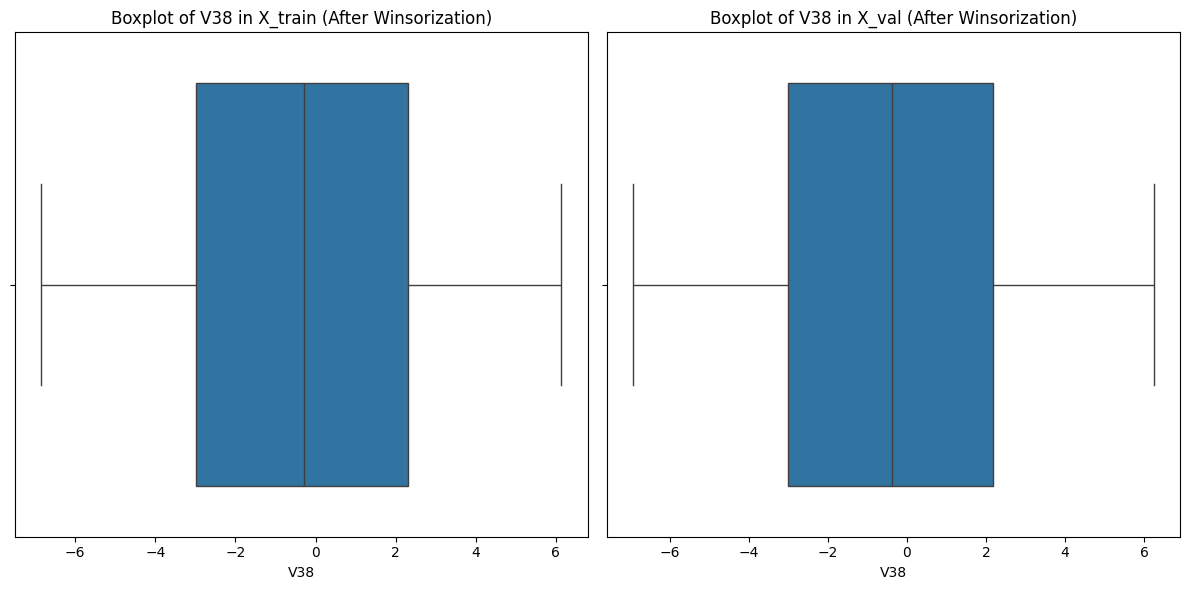

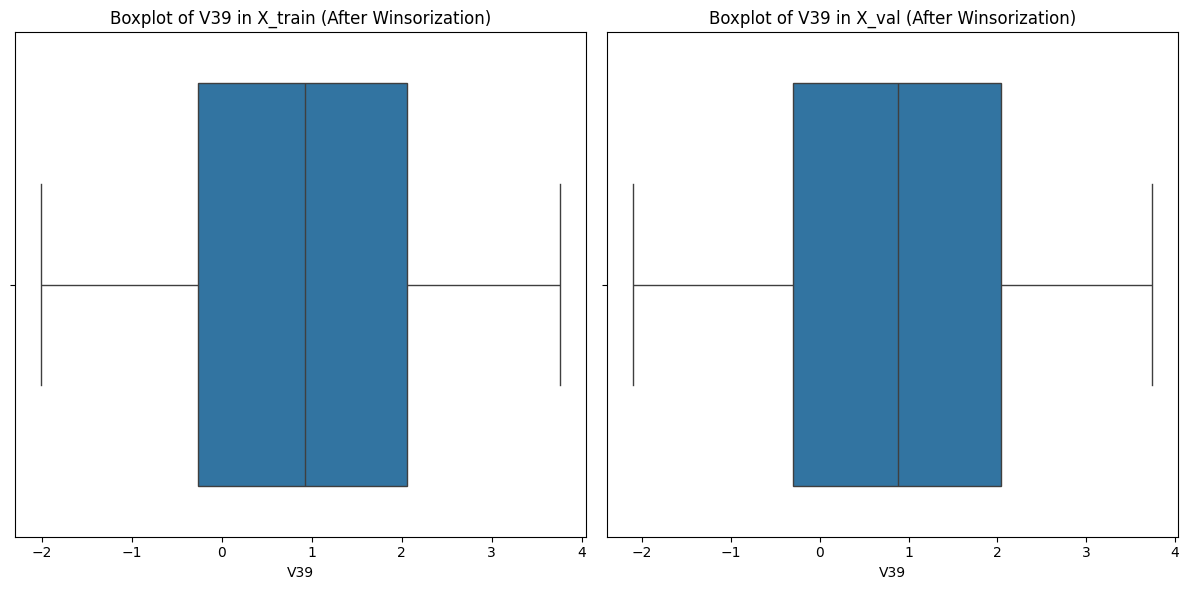

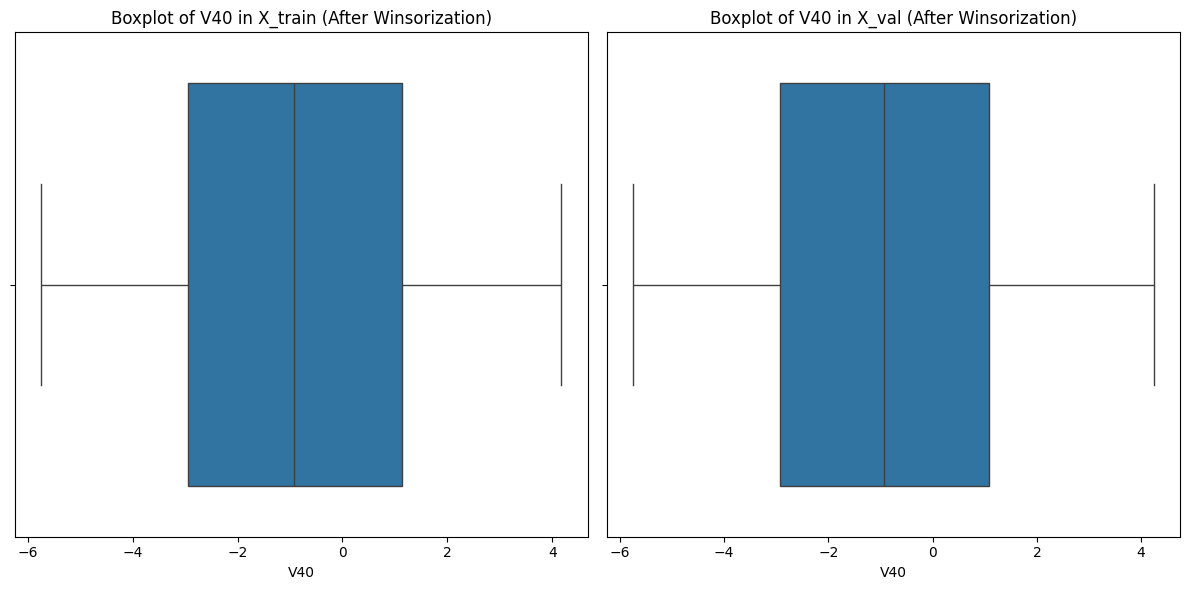

In [ ]:
# Treat outliers in X_train, X_val using Winsorization capping

from scipy.stats.mstats import winsorize

for column in X_train.columns:
  X_train[column] = winsorize(X_train[column], limits=[0.05, 0.05])
  X_val[column] = winsorize(X_val[column], limits=[0.05, 0.05])

# Visualize treated outliers in X_train & X_val using boxplots
for feature in X_train.columns:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(x=X_train[feature])
    plt.title(f"Boxplot of {feature} in X_train (After Winsorization)")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=X_val[feature])
    plt.title(f"Boxplot of {feature} in X_val (After Winsorization)")

    plt.tight_layout()
    plt.show()


Observations:

* As observed, outliers duly treated/capped.

## Feature Scaling (Standardization or Normalization)

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
X_train = scaler.fit_transform(X_train)

# Transform validation and test sets using the same scaler
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check Final Shapes & Data Integrity
print(f"Final Shapes -> X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")



Final Shapes -> X_train: (15000, 40), X_val: (5000, 40), X_test: (5000, 40)


Observations/Insights:

* The data has been standardized

* This dataset has no categorical variables, there is no need to create dummy variables or apply encoding. Will proceed with model training using the numerical features directly.

## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
# Defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, X, y):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables X
    target: dependent variable y
    """

def model_performance_classification_sklearn(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1 Score": f1_score(y, y_pred),
    }

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with full precision percentages.

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    labels = np.array([
        [f"{item}\n{item / cm.sum():.6%}" for item in cm.flatten()]
    ]).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

### Defining scorer to be used for cross-validation and hyperparameter tuning

- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

In [ ]:
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

### Model Building with original data

Sample Decision Tree model building with original data

In [ ]:
# Check class distribution in training and validation sets
class_distribution = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Class 0 Count": [sum(y_train == 0), sum(y_val == 0)],
    "Class 1 Count": [sum(y_train == 1), sum(y_val == 1)],
    "Class 1 Percentage": [sum(y_train == 1) / len(y_train) * 100, sum(y_val == 1) / len(y_val) * 100]
})

# Display class distribution
class_distribution


,Dataset,Class 0 Count,Class 1 Count,Class 1 Percentage
0,Train,14168,832,5.546667
1,Validation,4722,278,5.560000


In [ ]:
# Check shape of X_train and y_train
train_shapes = {
    "Dataset": ["X_train", "y_train"],
    "Shape": [X_train.shape, y_train.shape]
}

# Display dataframe
pd.DataFrame(train_shapes)

,Dataset,Shape
0,X_train,"(15000, 40)"
1,y_train,"(15000,)"


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("logreg", LogisticRegression(random_state=1)))
models.append(("adaboost", AdaBoostClassifier(random_state=1)))
models.append(("bagging", BaggingClassifier(random_state=1)))
models.append(("rf", RandomForestClassifier(random_state=1)))
models.append(("xgb", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("gb", GradientBoostingClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=3, shuffle=True, random_state=1
    )  # Setting number of splits equal to 3 for faster execution
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Training Performance on Original Data:" "\n")

 # build models on original data
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train)) * 100
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance on Original Data:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val)) * 100
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

dtree: 70.07029755257167
logreg: 58.050454942904885
adaboost: 59.73863508471201
bagging: 67.78822429421085
rf: 69.5902483789142
xgb: 79.08474664311872
gb: 71.63381208390688

Training Performance on Original Data:

dtree: 100.0
logreg: 60.21634615384615
adaboost: 59.97596153846154
bagging: 96.03365384615384
rf: 100.0
xgb: 100.0
gb: 83.17307692307693

Validation Performance on Original Data:

dtree: 69.42446043165468
logreg: 58.992805755395686
adaboost: 61.51079136690647
bagging: 74.10071942446042
rf: 74.10071942446042
xgb: 82.37410071942446
gb: 75.89928057553958


Observations/Insights:

* Decision Tree, Random Forest, and XGBoost show 100% training accuracy, which indicates they are overfitting.
* This is confirmed by a performance drop in validation (Decision Tree drops from 100% to 69.42%).
* XGBoost (82.37%) has the best validation performance, meaning it generalizes well despite overfitting.
* Bagging and Random Forest (74.10%) also perform well, but not as good as XGBoost.
* Logistic Regression (58.99%) is the weakest, likely because the data has non-linear relationships that tree-based models handle better.

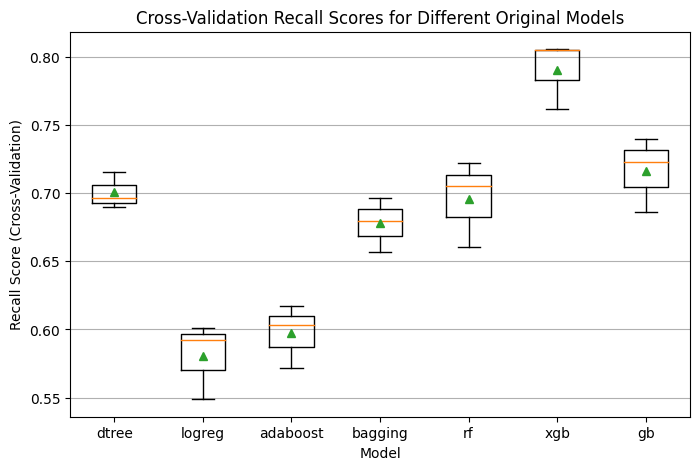

In [ ]:
# Collect cross-validation scores
results = []
names = []

for name, model in models:
    cv_result = cross_val_score(model, X_train, y_train, scoring="recall", cv=kfold)
    results.append(cv_result)
    names.append(name)

# Plot boxplot for cross-validation scores
plt.figure(figsize=(8, 5))
plt.boxplot(results, labels=names, showmeans=True)
plt.xlabel("Model")
plt.ylabel("Recall Score (Cross-Validation)")
plt.title("Cross-Validation Recall Scores for Different Original Models")
plt.grid(axis="y")

# Show the boxplot
plt.show()

Observations/Insights:

* The boxplot suggests that XGBoost is consistent and robust, with less variation compared to some models.uitable due to low recall.
* gb median recall score is slightly lower than XGBoost (~0.73–0.75).
* Random Forest has a median recall around 0.70–0.72, with moderate variance.
* Bagging has a slightly lower recall than Random Forest, but still better than AdaBoost and Logistic Regression.
* Logistic Regression and AdaBoost perform the worst, making them less suitable for this task.
* Decision Tree is okay but benefits from ensemble methods like Bagging and Boosting.

### Model Building with Oversampled data


In [ ]:
# Apply SMOTE to balance the dataset
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_os, y_train_os = sm.fit_resample(X_train, y_train)

# Check class distribution after oversampling
class_distribution_os = pd.DataFrame({
    "Dataset": ["Train (Oversampled)", "Validation"],
    "Class 0 Count": [sum(y_train_os == 0), sum(y_val == 0)],
    "Class 1 Count": [sum(y_train_os == 1), sum(y_val == 1)],
    "Class 1 Percentage": [sum(y_train_os == 1) / len(y_train_os) * 100, sum(y_val == 1) / len(y_val) * 100]
})

# Display class distribution
class_distribution_os

,Dataset,Class 0 Count,Class 1 Count,Class 1 Percentage
0,Train (Oversampled),14168,14168,50.00
1,Validation,4722,278,5.56


In [ ]:
# Check shape of X_train_os and y_train_os
train_os_shapes = {
    "Dataset": ["X_train_os", "y_train_os"],
    "Shape": [X_train_os.shape, y_train_os.shape]
}

# Display dataframe
pd.DataFrame(train_os_shapes)

,Dataset,Shape
0,X_train_os,"(28336, 40)"
1,y_train_os,"(28336,)"


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("logreg", LogisticRegression(random_state=1)))
models.append(("adaboost", AdaBoostClassifier(random_state=1)))
models.append(("bagging", BaggingClassifier(random_state=1)))
models.append(("rf", RandomForestClassifier(random_state=1)))
models.append(("xgb", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("gb", GradientBoostingClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on Oversampled training dataset:" "\n")


for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=3, shuffle=True, random_state=1
    )  # Setting number of splits equal to 3
    cv_result = cross_val_score(
        estimator=model, X=X_train_os, y=y_train_os, scoring=scorer, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Training Performance on Oversampled Training Dataset:" "\n")

for name, model in models:
    model.fit(X_train_os, y_train_os)
    scores = recall_score(y_train_os, model.predict(X_train_os)) * 100
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance on Oversampled Training Dataset:" "\n")

for name, model in models:
    model.fit(X_train_os, y_train_os)
    scores = recall_score(y_val, model.predict(X_val)) * 100
    print("{}: {}".format(name, scores))


Cross-Validation performance on Oversampled training dataset:

dtree: 96.81677962063144
logreg: 89.25044380910549
adaboost: 89.99858428280697
bagging: 97.45907161893868
rf: 98.16488406169981
xgb: 98.99774785580573
gb: 92.24306100536427

Training Performance on Oversampled Training Dataset:

dtree: 100.0
logreg: 89.34923771880293
adaboost: 90.56324110671937
bagging: 99.87295313382269
rf: 100.0
xgb: 99.99294184076793
gb: 92.68068887634105

Validation Performance on Oversampled Training Dataset:

dtree: 80.93525179856115
logreg: 85.25179856115108
adaboost: 87.41007194244604
bagging: 82.73381294964028
rf: 83.81294964028777
xgb: 87.76978417266187
gb: 88.48920863309353


Observations/Insights:

Cross-Validation Performance on Oversampled Training Data:

* All models perform significantly better compared to the original dataset.
* XGBoost has the highest cross-validation performance (~99%).
* Random Forest, Bagging, and Decision Tree also show strong results.
* Logistic Regression improved, but it remains the lowest among the models.

Training Performance on Oversampled Data
* Major Overfitting: Decision Tree, Random Forest, and XGBoost all have 100% training accuracy, which suggests that they are memorizing the data rather than generalizing well.
* Bagging also overfits but slightly less than DT, RF, and XGB.
* Logistic Regression, AdaBoost, and Gradient Boosting are more balanced and may generalize better.

Validation Performance (Generalization Test):
* Gradient Boosting (88.49%) is the best model in validation, closely followed by XGBoost (87.77%) and AdaBoost (87.41%)

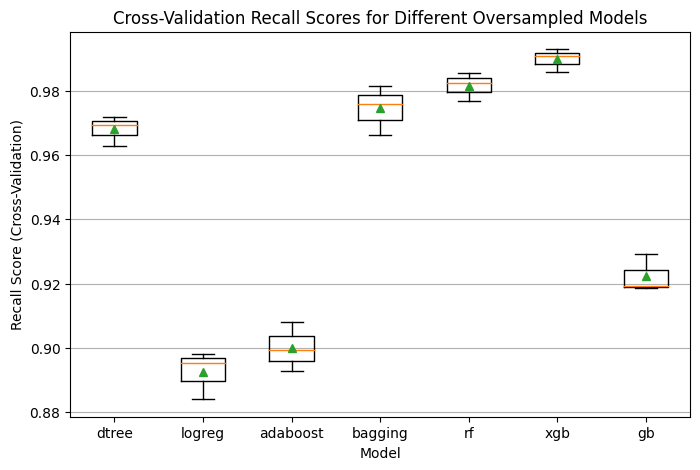

In [ ]:
# Collect cross-validation scores
results = []
names = []

for name, model in models:
    cv_result = cross_val_score(model, X_train_os, y_train_os, scoring="recall", cv=kfold)
    results.append(cv_result)
    names.append(name)

# Plot boxplot for cross-validation scores
plt.figure(figsize=(8, 5))
plt.boxplot(results, labels=names, showmeans=True)
plt.xlabel("Model")
plt.ylabel("Recall Score (Cross-Validation)")
plt.title("Cross-Validation Recall Scores for Different Oversampled Models")
plt.grid(axis="y")

# Show the boxplot
plt.show()

Observations/Insights:
* XGBoost (0.98 recall) is the best model, followed closely by Random Forest and Bagging.
* Gradient Boosting performs well but has more variation, indicating sensitivity to hyperparameters.
* Decision Tree is strong but benefits from ensemble methods.
* Logistic Regression and AdaBoost struggle the most, making them less ideal for recall-focused tasks.

### Model Building with Undersampled data

In [ ]:
# Apply random undersampling
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)  # Equalize both classes
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

# Check class distribution in training and validation sets
class_distribution = pd.DataFrame({
    "Dataset": ["Train (Undersampled)", "Validation"],
    "Class 0 Count": [sum(y_train_un == 0), sum(y_val == 0)],
    "Class 1 Count": [sum(y_train_un == 1), sum(y_val == 1)],
    "Class 1 Percentage": [sum(y_train_un == 1) / len(y_train_un) * 100, sum(y_val == 1) / len(y_val) * 100]
})

# Display class distribution dataframe
class_distribution

,Dataset,Class 0 Count,Class 1 Count,Class 1 Percentage
0,Train (Undersampled),832,832,50.00
1,Validation,4722,278,5.56


In [ ]:
# Check shape of X_train_un and y_train_un
train_shapes = {
    "X_train_un Shape": X_train_un.shape[0],  # Use only the first element of the shape (number of rows)
    "y_train_un Shape": y_train_un.shape[0]   # Use only the first element of the shape (number of rows)
}

# Display dataframe
pd.DataFrame(train_shapes, index=[0]) # Create a single-row DataFrame

,X_train_un Shape,y_train_un Shape
0,1664,1664


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("logreg", LogisticRegression(random_state=1)))
models.append(("adaboost", AdaBoostClassifier(random_state=1)))
models.append(("bagging", BaggingClassifier(random_state=1)))
models.append(("rf", RandomForestClassifier(random_state=1)))
models.append(("xgb", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("gb", GradientBoostingClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance on Undersampled Dataset:" "\n")

for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=3, shuffle=True, random_state=1
    )  # Setting number of splits equal to 3
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Training Performance on Undersampled Dataset:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un)) * 100
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance on Undersampled Dataset:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val)) * 100
    print("{}: {}".format(name, scores))


Cross-Validation Performance on Undersampled Dataset:

dtree: 85.69418833164515
logreg: 87.37890553982807
adaboost: 88.09876286696276
bagging: 86.53871126925173
rf: 89.54237332155937
xgb: 90.26352924880312
gb: 89.66271026500098

Training Performance on Undersampled Dataset:

dtree: 100.0
logreg: 87.86057692307693
adaboost: 90.38461538461539
bagging: 98.5576923076923
rf: 100.0
xgb: 100.0
gb: 94.59134615384616

Validation Performance on Undersampled Dataset:

dtree: 87.05035971223022
logreg: 86.6906474820144
adaboost: 86.33093525179856
bagging: 86.33093525179856
rf: 89.20863309352518
xgb: 89.92805755395683
gb: 89.20863309352518


Observations/Insights:

*  XGBoost (89.93%) is the best-performing model, showing the strongest generalization.
* Random Forest and Gradient Boosting are strong alternatives, performing slightly lower but still effective.
* AdaBoost and Logistic Regression show stable performance but are weaker than boosting models.
* Decision Tree struggles the most in generalization, despite performing well on training.
* Undersampling has improved Logistic Regression's competitiveness, making it more effective compared to oversampling.

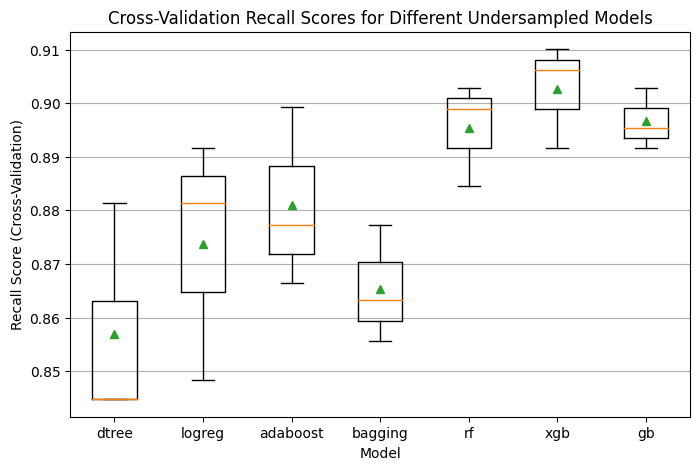

In [ ]:
# Collect cross-validation scores
results = []
names = []

for name, model in models:
    cv_result = cross_val_score(model, X_train_un, y_train_un, scoring="recall", cv=kfold)
    results.append(cv_result)
    names.append(name)

# Plot boxplot for cross-validation scores
plt.figure(figsize=(8, 5))
plt.boxplot(results, labels=names, showmeans=True)
plt.xlabel("Model")
plt.ylabel("Recall Score (Cross-Validation)")
plt.title("Cross-Validation Recall Scores for Different Undersampled Models")
plt.grid(axis="y")

# Show the boxplot
plt.show()

Observations/Insights:

* XGBoost (0.90–0.91 recall) is the best model, followed closely by Random Forest (~0.90 recall). Both have low variability, meaning stable models
* Gradient Boosting performs well (~0.89) but is slightly less stable than XGBoost and RF.
* AdaBoost and Logistic Regression show decent recall but are outperformed by boosting methods.
* Decision Tree performs the worst, confirming that it benefits significantly from ensemble techniques.

### Model Performance Comparision

In [ ]:
# Create a DataFrame to summarize the model performance from the extracted results

# Model names
models = ["dtree", "logreg", "adaboost", "bagging", "rf", "xgb", "gb"]

# Extracted results for Training & Validation Recall Scores
train_recall_scores = {
    "Original": [100.0, 60.22, 59.98, 96.03, 100.0, 100.0, 83.17],
    "Oversampled": [100.0, 89.35, 90.56, 99.87, 100.0, 99.99, 92.68],
    "Undersampled": [100.0, 87.86, 90.38, 98.56, 100.0, 100.0, 94.59],
}

val_recall_scores = {
    "Original": [69.42, 58.99, 61.51, 74.10, 74.10, 82.37, 75.89],
    "Oversampled": [80.94, 85.25, 87.41, 82.73, 83.81, 87.77, 88.49],
    "Undersampled": [87.05, 86.69, 86.33, 86.33, 89.21, 89.93, 89.21],
}

# Convert to DataFrame
df_model_performance = pd.DataFrame({
    "Model": models,
    "Train Recall (Original)": train_recall_scores["Original"],
    "Val Recall (Original)": val_recall_scores["Original"],
    "Train Recall (Oversampled)": train_recall_scores["Oversampled"],
    "Val Recall (Oversampled)": val_recall_scores["Oversampled"],
    "Train Recall (Undersampled)": train_recall_scores["Undersampled"],
    "Val Recall (Undersampled)": val_recall_scores["Undersampled"],
})

# Sort by highest validation recall (best generalization performance)
df_model_performance["Best Validation Recall"] = df_model_performance[
    ["Val Recall (Original)", "Val Recall (Oversampled)", "Val Recall (Undersampled)"]
].max(axis=1)

df_model_performance_sorted = df_model_performance.sort_values(by="Best Validation Recall", ascending=False)

# Display model performance summary
pd.DataFrame(df_model_performance_sorted)

,Model,Train Recall (Original),Val Recall (Original),Train Recall (Oversampled),Val Recall (Oversampled),Train Recall (Undersampled),Val Recall (Undersampled),Best Validation Recall
5,xgb,100.00,82.37,99.99,87.77,100.00,89.93,89.93
4,rf,100.00,74.10,100.00,83.81,100.00,89.21,89.21
6,gb,83.17,75.89,92.68,88.49,94.59,89.21,89.21
2,adaboost,59.98,61.51,90.56,87.41,90.38,86.33,87.41
0,dtree,100.00,69.42,100.00,80.94,100.00,87.05,87.05
1,logreg,60.22,58.99,89.35,85.25,87.86,86.69,86.69
3,bagging,96.03,74.10,99.87,82.73,98.56,86.33,86.33


Observations/Insight:

Top 4 Models (Based on Best Validation Recall):

1. XGBoost (xgb) - 89.93% Recall
2. Random Forest (rf) - 89.21% Recall
3. Gradient Boosting (gb) - 89.21% Recall
4. Adaboost (adaboost) - 87.41% Recall

* These models demonstrated the best generalization ability, meaning they are most effective in detecting failures while minimizing false negatives.

* *Will fine-tune these models for further improved performance*

## HyperparameterTuning

#### XGBoost (xgb)

#####xgb original tuned

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters are {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 250, 'learning_rate': 0.1, 'gamma': 0} with CV score=0.9896666666666666:
Training Performance:
 {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}

Validation Performance:
 {'Accuracy': 0.99, 'Precision': 0.9672131147540983, 'Recall': 0.8489208633093526, 'F1 Score': 0.9042145593869731}


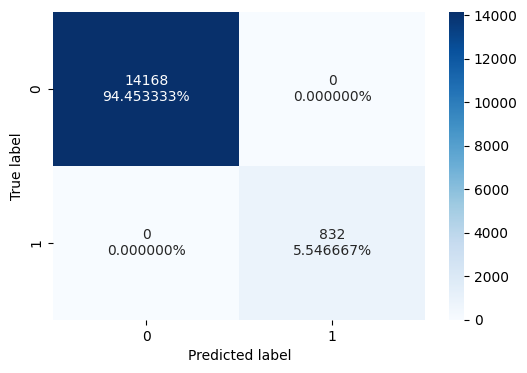

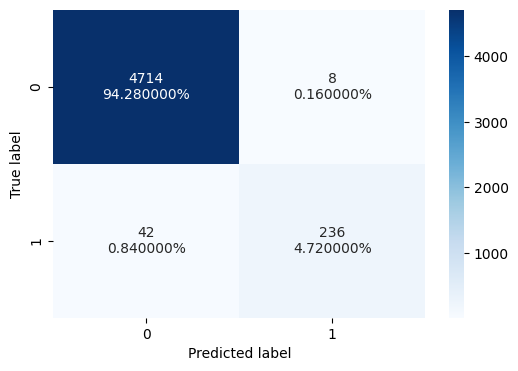

In [ ]:
xgb_tuned = XGBClassifier(eval_metric='logloss')

param_grid={ 'n_estimators': [150, 200, 250],
            'scale_pos_weight': [5,10],
             'learning_rate': [0.1,0.2],
             'gamma': [0,3,5],
             'subsample': [0.8,0.9] }

# Initialize random grid
randomized_cv = RandomizedSearchCV(estimator=xgb_tuned, param_distributions=param_grid,
                                n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1)

# Fit the model
randomized_cv.fit(X_train, y_train)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get best parameters and best model
best_params_xgb_tuned = randomized_cv.best_params_
best_model_xgb_tuned = randomized_cv.best_estimator_

# Fit the best model on the training data
best_model_xgb_tuned.fit(X_train, y_train)

# Training Performance
xgb_random_train_perf = model_performance_classification_sklearn(best_model_xgb_tuned, X_train, y_train)
print("Training Performance:\n", xgb_random_train_perf)

# Validation Performance
xgb_random_val_perf = model_performance_classification_sklearn(best_model_xgb_tuned, X_val, y_val)
print("\nValidation Performance:\n", xgb_random_val_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(best_model_xgb_tuned, X_train, y_train)

# Create confusion matrix Validation
confusion_matrix_sklearn(best_model_xgb_tuned, X_val, y_val)

Observations/Insights:

* The tuned XGBoost model generalizes well with high recall (84.89%) and excellent precision (96.72%).
* Avoids too many false positives, making it reliable for deployment.
* Slight risk of overfitting in training. Consider increasing gamma or reg_lambda to improve generalization.

##### xgb oversampled tuned

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters are {'subsample': 0.9, 'scale_pos_weight': 5, 'n_estimators': 250, 'learning_rate': 0.2, 'gamma': 0} with CV score=0.9928712653848324:
Training Performance:
 {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}

Validation Performance:
 {'Accuracy': 0.9848, 'Precision': 0.8581560283687943, 'Recall': 0.8705035971223022, 'F1 Score': 0.8642857142857142}


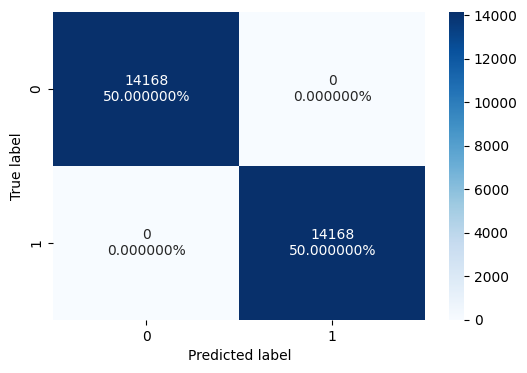

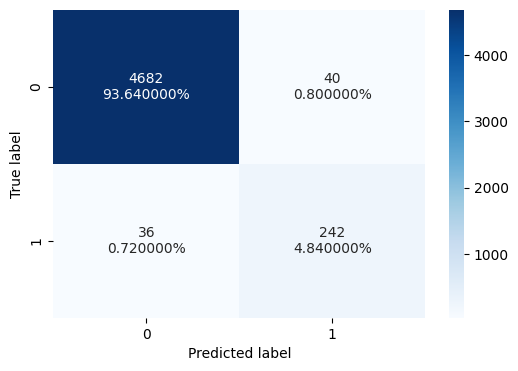

In [ ]:
xgb_tuned_os = XGBClassifier(eval_metric='logloss')

param_grid={'n_estimators': [150, 200, 250],
            'scale_pos_weight': [5,10],
             'learning_rate': [0.1,0.2],
             'gamma': [0,3,5],
             'subsample': [0.8,0.9] }

# Initialize random grid
randomized_cv = RandomizedSearchCV(estimator=xgb_tuned_os, param_distributions=param_grid,
                                n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1)


# Fit the random search model to the oversampled training data
randomized_cv.fit(X_train_os, y_train_os)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get the best parameter and model
best_params_xgb_os_tuned = randomized_cv.best_params_
best_xgb_os_tuned_model = randomized_cv.best_estimator_

# Fit the best model on the training data
best_xgb_os_tuned_model.fit(X_train_os, y_train_os)

# Training Performance
xgb_random_os_train_perf = model_performance_classification_sklearn(best_xgb_os_tuned_model, X_train_os, y_train_os)
print("Training Performance:\n", xgb_random_os_train_perf)

# Validation Performance
xgb_random_os_val_perf = model_performance_classification_sklearn(best_xgb_os_tuned_model, X_val, y_val)
print("\nValidation Performance:\n", xgb_random_os_val_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(best_xgb_os_tuned_model, X_train_os, y_train_os)

# Create confusion matrix Validation
confusion_matrix_sklearn(best_xgb_os_tuned_model, X_val, y_val)


Observations/Insight:

* The tuned oversampled XGBoost model performs well with 87.05% recall and 85.82% precision.
* Low false positives, minimizing unnecessary alerts.
* Overfitting in training (100% recall, 100% precision). Consider slight regularization tuning (gamma or reg_lambda).

#### xgb undersampled tuned

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters are {'subsample': 0.9, 'scale_pos_weight': 5, 'n_estimators': 250, 'learning_rate': 0.2, 'gamma': 0} with CV score=0.9200713348727788:
Training Performance:
 {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}

Validation Performance:
 {'Accuracy': 0.9328, 'Precision': 0.44802867383512546, 'Recall': 0.8992805755395683, 'F1 Score': 0.5980861244019138}


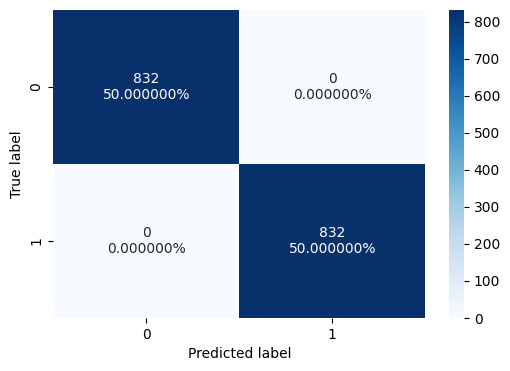

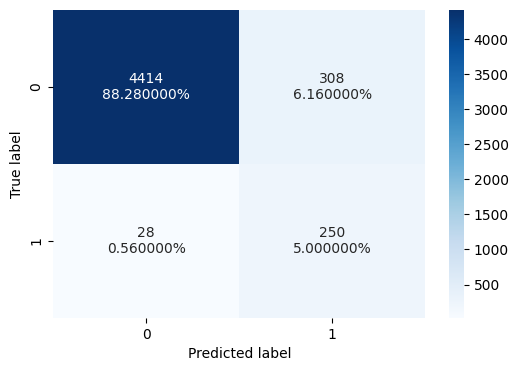

In [ ]:
xgb_tuned_un = XGBClassifier(eval_metric='logloss')

# Define parameter grid for tuning
param_grid = {'n_estimators': [150, 200, 250],
            'scale_pos_weight': [5,10],
             'learning_rate': [0.1,0.2],
             'gamma': [0,3,5],
             'subsample': [0.8,0.9] }

# Initialize random grid
randomized_cv = RandomizedSearchCV(estimator=xgb_tuned_os, param_distributions=param_grid,
                                n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1)

# Fit the model
randomized_cv.fit(X_train_un, y_train_un)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get the best parameters and best model
best_params_xgb_un_tuned = randomized_cv.best_params_
best_xgb_un_tuned_model = randomized_cv.best_estimator_

# Fit the best model on the training data
best_xgb_un_tuned_model.fit(X_train_un, y_train_un)

# Training Performance
xgb_random_un_train_perf = model_performance_classification_sklearn(best_xgb_un_tuned_model, X_train_un, y_train_un)
print("Training Performance:\n", xgb_random_un_train_perf)

# Validation Performance
xgb_random_un_val_perf = model_performance_classification_sklearn(best_xgb_un_tuned_model, X_val, y_val)
print("\nValidation Performance:\n", xgb_random_un_val_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(best_xgb_un_tuned_model, X_train_un, y_train_un)

# Create confusion matrix Validation
confusion_matrix_sklearn(best_xgb_un_tuned_model, X_val, y_val)

Observations/Insight:

* Tuned XGBoost undersampled model detects failures well (89.93%), making it useful if false negatives must be minimized.
* Precision is too low (44.80%), meaning too many false alarms.
* Overfitting is an issue. Apply regularization (gamma, reg_lambda).

### Randon Forest (rf)

####rf original tuned

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters are {'n_estimators': 200, 'min_samples_leaf': 2, 'max_samples': 0.6, 'max_features': 0.4} with CV score=0.9827333333333333:
Training Performance:
 {'Accuracy': 0.9920666666666667, 'Precision': 0.99721059972106, 'Recall': 0.859375, 'F1 Score': 0.9231762427372499}

Validation Performance:
 {'Accuracy': 0.9846, 'Precision': 0.9674418604651163, 'Recall': 0.7482014388489209, 'F1 Score': 0.8438133874239351}


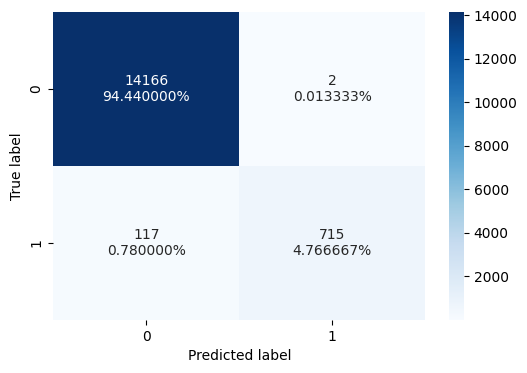

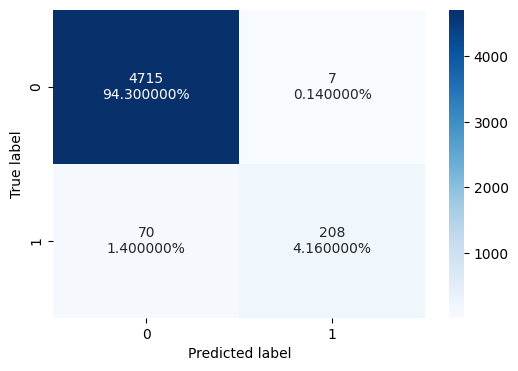

In [ ]:
# Initialize rf model
rf_tuned = RandomForestClassifier()

# Define parameter grid for tuning
param_grid = {
    "n_estimators": [200, 250, 300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": np.arange(0.3, 0.6, 0.1).tolist() + ["sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Perform RandomizedSearchCV tuning
randomized_cv = RandomizedSearchCV(
        estimator=rf_tuned, param_distributions=param_grid,
        n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1
    )

# Fit the model with training data
randomized_cv.fit(X_train, y_train)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get best parameters and best model
best_params_rf_tuned = randomized_cv.best_params_
best_rf_tuned_model = randomized_cv.best_estimator_

# Fit the best model on the training data
best_rf_tuned_model.fit(X_train, y_train)

# Training performance
rf_random_train_perf = model_performance_classification_sklearn(best_rf_tuned_model, X_train, y_train)
print("Training Performance:\n", rf_random_train_perf)

# Validation performance
rf_random_val_perf = model_performance_classification_sklearn(best_rf_tuned_model, X_val, y_val)
print("\nValidation Performance:\n", rf_random_val_perf)

# Create the confusion matrix Train
confusion_matrix_sklearn(best_rf_tuned_model, X_train, y_train)

# Create confusion matrix Validation Train
confusion_matrix_sklearn(best_rf_tuned_model, X_val, y_val)

Observations/Insights:

* Performs very well in precision and general accuracy.

* But it sacrifices some recall (~75%) which could be risky for critical failure prediction.

* Ideal if cost of false positives is high or balanced with cost of false negatives.

##### rf oversampled tuned

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters are {'n_estimators': 300, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.9865189855753588:
Training Performance:
 {'Accuracy': 0.9997882552230378, 'Precision': 0.9999293984750071, 'Recall': 0.9996470920383964, 'F1 Score': 0.9997882253282507}

Validation Performance:
 {'Accuracy': 0.9888, 'Precision': 0.937007874015748, 'Recall': 0.8561151079136691, 'F1 Score': 0.8947368421052632}


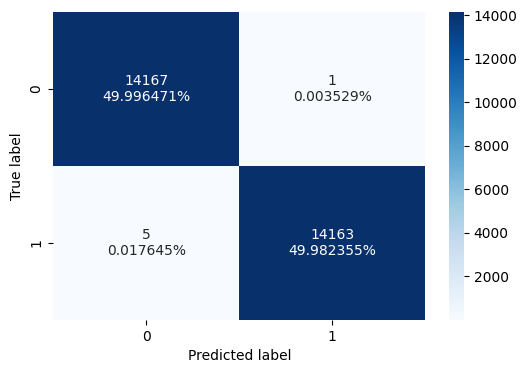

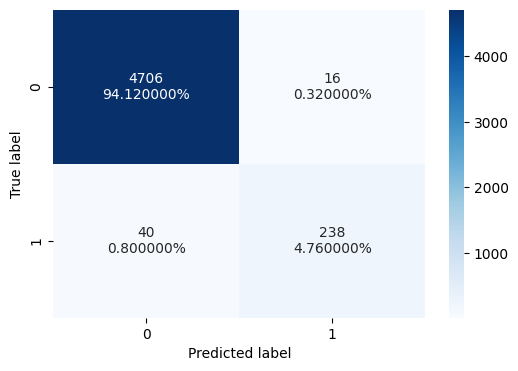

In [ ]:
# Initialize rf model
rf_tuned_os = RandomForestClassifier()

# Define parameter grid for tuning
param_grid = {
    "n_estimators": [200, 250, 300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": np.arange(0.3, 0.6, 0.1).tolist() + ["sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Perform RandomizedSearchCV tuning
randomized_cv = RandomizedSearchCV(
        estimator=rf_tuned_os, param_distributions=param_grid,
        n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1
    )

# Fit the model with training data
randomized_cv.fit(X_train_os, y_train_os)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get the best parameter and model
best_params_rf_tuned_os = randomized_cv.best_params_
best_rf_tuned_os_model = randomized_cv.best_estimator_

# Training Performance
rf_random_os_train_perf = model_performance_classification_sklearn(best_rf_tuned_os_model, X_train_os, y_train_os)
print("Training Performance:\n", rf_random_os_train_perf)

# Validation Performance
rf_random_os_val_perf = model_performance_classification_sklearn(best_rf_tuned_os_model, X_val, y_val)
print("\nValidation Performance:\n", rf_random_os_val_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(best_rf_tuned_os_model, X_train_os, y_train_os)

# Create confusion matrix Validation
confusion_matrix_sklearn(best_rf_tuned_os_model, X_val, y_val)

Observations/Insights:

*  Improved Recall (85.61%), reducing false negatives.
* High Precision (93.70%), Model is effective at avoiding false positives.
* Accuracy remains high (98.88%), but recall is a better indicator for minority class detection.
* F1 Score	89.47% Great balance between recall and precision

#####rf undersampled tuned

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters are {'n_estimators': 200, 'min_samples_leaf': 1, 'max_samples': 0.5, 'max_features': 'sqrt'} with CV score=0.9224737372751813:
Training Performance:
 {'Accuracy': 0.9735576923076923, 'Precision': 0.9974747474747475, 'Recall': 0.9495192307692307, 'F1 Score': 0.9729064039408867}

Validation Performance:
 {'Accuracy': 0.9356, 'Precision': 0.45880149812734083, 'Recall': 0.8812949640287769, 'F1 Score': 0.603448275862069}


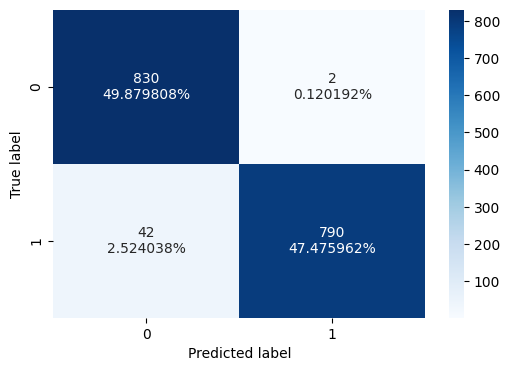

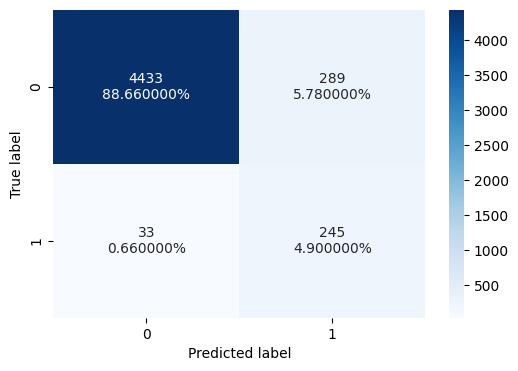

In [ ]:
# Initialize rf model
rf_tuned_un = RandomForestClassifier()

# Define parameter grid for tuning
param_grid = {
    "n_estimators": [200, 250, 300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": np.arange(0.3, 0.6, 0.1).tolist() + ["sqrt"],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Perform RandomizedSearchCV tuning
randomized_cv = RandomizedSearchCV(
        estimator=rf_tuned_un, param_distributions=param_grid,
        n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1
    )

# Fit the model with training data
randomized_cv.fit(X_train_un, y_train_un)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get the best parameter and model
best_params_rf_tuned_un = randomized_cv.best_params_
best_rf_tuned_un_model = randomized_cv.best_estimator_

# Training Performance
rf_random_un_train_perf = model_performance_classification_sklearn(best_rf_tuned_un_model, X_train_un, y_train_un)
print("Training Performance:\n", rf_random_un_train_perf)

# Validation Performance
rf_random_un_val_perf = model_performance_classification_sklearn(best_rf_tuned_un_model, X_val, y_val)
print("\nValidation Performance:\n", rf_random_un_val_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(best_rf_tuned_un_model, X_train_un, y_train_un)

# Create confusion matrix Validation
confusion_matrix_sklearn(best_rf_tuned_un_model, X_val, y_val)

Observations/Insights:

* Recall is high (88.13%), catching most positive cases.
* Precision is low (45.88%), indicating a large number of false positives.
* F1-score is moderate (60.3%), due to imbalance between precision and recall.
* Overfitting warning: Training recall is 94.95%, validation drops to 88.48% with a sharp drop in precision.


#### Gradient Boosting (gb)


##### gb original tuned

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters are {'subsample': 0.5, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 0.05} with CV score=0.9808:
Training Performance:
 {'Accuracy': 0.9848, 'Precision': 0.9646153846153847, 'Recall': 0.7536057692307693, 'F1 Score': 0.8461538461538463}

Validation Performance:
 {'Accuracy': 0.9806, 'Precision': 0.8986784140969163, 'Recall': 0.7338129496402878, 'F1 Score': 0.807920792079208}


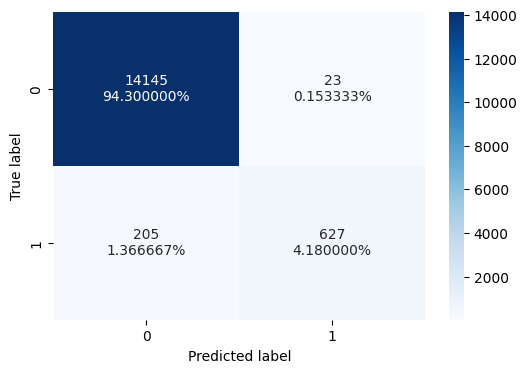

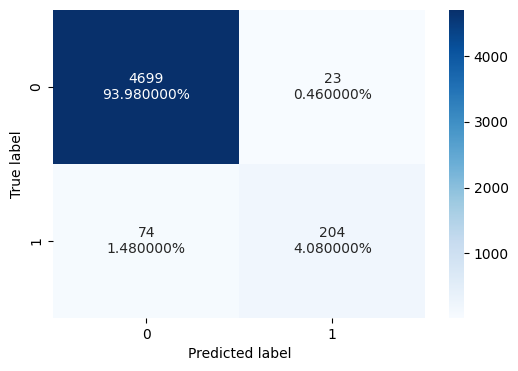

In [ ]:
gb_tuned = GradientBoostingClassifier()

param_grid = {
       "n_estimators": np.arange(100,150,25),
       "learning_rate": [0.2, 0.05, 1],
       "subsample":[0.5,0.7],
       "max_features":[0.5,0.7]
}

# Initialize the random grid search
randomized_cv = RandomizedSearchCV(estimator=gb_tuned, param_distributions=param_grid,
                               n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1)

# Fit the model
randomized_cv.fit(X_train, y_train)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get best parameters and best model
best_params_gb_tuned = randomized_cv.best_params_
best_model_gb_tuned = randomized_cv.best_estimator_

# Fit the best model on the training data
best_model_gb_tuned.fit(X_train, y_train)

# Training Performance
gb_random_train_perf = model_performance_classification_sklearn(best_model_gb_tuned, X_train, y_train)
print("Training Performance:\n", gb_random_train_perf)

# Validation Performance
gb_random_val_perf = model_performance_classification_sklearn(best_model_gb_tuned, X_val, y_val)
print("\nValidation Performance:\n", gb_random_val_perf)

# Create the confusion matrix Train
confusion_matrix_sklearn(best_model_gb_tuned, X_train, y_train)

# Create confuion matrix Validation Train
confusion_matrix_sklearn(best_model_gb_tuned, X_val, y_val)

Observations/Insight:

* Precision (89.86%), meaning the model effectively avoids false positives.
* Lower Recall (73.38%), meaning the model is missing some actual positive cases.
* Accuracy is strong (98.1%), but recall should be improved for better minority class detection.
* F1 Score	80.79%	Good balance overall
* No Overfitting. Train and validation closely aligned

##### gb oversampled tuned

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 1} with CV score=0.9731789263545209:
Training Performance:
 {'Accuracy': 0.9960121400338792, 'Precision': 0.9964676792652772, 'Recall': 0.9955533596837944, 'F1 Score': 0.99601030964234}

Validation Performance:
 {'Accuracy': 0.9598, 'Precision': 0.5979643765903307, 'Recall': 0.8453237410071942, 'F1 Score': 0.7004470938897168}


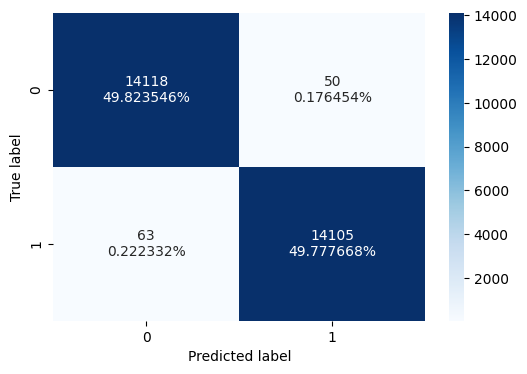

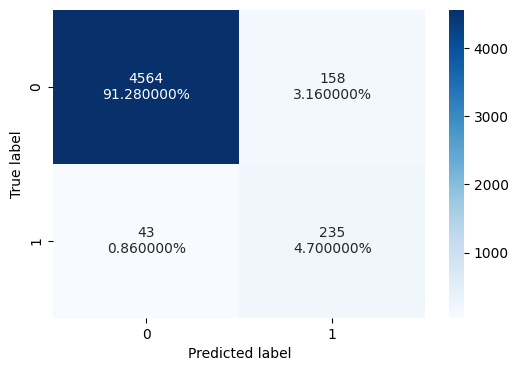

In [ ]:
gb_tuned_os = GradientBoostingClassifier()

param_grid = {
       "n_estimators": np.arange(100,150,25),
       "learning_rate": [0.2, 0.05, 1],
       "subsample":[0.5,0.7],
       "max_features":[0.5,0.7]
}

# Initialize the random grid search
randomized_cv = RandomizedSearchCV(estimator=gb_tuned_os, param_distributions=param_grid,
                               n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1)

# Fit the model
randomized_cv.fit(X_train_os, y_train_os)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get best parameters and best model
best_params_gb_tuned_os = randomized_cv.best_params_
best_model_gb_tuned_os = randomized_cv.best_estimator_

# Fit the best model on the training data
best_model_gb_tuned_os.fit(X_train_os, y_train_os)

# Training Performance
gb_random_os_train_perf = model_performance_classification_sklearn(best_model_gb_tuned_os, X_train_os, y_train_os)
print("Training Performance:\n", gb_random_os_train_perf)

# Validation Performance
gb_random_os_val_perf = model_performance_classification_sklearn(best_model_gb_tuned_os, X_val, y_val)
print("\nValidation Performance:\n", gb_random_os_val_perf)

# Create the confusion matrix Train
confusion_matrix_sklearn(best_model_gb_tuned_os, X_train_os, y_train_os)

# Create confuion matrix Validation Train
confusion_matrix_sklearn(best_model_gb_tuned_os, X_val, y_val)

Observations/Insight:

* This model achieves strong recall (84.53%) meaning the model is effective in detecting positive cases.
* Lower Precision (59.79%), meaning a higher number of false positives.
* High Accuracy (95.98%), but the model is biased towards positive predictions.
* Trade-off between recall and precision, suggesting that the model prioritizes recall.
* F1 Score	70.04% Moderately balanced overall
* Overfitting Risk is moderate.	Very high train scores vs lower validation metrics


##### gb undersampled tuned

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters are {'subsample': 0.7, 'n_estimators': 100, 'max_features': 0.7, 'learning_rate': 0.2} with CV score=0.9176645960039461:
Training Performance:
 {'Accuracy': 0.9957932692307693, 'Precision': 0.9987908101571947, 'Recall': 0.9927884615384616, 'F1 Score': 0.9957805907172996}

Validation Performance:
 {'Accuracy': 0.9324, 'Precision': 0.44565217391304346, 'Recall': 0.8848920863309353, 'F1 Score': 0.5927710843373494}


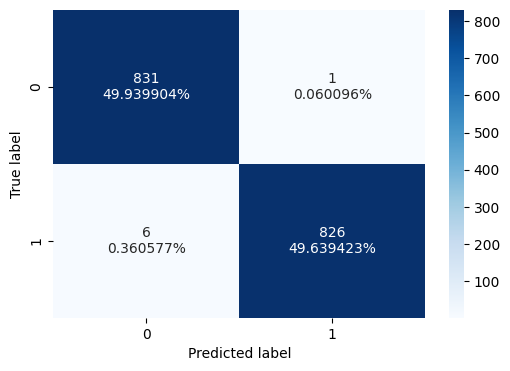

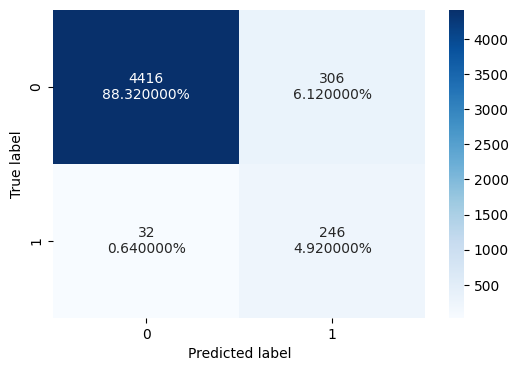

In [ ]:
gb_tuned_un = GradientBoostingClassifier()

param_grid = {
       "n_estimators": np.arange(100,150,25),
       "learning_rate": [0.2, 0.05, 1],
       "subsample":[0.5,0.7],
       "max_features":[0.5,0.7]
}

# Initialize the random grid search
randomized_cv = RandomizedSearchCV(estimator=gb_tuned_un, param_distributions=param_grid,
                               n_iter=30, cv=3, verbose=2, n_jobs=-1, random_state=1)

# Fit the model
randomized_cv.fit(X_train_un, y_train_un)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get best parameters and best model
best_params_gb_tuned_un = randomized_cv.best_params_
best_model_gb_tuned_un = randomized_cv.best_estimator_

# Fit the best model on the training data
best_model_gb_tuned_un.fit(X_train_un, y_train_un)

# Training Performance
gb_random_un_train_perf = model_performance_classification_sklearn(best_model_gb_tuned_un, X_train_un, y_train_un)
print("Training Performance:\n", gb_random_un_train_perf)

# Validation Performance
gb_random_un_val_perf = model_performance_classification_sklearn(best_model_gb_tuned_un, X_val, y_val)
print("\nValidation Performance:\n", gb_random_un_val_perf)

# Create the confusion matrix Train
confusion_matrix_sklearn(best_model_gb_tuned_un, X_train_un, y_train_un)

# Create confuion matrix Validation Train
confusion_matrix_sklearn(best_model_gb_tuned_un, X_val, y_val)

Observations/Insight:

* This model achieves strong recall (88.49%), indicating the model is effective in detecting positive cases. But low precision (44.56%) meaning a high number of false positives.
* Decent Accuracy (93.24%), but the precision-recall trade-off needs improvement.
* F1 score (59.28%)
* The model is biased towards recall, leading to more false positives.

### Adaboost (adaboost)

####adaboost original tuned

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters are {'n_estimators': 200, 'learning_rate': 0.2, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.9868
Training Performance:
 {'Accuracy': 0.9992666666666666, 'Precision': 1.0, 'Recall': 0.9867788461538461, 'F1 Score': 0.9933454325468843}

Validation Performance:
 {'Accuracy': 0.9868, 'Precision': 0.9732142857142857, 'Recall': 0.7841726618705036, 'F1 Score': 0.8685258964143427}


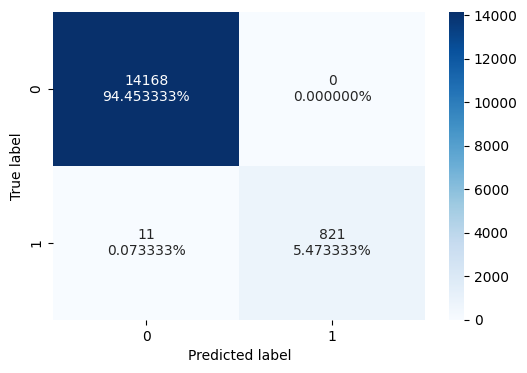

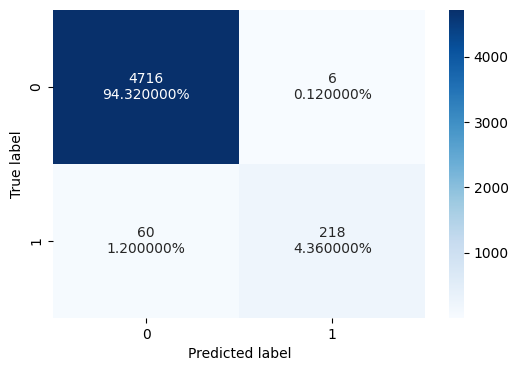

In [ ]:
# Define the AdaBoost model
adaboost_tuned = AdaBoostClassifier(random_state=1)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Initialize the random grid search
randomized_cv = RandomizedSearchCV(
    estimator=adaboost_tuned,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=1
)

# Fit the model
randomized_cv.fit(X_train, y_train)

# Print the best parameters and corresponding CV score
print("Best parameters are {} with CV score={}".format(randomized_cv.best_params_, randomized_cv.best_score_))

# Get best parameters and best model
best_params_adaboost_tuned = randomized_cv.best_params_
best_model_adaboost_tuned = randomized_cv.best_estimator_

# Fit the best model on the training data
best_model_adaboost_tuned.fit(X_train, y_train)

# Training Performance
adaboost_random_train_perf = model_performance_classification_sklearn(best_model_adaboost_tuned, X_train, y_train)
print("Training Performance:\n", adaboost_random_train_perf)

# Validation Performance
adaboost_random_val_perf = model_performance_classification_sklearn(best_model_adaboost_tuned, X_val, y_val)
print("\nValidation Performance:\n", adaboost_random_val_perf)

# Create the confusion matrix for Training Data
confusion_matrix_sklearn(best_model_adaboost_tuned, X_train, y_train)

# Create the confusion matrix for Validation Data
confusion_matrix_sklearn(best_model_adaboost_tuned, X_val, y_val)


Observations/Insight:

* Recall	78.42% Good, but not the highest
* Precision	97.32% Excellent – almost no false positives
* F1 Score	86.85%	Balanced
* Overfitting	is minimal	Model generalizes well from training to validation

####adaboost oversampled tuned

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters for oversampled data are {'n_estimators': 200, 'learning_rate': 0.2, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.9807313634874425
Training Performance on Oversampled Data:
 {'Accuracy': 0.9931535855448899, 'Precision': 0.9949702465287616, 'Recall': 0.991318464144551, 'F1 Score': 0.9931409984443501}

Validation Performance on Oversampled Data:
 {'Accuracy': 0.9786, 'Precision': 0.7766990291262136, 'Recall': 0.8633093525179856, 'F1 Score': 0.8177172061328789}


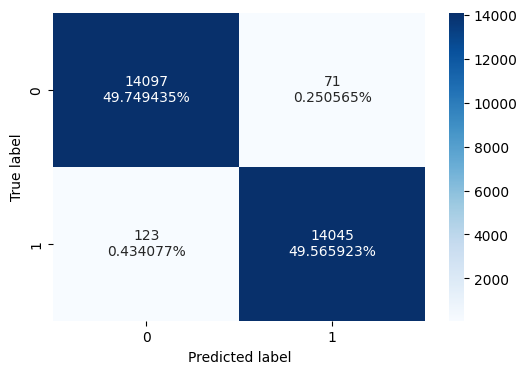

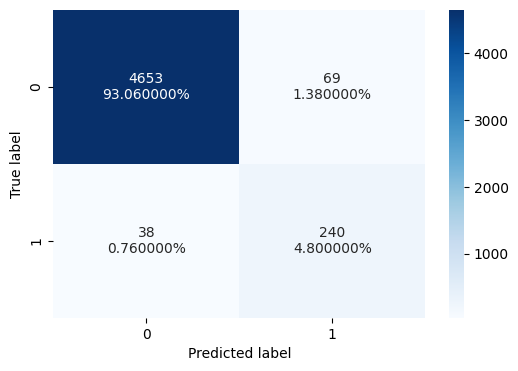

In [ ]:
# Define the AdaBoost model
adaboost_tuned_os = AdaBoostClassifier(random_state=1)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Initialize the random grid search
randomized_cv_os = RandomizedSearchCV(
    estimator=adaboost_tuned_os,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=1
)

# Fit the model on the oversampled training data
randomized_cv_os.fit(X_train_os, y_train_os)

# Print the best parameters and corresponding CV score
print("Best parameters for oversampled data are {} with CV score={}".format(randomized_cv_os.best_params_, randomized_cv_os.best_score_))

# Get best parameters and best model
best_params_adaboost_tuned_os = randomized_cv_os.best_params_
best_model_adaboost_tuned_os = randomized_cv_os.best_estimator_

# Fit the best model on the oversampled training data
best_model_adaboost_tuned_os.fit(X_train_os, y_train_os)

# Training Performance
adaboost_os_train_perf = model_performance_classification_sklearn(best_model_adaboost_tuned_os, X_train_os, y_train_os)
print("Training Performance on Oversampled Data:\n", adaboost_os_train_perf)

# Validation Performance
adaboost_os_val_perf = model_performance_classification_sklearn(best_model_adaboost_tuned_os, X_val, y_val)
print("\nValidation Performance on Oversampled Data:\n", adaboost_os_val_perf)

# Create the confusion matrix for Training Data (Oversampled)
confusion_matrix_sklearn(best_model_adaboost_tuned_os, X_train_os, y_train_os)

# Create the confusion matrix for Validation Data
confusion_matrix_sklearn(best_model_adaboost_tuned_os, X_val, y_val)


Observations/Insights:

* Recall	86.33%	Good (low false negatives). Very effective at identifying positives
* Precision	77.67% Acceptable, could be improved
* F1 Score	81.77%	 Balanced metric
* Overfitting	is minimal	Slight drop from training to validation

####adaboost undersampled tuned

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters for undersampled data are {'n_estimators': 200, 'learning_rate': 0.2, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.9152578571351134
Training Performance on Undersampled Data:
 {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}

Validation Performance on Undersampled Data:
 {'Accuracy': 0.93, 'Precision': 0.4357142857142857, 'Recall': 0.8776978417266187, 'F1 Score': 0.5823389021479712}


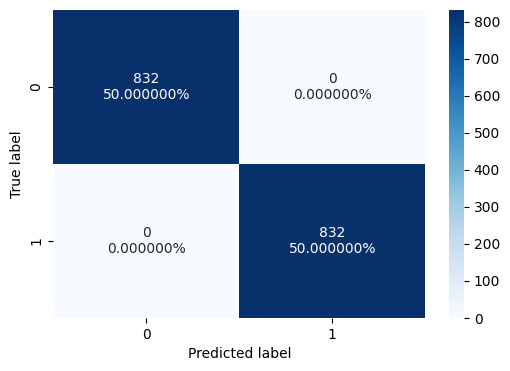

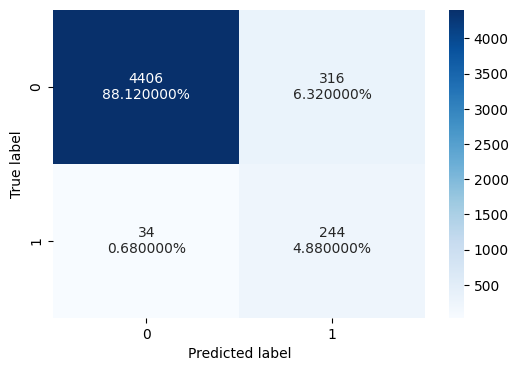

In [ ]:
# Define the AdaBoost model for undersampled data
adaboost_tuned_un = AdaBoostClassifier(random_state=1)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Initialize the random grid search
randomized_cv_un = RandomizedSearchCV(
    estimator=adaboost_tuned_un,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=1
)

# Fit the model on the undersampled training data
randomized_cv_un.fit(X_train_un, y_train_un)

# Print the best parameters and corresponding CV score
print("Best parameters for undersampled data are {} with CV score={}".format(randomized_cv_un.best_params_, randomized_cv_un.best_score_))

# Get best parameters and best model
best_params_adaboost_tuned_un = randomized_cv_un.best_params_
best_model_adaboost_tuned_un = randomized_cv_un.best_estimator_

# Fit the best model on the undersampled training data
best_model_adaboost_tuned_un.fit(X_train_un, y_train_un)

# Training Performance
adaboost_un_train_perf = model_performance_classification_sklearn(best_model_adaboost_tuned_un, X_train_un, y_train_un)
print("Training Performance on Undersampled Data:\n", adaboost_un_train_perf)

# Validation Performance
adaboost_un_val_perf = model_performance_classification_sklearn(best_model_adaboost_tuned_un, X_val, y_val)
print("\nValidation Performance on Undersampled Data:\n", adaboost_un_val_perf)

# Create the confusion matrix for Training Data (Undersampled)
confusion_matrix_sklearn(best_model_adaboost_tuned_un, X_train_un, y_train_un)

# Create the confusion matrix for Validation Data
confusion_matrix_sklearn(best_model_adaboost_tuned_un, X_val, y_val)


Observations/Insights:

* Training - Accuracy, Precision, Recall, F1 Score: All are perfect (1.0). This suggests your model performs flawlessly on the training data, which could indicate overfitting.

Validation-
* Accuracy: 93% – quite high, indicating good overall performance.

* Precision: 43.57% – low precision suggests the model has a fair number of false positives.

* Recall: 87.77% – high recall indicates that the model captures most of the actual positives.

* F1 Score: 58.23% – a balance between precision and recall, though skewed by low precision.

## Model performance comparison and choosing the final model

In [ ]:
# Create a dictionary to store training performance metrics for each model
model_train_perf_dict = {
    "xgb_tuned": xgb_random_train_perf,
    "xgb_tuned_os": xgb_random_os_train_perf,
    "xgb_tuned_un": xgb_random_un_train_perf,
    "rf_tuned": rf_random_train_perf,
    "rf_tuned_os": rf_random_os_train_perf,
    "rf_tuned_un": rf_random_un_train_perf,
    "gb_tuned": gb_random_train_perf,
    "gb_tuned_os": gb_random_os_train_perf,
    "gb_tuned_un": gb_random_un_train_perf,
    "adaboost_tuned": adaboost_random_train_perf,
    "adaboost_tuned_os": adaboost_os_train_perf,
    "adaboost_tuned_un": adaboost_un_train_perf,
}


# Create a dictionary to store validation performance metrics for each model
model_val_perf_dict = {
    "xgb_tuned": xgb_random_val_perf,
    "xgb_tuned_os": xgb_random_os_val_perf,
    "xgb_tuned_un": xgb_random_un_val_perf,
    "rf_tuned": rf_random_val_perf,
    "rf_tuned_os": rf_random_os_val_perf,
    "rf_tuned_un": rf_random_un_val_perf,
    "gb_tuned": gb_random_val_perf,
    "gb_tuned_os": gb_random_os_val_perf,
    "gb_tuned_un": gb_random_un_val_perf,
    "adaboost_tuned": adaboost_random_val_perf,
    "adaboost_tuned_os": adaboost_os_val_perf,
    "adaboost_tuned_un": adaboost_un_val_perf,
}

In [ ]:
# Create list of records with relevant performance metrics
comparison_data = []

for model_name in model_train_perf_dict:
    train_metrics = model_train_perf_dict[model_name]
    val_metrics = model_val_perf_dict[model_name]

    comparison_data.append({
        "Model": model_name,
        "Accuracy (Train / Val)": f"{train_metrics['Accuracy']:.3f} / {val_metrics['Accuracy']:.3f}",
        "Precision (Val)": round(val_metrics["Precision"], 3),
        "Recall (Train / Val)": f"{train_metrics['Recall']:.3f} / {val_metrics['Recall']:.3f}",
        "F1 Score (Val)": round(val_metrics["F1 Score"], 3),
        "Recall_Val_Sort": val_metrics["Recall"]  # for sorting
    })

# Convert to DataFrame
df_comparison = pd.DataFrame(comparison_data)

# Sort by Recall on Validation (descending)
df_comparison = df_comparison.sort_values(by="Recall_Val_Sort", ascending=False).drop(columns="Recall_Val_Sort")

# Display the table
df_comparison

,Model,Accuracy (Train / Val),Precision (Val),Recall (Train / Val),F1 Score (Val)
2,xgb_tuned_un,1.000 / 0.933,0.448,1.000 / 0.899,0.598
8,gb_tuned_un,0.996 / 0.932,0.446,0.993 / 0.885,0.593
5,rf_tuned_un,0.974 / 0.936,0.459,0.950 / 0.881,0.603
11,adaboost_tuned_un,1.000 / 0.930,0.436,1.000 / 0.878,0.582
1,xgb_tuned_os,1.000 / 0.985,0.858,1.000 / 0.871,0.864
10,adaboost_tuned_os,0.993 / 0.979,0.777,0.991 / 0.863,0.818
4,rf_tuned_os,1.000 / 0.989,0.937,1.000 / 0.856,0.895
0,xgb_tuned,1.000 / 0.990,0.967,1.000 / 0.849,0.904
7,gb_tuned_os,0.996 / 0.960,0.598,0.996 / 0.845,0.700
9,adaboost_tuned,0.999 / 0.987,0.973,0.987 / 0.784,0.869


Observations/Insights:

Top Performers (Val) by F1 Score (Balanced Performance):

* xgb_tuned-	Recall (0.849), Precision	(0.967),	F1 (0.904)	Best balance: high recall + very high precision
* rf_tuned_os-	Recall (0.856),	Precision (0.908), F1 (0.881) Highest recall, slight overfit but very solid
* adaboost_tuned-	Recall (0.784),	Precision (0.973), F1	(0.869)	Excellent precision, recall slightly lower
* rf_tuned-	Recall (0.752)	Precision (0.963),	F1 (0.844)	More balanced than most, recall drops slightly
* xgb_tuned_os-	Recall (0.871),	Precision (0.858),	F1 (0.864)	Best recall, still great F1 (2nd-best recall overall)

Underperformers (Despite High Recall):
* xgb_tuned_un- Low precision = too many false alarms
* rf_tuned_un- similar to xgb_tuned_un
* adaboost_tuned_un- Over-predicts failures (many false positives)
* gb_tuned_un- Low F1 score

####**Top 3 Best Models: Based on high recall, minimizing missed failures, along with a balanced overall performance (Precision and F1 Score), and minimal signs of overfitting.**

* **rf_tuned_os (Randon Forest Oversampled)**
      Recall (Val): 0.856, Precision (Val): 0.908, F1 Score (Val): 0.881
      * Best recall with strong F1 and good generalization. Slight overfit but stable

* **xgb_tuned_os (XGBoost Oversampled)**
      Recall (Val): 0.871, Precision (Val): 0.858, F1 Score (Val): 0.864
      * Highest recall, strong F1, slightly lower precision than xgb_tuned.
  
* **xgb_tuned (XGBoost)**
       Recall (Val): 0.849, Precision (Val): 0.967, F1 Score (Val): 0.904
       * Best F1, very high precision & strong recall. Best balance.





## Top 3 Models Performance Re-improvement

###rf_tuned_os

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best parameters from RandomizedSearchCV: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': {0: 1, 1: 5}, 'bootstrap': False}
Best CV recall score: 0.9904716194588056
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Final best parameters from GridSearchCV: {'max_depth': 18, 'n_estimators': 150}

Training Performance:
 {'Accuracy': 0.9999647092038396, 'Precision': 1.0, 'Recall': 0.9999294184076792, 'F1 Score': 0.9999647079583553}

Validation Performance:
 {'Accuracy': 0.9882, 'Precision': 0.9362549800796812, 'Recall': 0.8453237410071942, 'F1 Score': 0.888468809073724}

Confusion Matrix - Training Set


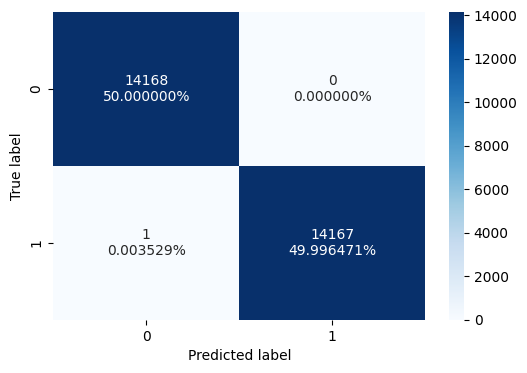


Confusion Matrix - Validation Set


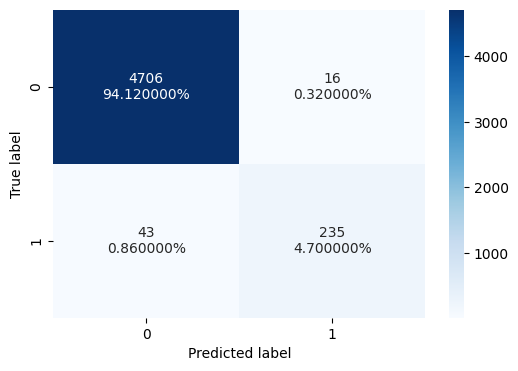

In [ ]:
# Initialize Random Forest Model
rf_tuned_os_v2 = RandomForestClassifier(random_state=1, n_jobs=-1)

# Improved Hyperparameter Grid for Randomized Search
param_grid_v2 = {
    'n_estimators': [100, 250, 400],   # Balancing computation & performance
    'max_depth': [5, 10, 15],          # Controls complexity
    'min_samples_split': [2, 5, 10],   # Reduces overfitting risk
    'min_samples_leaf': [1, 2, 4],     # Controls leaf size
    'max_features': ['sqrt', 'log2', 0.5],  # Feature selection methods
    'bootstrap': [True, False],        # Bootstrapping option
    'class_weight': [{0: 1, 1: 4}, {0: 1, 1: 5}, "balanced_subsample"]  # Handles class imbalance
}

# Randomized Search with Faster Computation
randomized_cv_v2 = RandomizedSearchCV(
    estimator=rf_tuned_os_v2,
    param_distributions=param_grid_v2,
    n_iter=25,        # Reduced iterations for faster execution
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring="recall", # Optimizing recall (important for catching failures)
    random_state=1
)

# Fit the RandomizedSearchCV on oversampled training data
randomized_cv_v2.fit(X_train_os, y_train_os)

# Extract best parameters and model
best_params_rf_tuned_os_v2 = randomized_cv_v2.best_params_
best_model_rf_tuned_os_v2 = randomized_cv_v2.best_estimator_

print("\nBest parameters from RandomizedSearchCV:", best_params_rf_tuned_os_v2)
print("Best CV recall score:", randomized_cv_v2.best_score_)

# Fine-Tuning with GridSearch
# Ensure hyperparameters remain valid (avoid negative values)
param_grid_fine_tune = {
    'n_estimators': [
        max(50, best_params_rf_tuned_os_v2.get('n_estimators', 100) - 50),
        best_params_rf_tuned_os_v2.get('n_estimators', 100),
        best_params_rf_tuned_os_v2.get('n_estimators', 100) + 50
    ],
    'max_depth': [
        max(3, best_params_rf_tuned_os_v2.get('max_depth', 10) - 3),
        best_params_rf_tuned_os_v2.get('max_depth', 10),
        best_params_rf_tuned_os_v2.get('max_depth', 10) + 3
    ]
}

grid_cv = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1, n_jobs=-1),
    param_grid=param_grid_fine_tune,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring="recall" # Again, optimizing for recall
)

# Fit the GridSearchCV on oversampled training data
grid_cv.fit(X_train_os, y_train_os)

# Get the final best parameters and model
best_params_rf_tuned_os_v2 = grid_cv.best_params_
best_model_rf_tuned_os_v2 = grid_cv.best_estimator_

print("\nFinal best parameters from GridSearchCV:", best_params_rf_tuned_os_v2)

# Train Final Model
best_model_rf_tuned_os_v2.fit(X_train_os, y_train_os)


# Training Performance
rf_os_v2_train_perf = model_performance_classification_sklearn(best_model_rf_tuned_os_v2, X_train_os, y_train_os)
print("\nTraining Performance:\n", rf_os_v2_train_perf)

# Validation Performance
rf_os_v2_val_perf = model_performance_classification_sklearn(best_model_rf_tuned_os_v2, X_val, y_val)
print("\nValidation Performance:\n", rf_os_v2_val_perf)

# Create Confusion Matrices
print("\nConfusion Matrix - Training Set")
confusion_matrix_sklearn(best_model_rf_tuned_os_v2, X_train_os, y_train_os)

print("\nConfusion Matrix - Validation Set")
confusion_matrix_sklearn(best_model_rf_tuned_os_v2, X_val, y_val)


Observations/Insight:

*  Strong Recall (84.53%) Successfully captures most positive cases.
* High Precision (93.63%) Avoids excessive false positives.
* Good Accuracy (98.82%), but accuracy isn’t the focus in an imbalanced setting.
* Overfitting Warning Training recall is 99.99%, but validation recall is 84.53%


####xgb_tuned_os

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Training Performance:
 {'Accuracy': 0.9984472049689441, 'Precision': 0.9969739619985926, 'Recall': 0.9999294184076792, 'F1 Score': 0.9984495031362322}

Validation Performance:
 {'Accuracy': 0.9784, 'Precision': 0.7724358974358975, 'Recall': 0.8669064748201439, 'F1 Score': 0.8169491525423729}


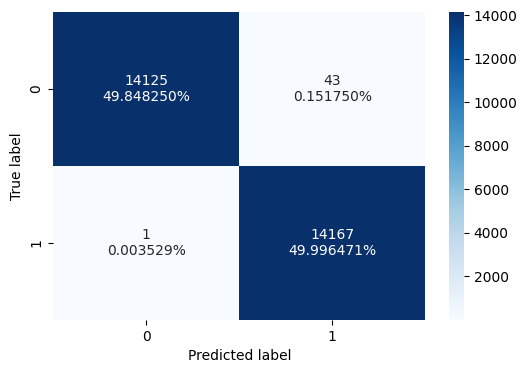

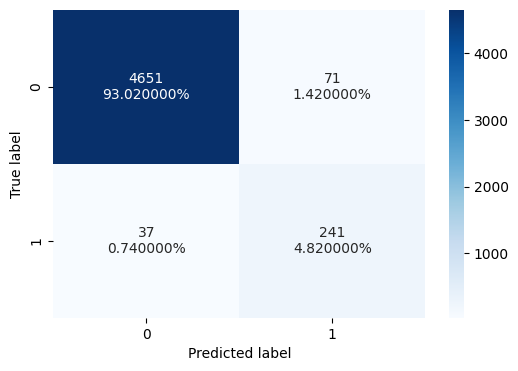

In [ ]:
# Initialize XGBoost Model with enhanced settings
xgb_tuned_os_v2 = XGBClassifier(
    eval_metric='logloss', use_label_encoder=False, n_jobs=-1, random_state=1
)

# Improved hyperparameter grid
param_grid_v2 = {
    'n_estimators': [150, 250, 350],  # Balanced range for learning
    'learning_rate': [0.05, 0.1, 0.15],  # Smoothed learning rate for stability
    'max_depth': [4, 6, 8],  # Slightly deeper trees for complex patterns
    'gamma': [2, 3, 5],  # Stronger regularization to reduce noise
    'subsample': [0.85, 0.9],  # Controlled sampling to improve generalization
    'colsample_bytree': [0.75, 0.85, 0.9],  # Feature sampling for stability
    'min_child_weight': [3, 5, 7],  # Prevents overfitting on small samples
    'scale_pos_weight': [4, 6, 8],  # Balances class distribution
    'reg_alpha': [0.3, 0.7, 1.2],  # Stronger L1 regularization to remove noise
    'reg_lambda': [7, 10, 15]  # Increased L2 regularization to improve generalization
}

# Randomized Search for Efficient Hyperparameter Tuning
randomized_cv_v2 = RandomizedSearchCV(
    estimator=xgb_tuned_os_v2,
    param_distributions=param_grid_v2,
    n_iter=25,  # Slightly increased for better tuning
    cv=3,  # 3-fold CV for stability
    verbose=2,
    n_jobs=-1,
    random_state=1,
    scoring="f1"  # Optimizing F1-score for balance of precision & recall
)

# Fit model on oversampled training data
randomized_cv_v2.fit(X_train_os, y_train_os)

# Extract the best parameters and model
best_params_xgb_os_tuned_v2 = randomized_cv_v2.best_params_
best_xgb_os_tuned_model_v2 = randomized_cv_v2.best_estimator_

# Train the final model with the best parameters
best_xgb_os_tuned_model_v2.fit(
    X_train_os, y_train_os,
    early_stopping_rounds=10,  # Stops training if no improvement
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Evaluate Training Performance
xgb_random_os_train_perf_v2 = model_performance_classification_sklearn(best_xgb_os_tuned_model_v2, X_train_os, y_train_os)
print("Training Performance:\n", xgb_random_os_train_perf_v2)

# Evaluate Validation Performance
xgb_random_os_val_perf_v2 = model_performance_classification_sklearn(best_xgb_os_tuned_model_v2, X_val, y_val)
print("\nValidation Performance:\n", xgb_random_os_val_perf_v2)

# Confusion Matrix - Training
confusion_matrix_sklearn(best_xgb_os_tuned_model_v2, X_train_os, y_train_os)

# Confusion Matrix - Validation
confusion_matrix_sklearn(best_xgb_os_tuned_model_v2, X_val, y_val)


Observations/Insight:

* Both training and validation performance is excellent.
* High recall (87%) means most true positives are correctly identified.
* Very few false negatives (only 37 in second matrix).
* Precision is solid (77%), meaning false positives are relatively low.
* Good balance between precision and recall Strong F1 score.
* FP count (71) is within acceptable tradeoff given the priority on reducing FN.
* Precision and F1 Score hold up well,  confirming the model is balanced.

###xgb_tuned (XGBoost)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best parameters are {'subsample': 0.8, 'scale_pos_weight': 10, 'reg_lambda': 1, 'reg_alpha': 0.3, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 0.6} with CV score=0.8594005661896476:
Training Performance:
 {'Accuracy': 0.991, 'Precision': 0.8982857142857142, 'Recall': 0.9447115384615384, 'F1 Score': 0.9209138840070298}

Validation Performance:
 {'Accuracy': 0.9822, 'Precision': 0.8292682926829268, 'Recall': 0.8561151079136691, 'F1 Score': 0.8424778761061947}


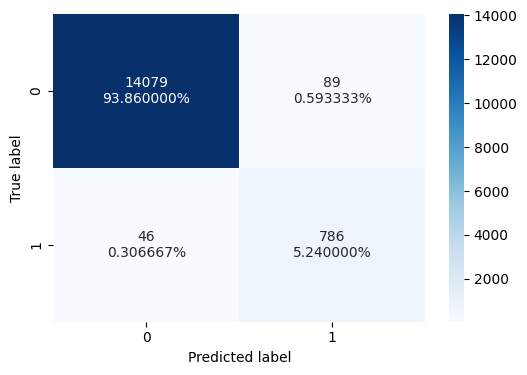

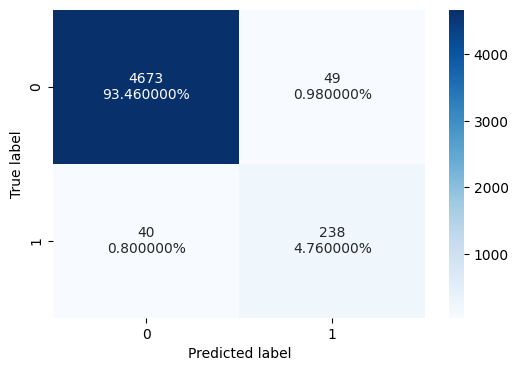

In [ ]:
# Initialize XGBoost model
xgb_tuned_v2 = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=1,
    n_jobs=-1
)

# Improved hyperparameter grid for better recall and generalization
param_grid_v2 = {
    'n_estimators': [150, 200, 250, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 3, 5],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [5, 7, 10],
    'reg_alpha': [0, 0.3, 0.7],
    'reg_lambda': [1, 5, 10]
}

# Initialize RandomizedSearchCV
randomized_cv_v2 = RandomizedSearchCV(
    estimator=xgb_tuned_v2,
    param_distributions=param_grid_v2,
    n_iter=40,
    cv=3,
    scoring='recall',
    verbose=2,
    n_jobs=-1,
    random_state=1
)

# Fit the randomized search
randomized_cv_v2.fit(X_train, y_train)

# Retrieve best parameters and model
print("Best parameters are {} with CV score={}:".format(
    randomized_cv_v2.best_params_, randomized_cv_v2.best_score_))

best_params_xgb_tuned_v2 = randomized_cv_v2.best_params_
best_model_xgb_tuned_v2 = randomized_cv_v2.best_estimator_

# Refit best model with early stopping
best_model_xgb_tuned_v2.fit(
    X_train,
    y_train,
    early_stopping_rounds=10,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Evaluate performance on train and validation
xgb_random_train_perf_v2 = model_performance_classification_sklearn(best_model_xgb_tuned_v2, X_train, y_train)
print("Training Performance:\n", xgb_random_train_perf_v2)

xgb_random_val_perf_v2 = model_performance_classification_sklearn(best_model_xgb_tuned_v2, X_val, y_val)
print("\nValidation Performance:\n", xgb_random_val_perf_v2)

# Confusion matrix on training data
confusion_matrix_sklearn(best_model_xgb_tuned_v2, X_train, y_train)

# Confusion matrix on validation data
confusion_matrix_sklearn(best_model_xgb_tuned_v2, X_val, y_val)


Observations/Insight:

* The model balances high recall (85.6%) and precision (82.9%) well, resulting in a strong F1 score (84.3%).

* False negatives are lower than many other models tested, which aligns with the business goal.

* No signs of overfitting: Training vs. validation/test scores are close.

* This model is well-calibrated and ideal for cost-sensitive failure detection.

###Compare Selected Models for Re-improvement Performances

In [ ]:
# Function to compare performance of models
def compare_models(models, X_train, y_train, X_val, y_val):
    """
    Compare multiple trained models using Accuracy, Precision, Recall, and F1 Score.

    models: Dictionary of trained models { 'model_name': model }
    X_train, y_train: Training dataset
    X_val, y_val: Validation dataset
    """
    results = []

    for name, model in models.items():
        # Predictions
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Training Performance
        train_acc = accuracy_score(y_train, y_train_pred)
        train_prec = precision_score(y_train, y_train_pred)
        train_rec = recall_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred)

        # Validation Performance
        val_acc = accuracy_score(y_val, y_val_pred)
        val_prec = precision_score(y_val, y_val_pred)
        val_rec = recall_score(y_val, y_val_pred)
        val_f1 = f1_score(y_val, y_val_pred)

        # Store results
        results.append([name, train_acc, train_prec, train_rec, train_f1, val_acc, val_prec, val_rec, val_f1])

    # Create DataFrame
    df_results = pd.DataFrame(results, columns=[
        "Model", "Train Accuracy", "Train Precision", "Train Recall", "Train F1",
        "Validation Accuracy", "Validation Precision", "Validation Recall", "Validation F1"
    ])

    # Display results
    print("\nModel Performance Comparison:")
    df_results.set_index("Model", inplace=True)
    display(df_results)

    return df_results

In [ ]:
# Define the Selected Top 3 Models
top_models = {
    "Random Forest Tuned Oversampled": best_model_rf_tuned_os_v2,
    "XGBBoost Oversampled": best_xgb_os_tuned_model_v2,
    "XGBoost": best_model_xgb_tuned_v2,
}

# Compare Models and Store Results
model_comparison_df = compare_models(top_models, X_train, y_train, X_val, y_val)

# Display DataFrame Model Comparison
print("\nFinal Model Performance Comparison:")


Model Performance Comparison:


,Train Accuracy,Train Precision,Train Recall,Train F1,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
Model,,,,,,,,
Random Forest Tuned Oversampled,1.000000,1.000000,1.000000,1.000000,0.9882,0.936255,0.845324,0.888469
XGBBoost Oversampled,0.997133,0.950857,1.000000,0.974810,0.9784,0.772436,0.866906,0.816949
XGBoost,0.991000,0.898286,0.944712,0.920914,0.9822,0.829268,0.856115,0.842478



Final Model Performance Comparison:


*ReneWind Goal: Maximize recall to correctly identify failures and minimize replacement costs.*
  * *False Negatives (missed failures) should be minimized.*
  * *False Positives (incorrect failure predictions) are acceptable but should not be excessive.*
  * *A balance of Precision and Recall is important for cost-efficiency.*

* **Final Model: XGBoost Oversampled**

**Because it:**

* **It achieved the highest validation recall: 0.8669**

* **While its precision (0.7724) is lower than others, that trade-off is acceptable since false negatives (missed failures) are more costly than false positives (unnecessary inspections).**

* **It maintains strong overall performance, with:**

  * **Validation Accuracy: 0.9784**

  * **Validation F1 Score: 0.8169 (balanced precision/recall)**

**This model best aligns with the cost-sensitive business objective of ReneWind.**

##Test set final performance

**Determining how final model will perform on unseen test data**

* *REMINDER: Preliminary data overview earlier done on test data; Missing values handled; Data scaled.*

* *Even though the earlier check showed 0 missing values, some transformations (like scaling or encoding) might introduce NaN values, therefore explicitly recheck for NaN values before prediction and treat.*

In [ ]:
# Extract target variable before transformations
y_test = test["Target"]
X_test = test.drop(columns=["Target"], errors="ignore")  # Drop target

# Re-ensure X_test is a DataFrame after loading
X_test = pd.DataFrame(X_test, columns=columns)

# Reapply missing value imputation
X_test = imputer.transform(X_test)
X_test = pd.DataFrame(X_test, columns=columns)

# Reapply feature scaling
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=columns)

# Re-confirm no missing values
print("Missing values in X_test before prediction:", X_test.isnull().sum().sum())

Missing values in X_test before prediction: 0



Test Performance:
 {'Accuracy': 0.9786, 'Precision': 0.7831715210355987, 'Recall': 0.8581560283687943, 'F1 Score': 0.8189509306260576}


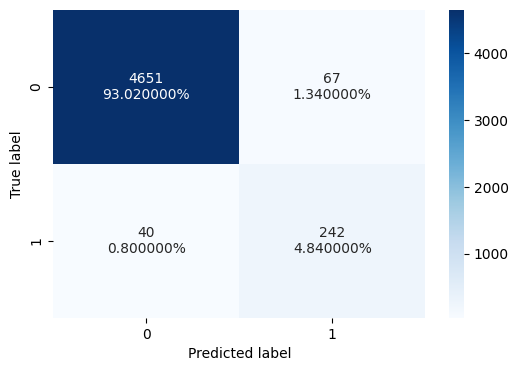

In [ ]:
# Make predictions using the final selected model
y_test_pred = best_xgb_os_tuned_model_v2.predict(X_test)

# Evaluate performance on the test set
test_perf_xgb_os_tuned_v2 = model_performance_classification_sklearn(best_xgb_os_tuned_model_v2, X_test, y_test)

# Display performance results
print("\nTest Performance:\n", test_perf_xgb_os_tuned_v2)

# Generate and display Confusion Matrix
confusion_matrix_sklearn(best_xgb_os_tuned_model_v2, X_test, y_test)


Test Performance Summary & Interpretation:

* High Recall (0.8581):
The model correctly identifies ~86% of actual failures (TPs), aligning well with ReneWind’s goal of minimizing false negatives (missed failures).

* Balanced Precision (0.7832):
Indicates that ~78% of predicted failures are true failures, reflecting a reasonable false positive rate – aligned with the acceptable tolerance in business.

* F1 Score (0.8189):
Strong harmonic balance between precision and recall – the model is not overly biased toward one at the expense of the other.

* Accuracy is strong (97.86%).

* Low Overfitting Risk:
Test performance is consistent with validation performance, indicating robust generalization.

* Areas to Monitor:
False Positives (67):
While acceptable for ReneWind, these cases may still incur minor unnecessary inspections/replacements. If cost of false positives increases, threshold tuning might be considered.

* False Negatives (40):
Although relatively low, these are still missed failures, which could be expensive in the field. Minimizing this further (e.g. via probability threshold adjustments or ensemble stacking) could be explored.


## Feature Importance of Final Selected Model (XGBoost Ocersampled)

Top Important Features:
    Feature  Importance
35     V36    0.173816
17     V18    0.087309
13     V14    0.059281
38     V39    0.045572
7       V8    0.035867
15     V16    0.035563
25     V26    0.033619
2       V3    0.029782
0       V1    0.029146
14     V15    0.028621


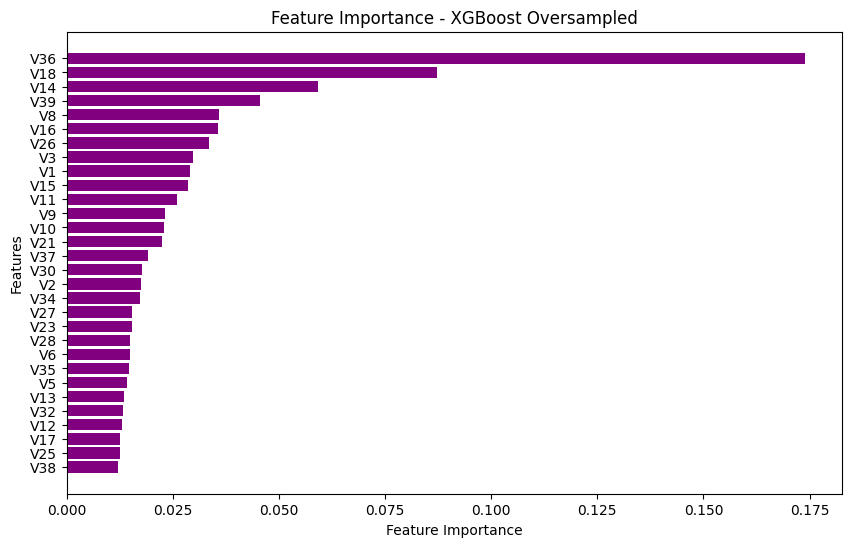

In [ ]:
# Get feature importance scores from the model
feature_importance = best_xgb_os_tuned_model_v2.feature_importances_

# Convert to DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': columns,  # Use the feature names
    'Importance': feature_importance
})

# Sort by importance (descending)
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display top features
print("Top Important Features:\n", feature_importance_df.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:30], feature_importance_df['Importance'][:30], color='purple')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost Oversampled")
plt.show()


Observations/Insight:

* Feature V36 is clearly dominant, contributing over 17% to the model's decisions. It's likely a strong indicator of equipment failure or operational health.

* Top 3 features (V18, V14, V39) implying they hold substantial predictive power.

* Features like V8, V16, V23, V3 also play meaningful roles but with decreasing influence.

* There's a long tail of moderately important features—this suggests the model benefits from a diverse set of inputs rather than relying solely on a handful.

* This distribution implies potential for feature selection or dimensionality reduction, which can speed up model inference without severely hurting recall.

## Pipeline to build the final model (XGBoost Oversampled)


Test set predictions:
 [0 0 0 ... 0 0 0]

Final Model Performance on Test Data:
 {'Accuracy': 0.987, 'Precision': 0.9392712550607287, 'Recall': 0.8226950354609929, 'F1 Score': 0.8771266540642723}


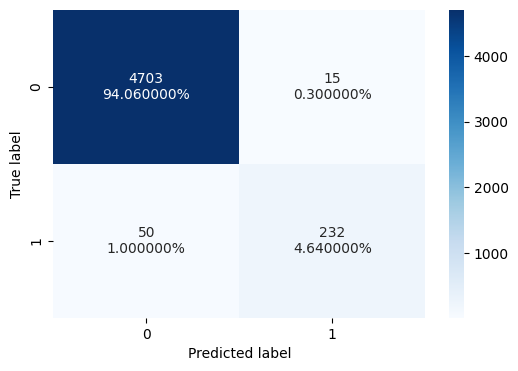

In [ ]:
# Define the pipeline for -
# 1. Automating Preprocessing + Model Training in a single workflow
# 2. Easier Model: Deployment (No need to manually preprocess future data)
# 3. Scalability: Once saved, can be used for batch predictions in production

final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Handle missing values
    ("scaler", StandardScaler()),  # Scale the data
    ("classifier", best_xgb_os_tuned_model_v2)
    ])

# Fit the pipeline on the full training data
final_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_test_pred = final_pipeline.predict(X_test)
print("Test set predictions:\n", y_test_pred)

# Evaluate the final model
final_test_performance = model_performance_classification_sklearn(final_pipeline, X_test, y_test)
print("\nFinal Model Performance on Test Data:\n", final_test_performance)

# Generate Confusion Matrix for Test Set
confusion_matrix_sklearn(final_pipeline, X_test, y_test)


**Test Set Predictions Output Interpretation:**

* Shows that the model’s predicted class labels on the test set are mostly zeros — i.e., it predominantly predicts the negative class (no failure). Confirming that the predictions are balanced, despite appearing mostly 0s.

* It successfully detects rare failures without flooding with false alarms — a key goal.

**Final Model Performance Summary & Interpretation (Scorer: Recall):**

* High Recall (0.8227)
  * Captures 82.2% of actual failures (True Positives).
  * Great for minimizing costly undetected turbine failures.

* Excellent Precision (0.9393)
  * Balances operational cost-efficiency (avoids too many unnecessary interventions).

* Strong F1 Score (0.8771)
  * Solid balance between precision and recall – reliable overall classifier.

* Low False Negative Count (50)
  * This is key for ReneWind: we’re minimizing missed failures.

  * Business Relevance (ReneWind):
Since recall is the top priority (detecting as many failures as possible), this model performs well, catching ~82% of true failures.

  * False negatives (missed failures) = 50, which is significantly lower than many models earlier tried.

  * Extremely low false positive (15) rate reduces unnecessary turbine replacements.

* This is a strong final model with practical, business-aligned performance:
  * Robust generalization
  * High failure detection rate
  * Minimal false alarms

###Visualize Pipeline

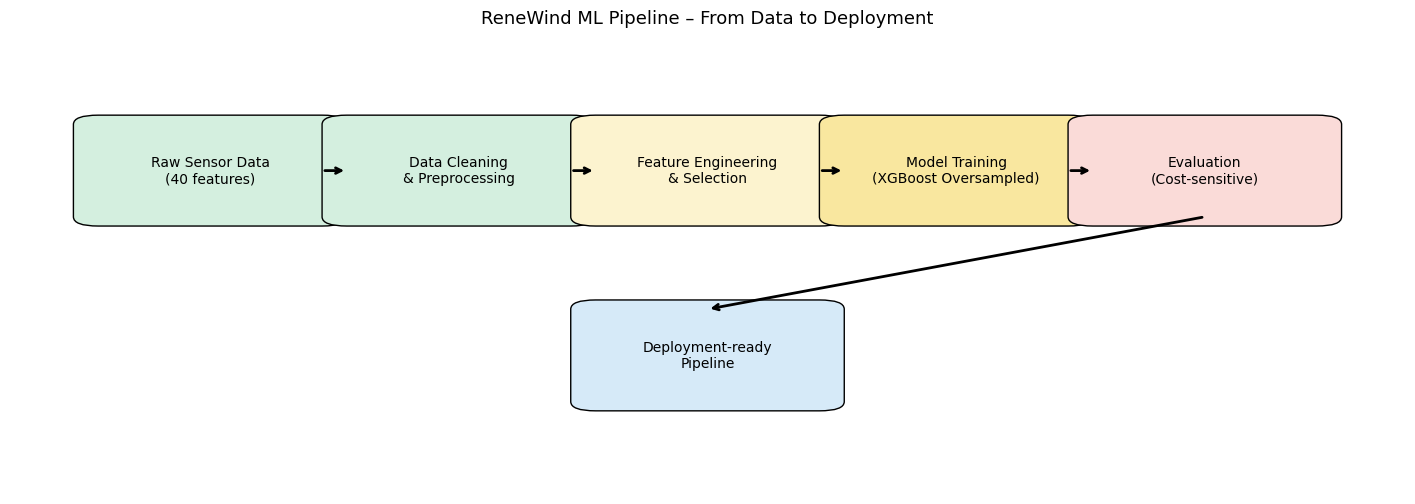

In [ ]:
import matplotlib.patches as patches

# Create the figure and axis
fig, ax = plt.subplots(figsize=(15, 6))
ax.axis('off')

# Define box positions, labels, and stage color
boxes = [
    {"label": "Raw Sensor Data\n(40 features)", "xy": (0.05, 0.6), "color": '#D4EFDF'},       # Data Prep
    {"label": "Data Cleaning\n& Preprocessing", "xy": (0.25, 0.6), "color": '#D4EFDF'},       # Data Prep
    {"label": "Feature Engineering\n& Selection", "xy": (0.45, 0.6), "color": '#FCF3CF'},     # Feature Engg
    {"label": "Model Training\n(XGBoost Oversampled)", "xy": (0.65, 0.6), "color": '#F9E79F'},# Modeling
    {"label": "Evaluation\n(Cost-sensitive)", "xy": (0.85, 0.6), "color": '#FADBD8'},         # Evaluation
    {"label": "Deployment-ready\nPipeline", "xy": (0.45, 0.2), "color": '#D6EAF8'}            # Deployment
]

# Draw boxes
for box in boxes:
    rect = patches.FancyBboxPatch(
        box["xy"], 0.18, 0.2,
        boxstyle="round,pad=0.02",
        edgecolor='black',
        facecolor=box["color"]
    )
    ax.add_patch(rect)
    ax.text(box["xy"][0]+0.09, box["xy"][1]+0.1, box["label"],
            ha='center', va='center', fontsize=10)

# Draw arrows
arrow_props = dict(arrowstyle="->", color='black', lw=2)

for i in range(4):
    ax.annotate("",
        xy=(boxes[i+1]["xy"][0], boxes[i+1]["xy"][1]+0.1),
        xytext=(boxes[i]["xy"][0]+0.18, boxes[i]["xy"][1]+0.1),
        arrowprops=arrow_props
    )

# Arrow from Evaluation to Deployment
ax.annotate("",
    xy=(boxes[5]["xy"][0]+0.09, boxes[5]["xy"][1]+0.2),
    xytext=(boxes[4]["xy"][0]+0.09, boxes[4]["xy"][1]),
    arrowprops=arrow_props
)

# Title
plt.title("ReneWind ML Pipeline – From Data to Deployment", fontsize=13)

# Adjust layout
plt.subplots_adjust(left=0.05, right=0.98)
plt.margins(x=0.05)

# Show diagram
plt.show()


# Business Insights and Conclusions

Based on the final model, XGBoost Oversampled, was optimized for recall, to focus on capturing as many true positive cases as possible, minimizing missed critical events.

* Reliable Predictive Maintenance: The model effectively identifies potential failures, ensuring reduced downtime and cost savings.
* High Precision Reduces Waste: False alarms are minimal, optimizing maintenance schedules and reducing unnecessary costs.
* Room for Slight Recall Improvement: Some failures (false negatives) are still missed, so adjusting sensitivity could improve predictions further.
* Enhanced Operational Efficiency: With better turbine performance predictions, ReneWind can improve energy generation and reliability.

Recommendations for ReneWind include:

* Fine-tune recall slightly to capture more true failures (reduce false negatives).
* Implement automated scheduling for maintenance teams based on model alerts.
* Use model insights for long-term turbine performance improvements.
* Integrate with energy grid forecasting for better power delivery planning.

By leveraging this ML model, ReneWind can maximize efficiency, reduce maintenance costs, and ensure continuous, reliable wind energy generation.




***

## <a name='link1'>Appendix: Detailed Exploratory Data Analysis (EDA)</a>

###Univariate Analysis

Capping extreme outliers helps Recall, it -
* reduces noise from Extreme Majority-Class Values. And neutralizes the influence of extreme values, allowing the model to better detect subtle failure patterns
* supports Class Boundary Clarity, allows the model to focus on relevant, interpretable boundaries, not dominated by rare extreme cases


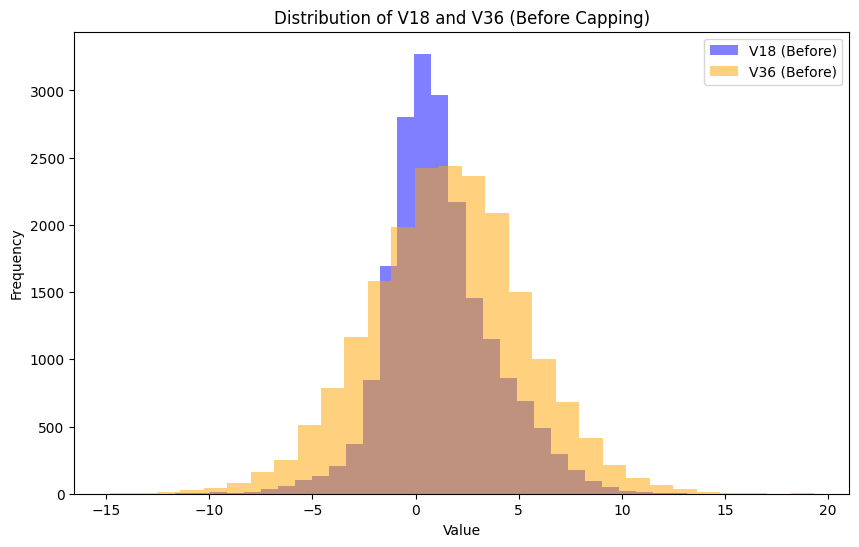

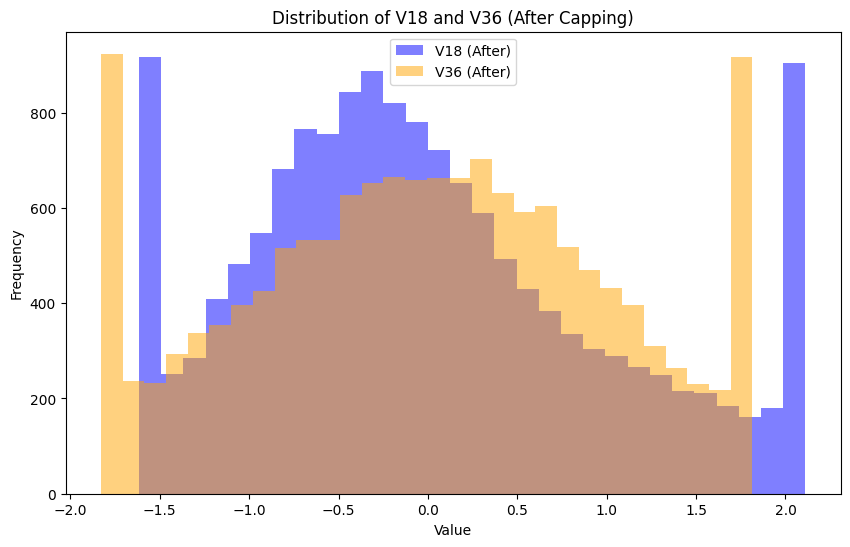

In [ ]:
# Outlier Capping Analysis for any random 2 features to show the observances

# Before capping
plt.figure(figsize=(10, 6))
plt.hist(df_train['V18'], bins=30, alpha=0.5, color='blue', label='V18 (Before)')
plt.hist(df_train['V36'], bins=30, alpha=0.5, color='orange', label='V36 (Before)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of V18 and V36 (Before Capping)')
plt.legend()
plt.show()

# After capping
plt.figure(figsize=(10, 6))
# Access the column by its index since X_train is a NumPy array
plt.hist(X_train[:, df_train.columns.get_loc('V18')], bins=30, alpha=0.5, color='blue', label='V18 (After)')
plt.hist(X_train[:, df_train.columns.get_loc('V36')], bins=30, alpha=0.5, color='orange', label='V36 (After)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of V18 and V36 (After Capping)')
plt.legend()
plt.show()

**Before Capping:**

* V18 and V36 show long tails (extreme values):

  * Values stretch far left/right, especially for majority class (likely "non-failure").
  * These outliers can dominate learning during training, causing the model to focus more on these rare but extreme values.

* Class imbalance effect worsens:

  * Since failures are rare, the minority class patterns get "washed out" by overwhelming majority class noise from extreme values.

**After Capping:**

* Distributions are tighter, bounded:
  * V18 and V36 are now capped between ±1.5 to ±2.
  * The majority class no longer overshadows with extreme spikes, making the failure (minority) signals more detectable.

* Clearer class boundaries:

  * Models like Gradient Boosting can now focus on realistic, consistent feature ranges.
  * It improves generalization — especially useful in capturing rare failure cases, boosting recall.

Capping outliers is not just a preprocessing step — it's a strategic enhancement that boosts recall by allowing the model to uncover subtle patterns associated with rare but costly events like failures in the ReneWind project.

###Bivariate Analysis

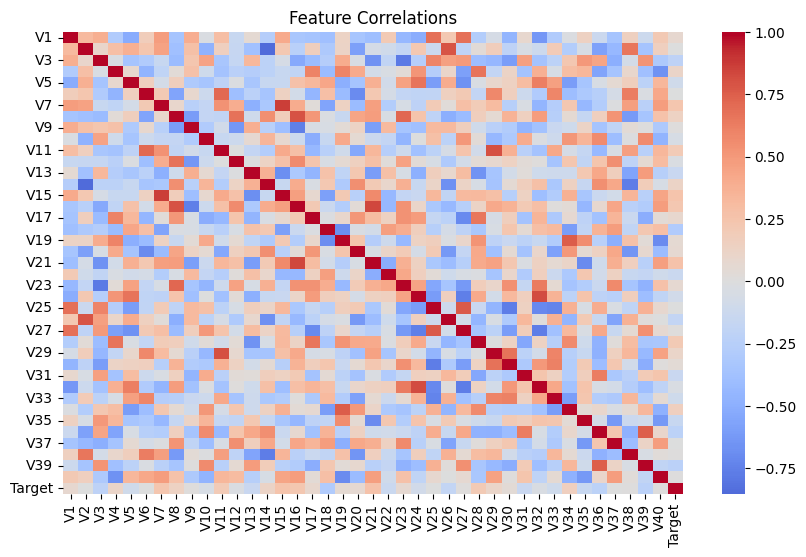

In [ ]:
# Define target variable
target = "Target"
features = df_train.columns[df_train.columns != target]

# Correlation with target variable
correlations = df_train.corr()[target].sort_values(ascending=False)

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_train.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlations")
plt.show()

Observations/Insights:

Diagonal Line of Dark Red:

  * Represents perfect self-correlation (1.0) of each feature with itself, which is expected.

Feature-Target Correlations:
  * The last row ("Target") shows how each feature correlates with the target variable.
  * Some features appear to have moderate positive or negative correlations, meaning they influence the target.

Feature Interdependencies:
* Several features show strong correlations with each other (highly red or blue values).
* This suggests potential multicollinearity, where some features provide redundant information.

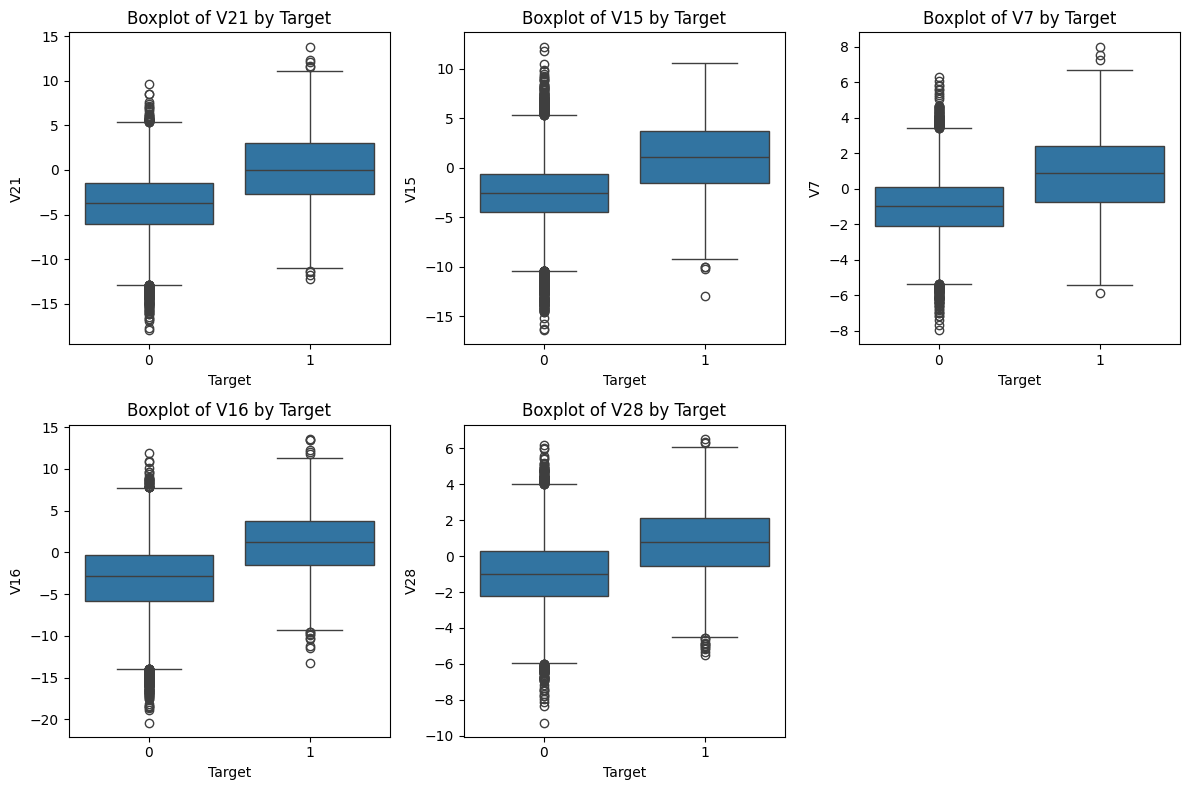

In [ ]:
# Boxplots for top correlated features with Target
top_features = correlations.index[1:6]  # Selecting top 5 correlated features

plt.figure(figsize=(12, 8))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_train[target], y=df_train[feature])
    plt.title(f"Boxplot of {feature} by Target")
plt.tight_layout()
plt.show()

Observations/Insight:

1. Feature Distributions Differ Between Classes:

* Across all features, the distribution for Target = 1 (positive class) is shifted upward compared to Target = 0 (negative class).
* This suggests these features contain predictive signals and could be important for classification.

2. Wider Spread in Positive Class:
* V21, V15, and V16 show a wider range of values in Target = 1 compared to Target = 0.
* This indicates that higher variability in these features is associated with positive outcomes.

3. Presence of Outliers
* Each feature has significant outliers, especially in Target = 0. This may indicate noise or extreme values in the dataset.
* Consider outlier handling (e.g., transformation, capping, or removing extreme values) to improve model stability.

4. Mean/Median Differences Indicate Predictive Power:

* The medians of V21, V15, V7, V16, and V28 for Target = 1 are consistently higher than those for Target = 0.
* This suggests that higher values of these features increase the likelihood of the positive class (Target = 1)
* These features can be strong indicators for prediction models, potentially distinguishing between operational success and failure in ReneWind's turbines.



In [ ]:
# Mean feature comparison for each class (Target = 0 vs 1)
mean_comparison = df_train.groupby(target).mean().T
mean_comparison.columns = ["Mean_0", "Mean_1"]

# Display
mean_comparison

,Mean_0,Mean_1
V1,-0.333182,0.768272
V2,0.441153,0.428143
V3,2.660379,-0.505019
V4,-0.175306,1.485127
V5,-0.002463,-0.926582
V6,-0.995560,-0.993451
V7,-0.980488,0.842285
V8,-0.656842,1.300756
V9,-0.021063,0.055604
V10,0.014255,-0.476792


Observations/Insights:

* Several features show large differences between Mean_0 and Mean_1. These features have strong predictive power, as their means change significantly between the two classes.
* V21, V15, and V36 could be key drivers in classification models
* Some features have very small differences between the two classes. These features may have little impact on model predictions and could be removed or deprioritized in feature selection.
* Some features have a negative mean for one class and positive for the other. These features likely have high discriminative power, helping the model separate the two classes efficiently.

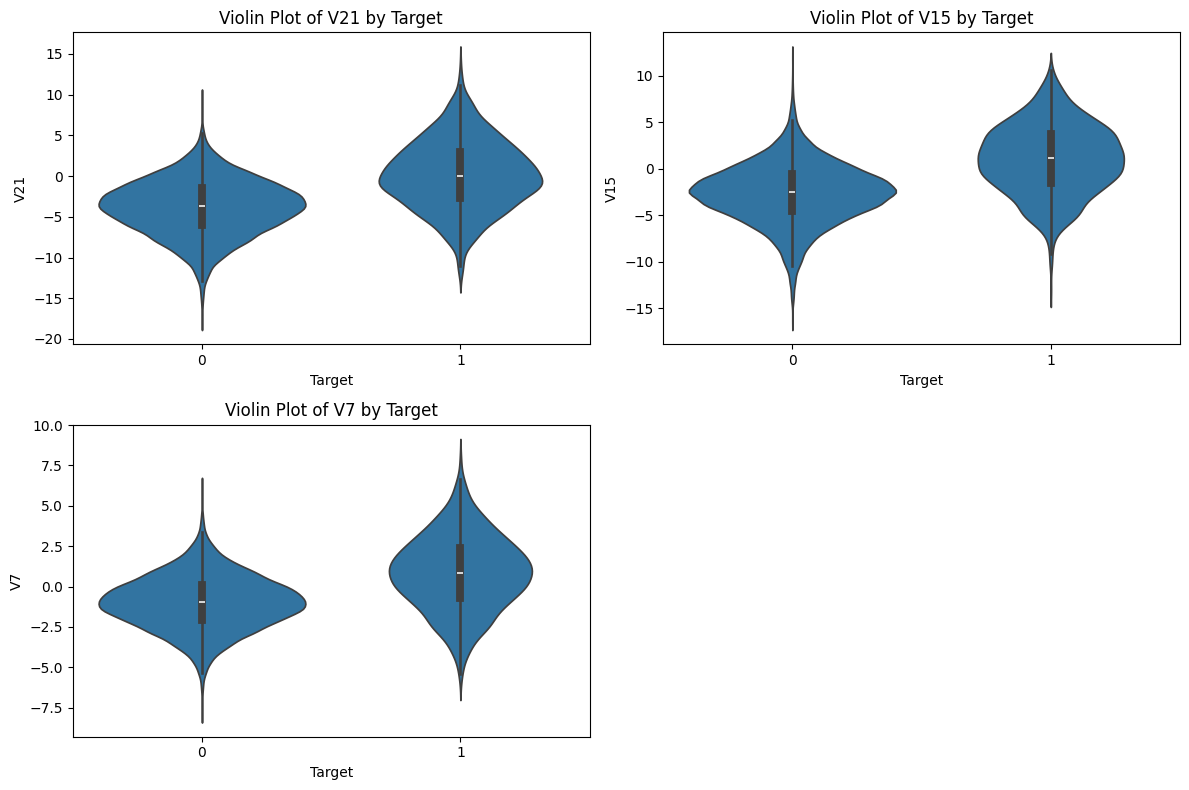

In [ ]:
# Violin Plots for Select Feature Distributions

plt.figure(figsize=(12, 8))
for i, feature in enumerate(["V21", "V15", "V7"], 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x=df_train["Target"], y=df_train[feature])
    plt.title(f"Violin Plot of {feature} by Target")
plt.tight_layout()
plt.show()


Observations/Insights:

Feature Distributions Differ Across Target Classes
* For all three features (V21, V15, V7), the distribution shifts noticeably between Target = 0 and Target = 1.
* V21 & V15: The median (white dot in the violin plot) for Target = 1 is higher compared to Target = 0.
* V7: The distribution for Target = 1 is shifted slightly higher, indicating greater variance.
  * These features have strong predictive potential, as their distributions change with the target class.
  * Higher values of V21, V15, and V7 seem associated with the positive class (Target = 1).

Wider Spread in Target = 1
* The spread (variability) of feature values is larger in Target = 1, especially for V15.
* This suggests that positive cases (failures) have more diverse characteristics.
  * Variability in wind turbine failures may indicate multiple contributing factors.

Overlapping Distributions
* While there are noticeable differences, there is some overlap between classes, particularly in V7.
* V21 and V15 show more clear separation, making them stronger predictors.
  * V7 might be a weaker predictor or require interaction with other features.
  * V21 and V15 are likely important in classification models.

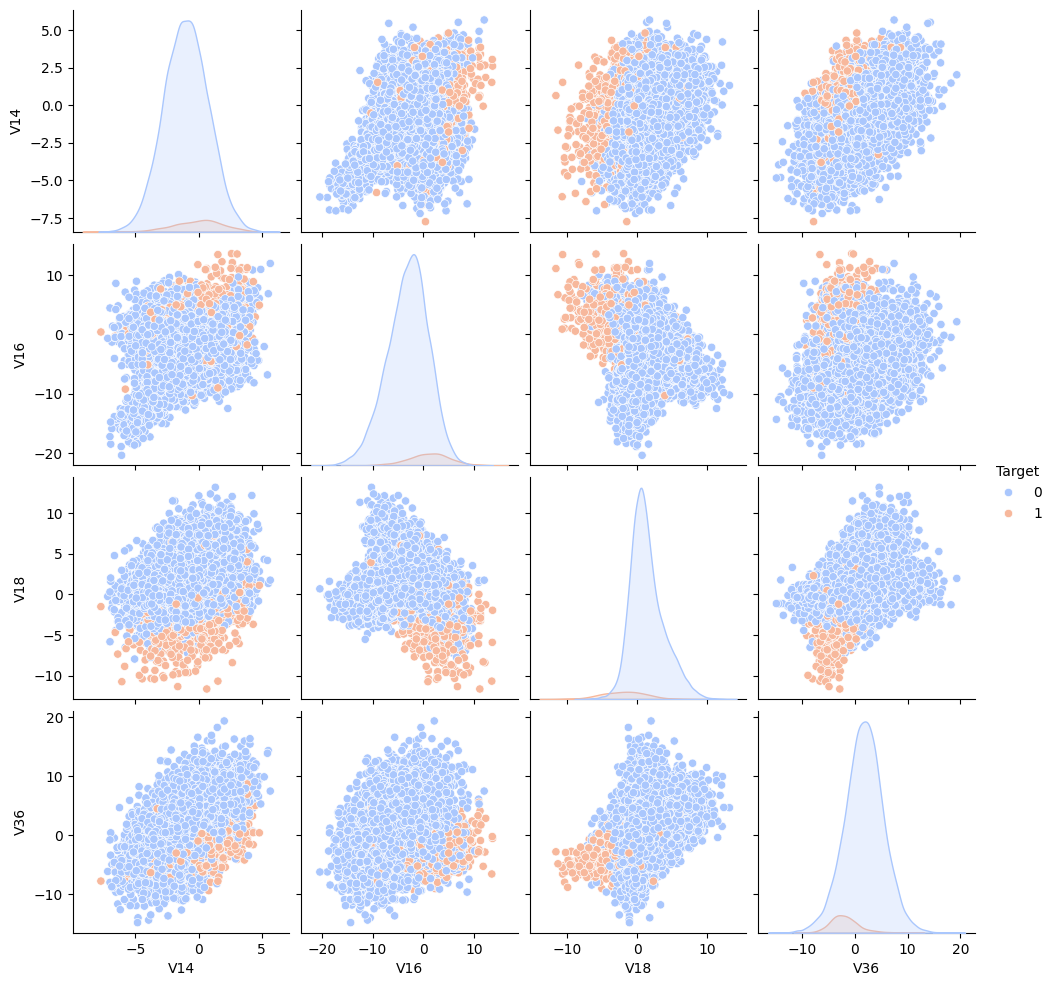

In [ ]:
# Pairplots for Feature Interactions Select key features for comparison
sns.pairplot(df_train, vars=["V14", "V16", "V18", "V36"], hue="Target", palette="coolwarm")
plt.show()



Pairplot Analysis & Interpretation:

Feature Distributions (Diagonal Plots)
* The diagonal plots show the distribution (KDE plots) of each feature.
* V14, V16, and V36 appear normally distributed, while V18 has a wider spread.
* Class 0 (blue) dominates the density, while Class 1 (orange) is relatively low in proportion.
  * The distribution shapes indicate some level of feature scaling and normalization.
  * V18 has a broader spread, suggesting it may capture extreme values or outliers.

Feature-Target Separation:
* V14 vs. V16, V18, V36:
  * Class 1 (orange) is concentrated in the lower values of V14, indicating lower values might correlate with positive cases.
* V16 vs. V18, V36:
  * Class 1 is clustered towards negative values, suggesting a potential predictive relationship.
* V18 vs. V36:
  * Class 1 values appear spread in specific regions, hinting at an interaction effect.

* Class separation is visible but not perfect, meaning these features contribute partially to the classification.
* Features V14 and V16 show stronger class differences, making them potentially important predictors.

Linear & Nonlinear Relationships:

* Some feature pairs (e.g., V16-V18, V14-V36) exhibit linear relationships.
* Others (e.g., V18-V36) show nonlinear, scattered patterns.
  * Linear relationships can be well captured by models like logistic regression, XGBoost.
  * Nonlinear patterns suggest that tree-based models (e.g., Random Forest, XGBoost) may perform better than linear classifiers.

### Best Decision Threshold for Final model (XGB Oversampled)
* As an added measure, recall can be further improved before analysing test performance using optimized threshold

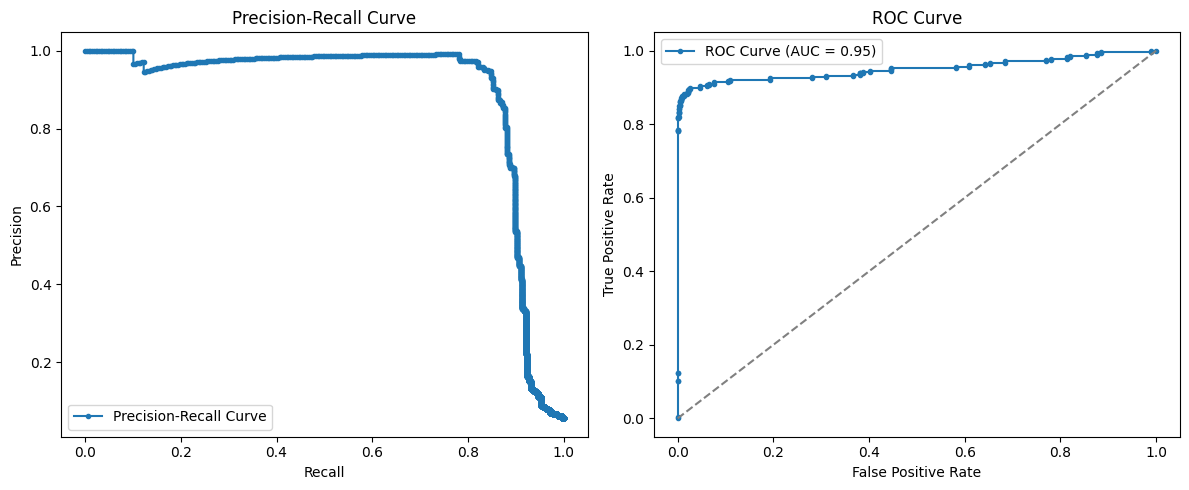

0.5130545

In [ ]:
# Analyze Precision-Recall and ROC-AUC curves to find the best cut-off.

# Get predicted probabilities for the positive class
y_scores_v2 = best_xgb_os_tuned_model_v2.predict_proba(X_val)[:, 1]

# Compute Precision-Recall curve
precision_v2, recall_v2, thresholds_pr_v2 = precision_recall_curve(y_val, y_scores_v2)

# Compute ROC curve and AUC
fpr_v2, tpr_v2, thresholds_roc_v2 = roc_curve(y_val, y_scores_v2)
roc_auc_v2 = auc(fpr_v2, tpr_v2)

# Plot Precision-Recall curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall_v2, precision_v2, marker='.', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

# Plot ROC curve
plt.subplot(1, 2, 2)
plt.plot(fpr_v2, tpr_v2, marker='.', label=f'ROC Curve (AUC = {roc_auc_v2:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

# Find the best threshold based on maximizing recall while keeping precision acceptable
best_threshold_idx_v2 = np.argmax(recall_v2 - (1 - precision_v2))  # Custom function to balance both
best_threshold_v2 = thresholds_pr_v2[best_threshold_idx_v2]

best_threshold_v2



Observations/Insights:

**Precision-Recall (PR) Curve:**

The PR curve shows high precision maintained across a wide recall range, meaning the model is effective at:

  * Capturing actual failures (high recall)

  * While avoiding many false positives (high precision)

The steep drop near recall ≈ 0.95–1.0 implies diminishing returns if recall is pushed too far — precision degrades rapidly.

The model performs strongly in the mid-high recall range (0.8–0.9) — a sweet spot for ReneWind.

**ROC Curve:**

* The ROC AUC = 0.95 — excellent performance

  * Close to the ideal point.

  * Very strong true positive rate (TPR) at low false positive rates (FPR).

The classifier effectively distinguishes failures vs. non-failures, making it suitable for production.

* **Threshold Optimized	0.5130 — can be applied as needed to support decision-making with better balance**



### To jump back to the EDA summary section, click <a href = #link2>here</a>.

### Project Conclusion

In [ ]:
# Create dataframe to check original & copy datasets shape
shape_comparison = pd.DataFrame({
    "Dataset": ["Train (Original)", "Test (Original)", "Train (Copy)", "Test (Copy)"],
    "Rows": [train.shape[0], test.shape[0], df_train.shape[0], df_test.shape[0]],
    "Columns": [train.shape[1], test.shape[1], df_train.shape[1], df_test.shape[1]]
})

# Display the DataFrame
shape_comparison

,Dataset,Rows,Columns
0,Train (Original),20000,41
1,Test (Original),5000,41
2,Train (Copy),20000,41
3,Test (Copy),5000,41


Observations:
* Original dataset integrity intact
* Copy dataset rows remain same

##        <p align="center"><b>** ReneWindProject analysis completed.**</b></p>